# **Scrapping and Data cleaning**

In [ ]:
from google.colab import drive

try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")
    print("Please ensure you're running this in a Google Colab environment and authorize access.")
import os
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
os.makedirs(project_path, exist_ok=True)
print(f"Project directory created at: {project_path}")

Mounted at /content/drive
Google Drive mounted successfully!
Project directory created at: /content/drive/MyDrive/RedditBrandAnalysis


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install praw pandas
import praw
import prawcore
import pandas as pd
import datetime as dt
import time
from google.colab import userdata
try:
    # Load your securely stored credentials from Colab Secrets
    client_id = userdata.get('REDDIT_CLIENT_ID')
    client_secret = userdata.get('REDDIT_CLIENT_SECRET')
    user_agent = userdata.get('REDDIT_USER_AGENT')

    # Initialize the Reddit instance
    reddit = praw.Reddit(
        client_id=client_id,
        client_secret=client_secret,
        user_agent=user_agent
    )
    test_subreddit = reddit.subreddit("python").display_name



    print(f"✅ REAL SUCCESS! Your script is authenticated for read-only access.")
    print(f"(Successfully fetched subreddit name: r/{test_subreddit})")


except prawcore.exceptions.ResponseException as e:
    # This block runs ONLY if Reddit sends back an error (like 401 Unauthorized)

    print(f"❌ AUTHENTICATION FAILED. Reddit rejected the API keys.")
    print(f"Error Details: {e}")
    print("\nPlease double-check the Client ID and Secret values and try again.")


except Exception as e:
    # This block catches any other potential errors during setup
    print(f"\nAn unexpected error occurred: {e}")

In [ ]:
import praw
import pandas as pd
import datetime as dt
import json
import time
import os

project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_raw_output_path = os.path.join(project_path, 'reddit_posts_raw.jsonl')

SUBREDDITS = ["Android", "Apple", "GalaxyS23", "GalaxyS24", "iPhone", "Smartphones", "samsung"]

SAMSUNG_S_KEYWORDS = ["galaxy s22", "galaxy s23", "galaxy s24", "s22 ultra", "s23 ultra", "s24 ultra", "s22+", "s23+", "s24+", "s22 plus", "s23 plus", "s24 plus"]
IPHONE_KEYWORDS = ["iphone 14", "iphone 15", "iphone 14 pro", "iphone 15 pro", "iphone 14 pro max", "iphone 15 pro max", "iphone 14 mini"]
ALL_MODEL_KEYWORDS = SAMSUNG_S_KEYWORDS + IPHONE_KEYWORDS


def extract_initial_posts(reddit_instance, subreddits, limit_per_subreddit=2000):
    all_posts_data = []
    seen_post_ids = set() # To prevent duplicates if a post appears in multiple subreddit searches

    if reddit_instance is None:
        print("Reddit instance is not initialized. Cannot extract posts.")
        return []

    print("Starting initial post extraction...")
    for sub_name in subreddits:
        print(f"Searching subreddit: r/{sub_name}")
        subreddit = reddit_instance.subreddit(sub_name)

        # Using .new() to get recent posts, regardless of score.
        # This is a good general approach for collecting fresh data.
        posts_from_subreddit = []
        try:
            for submission in subreddit.new(limit=limit_per_subreddit):
                if submission.id in seen_post_ids:
                    continue


                # Ensure we only process actual submission objects with necessary attributes.
                if not hasattr(submission, 'title') or not hasattr(submission, 'selftext'):
                    continue

                post_info = {
                    'id': submission.id,
                    'title': submission.title,
                    'selftext': submission.selftext if submission.selftext else '', # Ensure it's a string, not None
                    'url': submission.url,
                    'created_utc': submission.created_utc,
                    'subreddit': submission.subreddit.display_name,
                    'num_comments': submission.num_comments,
                    'score': submission.score,
                    'author': submission.author.name if submission.author else '[deleted]',
                    'retrieved_at_utc': dt.datetime.utcnow().timestamp()
                }
                posts_from_subreddit.append(post_info)
                seen_post_ids.add(submission.id)

            print(f"  Collected {len(posts_from_subreddit)} posts from r/{sub_name}.")
            all_posts_data.extend(posts_from_subreddit)
            time.sleep(1) # Small delay between subreddits to respect API rate limits

        except prawcore.exceptions.NotFound:
            print(f"  Subreddit r/{sub_name} not found or is private. Skipping.")
        except Exception as e:
            print(f"  Error extracting from r/{sub_name}: {e}. Skipping to next subreddit.")


    print(f"\nTotal initial unique posts collected: {len(all_posts_data)}")
    return all_posts_data

# --- Main Execution for Initial Post Extraction ---
# Check if the 'reddit' object from the previous authentication block is valid
if 'reddit' not in locals() or reddit is None:
    print("Error: Reddit object is not authenticated. Please run the authentication block first.")
else:
    raw_posts = extract_initial_posts(reddit, SUBREDDITS, limit_per_subreddit=5000) # Increased limit for broader initial capture

    # Save raw posts to JSON Lines file
    with open(posts_raw_output_path, 'w', encoding='utf-8') as f:
        for post in raw_posts:
            f.write(json.dumps(post) + '\n')
    print(f"\nSaved {len(raw_posts)} raw posts to {posts_raw_output_path}")

    print("\nInitial post extraction completed. Proceed to the next block for cleaning posts.")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Raw posts will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_raw.jsonl
Starting initial post extraction...
Searching subreddit: r/Android


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

  Collected 830 posts from r/Android.


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



...

  Collected 949 posts from r/Smartphones.


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Searching subreddit: r/samsung


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

  Collected 933 posts from r/samsung.

Total initial unique posts collected: 6616

Saved 6616 raw posts to /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_raw.jsonl

Initial post extraction completed. Proceed to the next block for cleaning posts.


In [ ]:
import pandas as pd
import json
import os
import datetime as dt
import re # For regular expressions
from langdetect import detect, DetectorFactory # For language detection
import numpy as np

# Set seed for langdetect for consistent results
DetectorFactory.seed = 0

# Define paths (assuming project_path is defined from previous blocks)
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_raw_output_path = os.path.join(project_path, 'reddit_posts_raw.jsonl')
posts_cleaned_output_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')

print(f"Loading raw posts from: {posts_raw_output_path}")
print(f"Cleaned posts will be saved to: {posts_cleaned_output_path}")

try:
    # Read the JSON Lines file into a list of dictionaries
    raw_posts_list = []
    with open(posts_raw_output_path, 'r', encoding='utf-8') as f:
        for line in f:
            raw_posts_list.append(json.loads(line))
    print(f"Loaded {len(raw_posts_list)} raw posts.")

    if not raw_posts_list:
        raise ValueError("No posts loaded. Please check the raw posts file.")

    posts_df = pd.DataFrame(raw_posts_list)
    print("Raw posts DataFrame created.")
    print(f"Initial DataFrame shape: {posts_df.shape}")
    print("Columns:", posts_df.columns.tolist())

except FileNotFoundError:
    print(f"Error: Raw posts file not found at {posts_raw_output_path}. Please run the previous extraction block first.")
    # Exit or handle gracefully
    posts_df = pd.DataFrame()
except Exception as e:
    print(f"An error occurred loading raw posts: {e}")
    posts_df = pd.DataFrame()


if not posts_df.empty:

    # UPDATED KEYWORDS FOR FILTERING RELEVANT CONTENT
    SAMSUNG_S_KEYWORDS = ["galaxy s22", "galaxy s23", "galaxy s24", "s22 ultra", "s23 ultra", "s24 ultra", "s22+", "s23+", "s24+", "s22 plus", "s23 plus", "s24 plus",
    'samsung s22',
    'galaxy s22',
    's22',
    'samsung s22 plus',
    's22 plus',
    's22+',
    'samsung s22 ultra',
    's22 ultra',
    's22u',
    'galaxy s22 ultra',
    'samsung s23',
    'galaxy s23',
    's23',
    's23 base',
    'samsung s23 plus',
    's23 plus',
    's23+',
    's23plus',
    'samsung s23 ultra',
    's23 ultra',
    's23u',
    's23ultra',
    'galaxy s23 ultra',
    'samsung s24',
    'galaxy s24',
    's24',
    'samsung s24 exynos',
    'samsung s24 snapdragon',
    'samsung s24 plus',
    's24 plus',
    's24 +',
    's24+',
    'samsung s24 ultra',
    's24 ultra',
    's24 u',
    's24u',
    's24ultra',
    'sm-s926u',
    'galaxy s24 ultra',
    'samsung s24 pro',
    'iphone',
    'iphone pro',
    'iphone pro max',
    'samsung',
    'samsung galaxy',
    'samsung s',
    'samsung s series',
    'galaxy s',
    'samsung s plus',
    'plus',
    'samsung s ultra',
    's ultra',
    'ultra',
    'Samsung S22',
    'Samsung S22 Ultra',
    'Samsung S23',
    'Samsung S23 Ultra',
    'Samsung S24',
    'Samsung S24 Ultra'
]
    IPHONE_KEYWORDS = ["iphone 14", "iphone 15", "iphone 14 pro", "iphone 15 pro", "iphone 14 pro max", "iphone 15 pro max", "iphone 14 mini",
    'iphone 14',
    'iphone 14 plus',
    'iphone 14 pro',
    'iphone 14 pro max',
    '14 pro',
    '14 pro max',
    '14pm',
    'iphone 14pm',
    'iphone 14pro',
    'iphone 15',
    'iphone 15 plus',
    'iphone 15 pro',
    'iphone 15 pro max',
    '15 pro',
    '15 ultra',
    '15pm',
    'iphone',
    'iphone pro',
    'iphone pro max',
    'iPhone 14',
    'iPhone 14 Pro',
    'iPhone 14 Pro Max',
    'iPhone 15',
    'iPhone 15 Pro',
    'iPhone 15 Pro Max',
]
    ALL_MODEL_KEYWORDS = SAMSUNG_S_KEYWORDS + IPHONE_KEYWORDS

    # Date filtering (posts newer than this timestamp)
    start_date_timestamp = int(dt.datetime(2023, 6, 1, 0, 0, 0).timestamp())



    def clean_text_for_filtering(text):
        """
        Performs preliminary cleaning for keyword matching.
        Keeps common punctuation for context but removes URLs, Reddit-specifics, and excessive spaces.
        """
        if not isinstance(text, str):
            return ""
        text = text.lower()
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove Reddit-specific noise (e.g., r/subreddit, u/username)
        text = re.sub(r'(r/|u/)\S+', '', text)
        # Replace common non-alphanumeric separators with spaces, but keep letters and numbers for product names
        text = re.sub(r'[^a-z0-9\s\+\-]', ' ', text) # Allow +, - for model names like S22+
        # Reduce multiple spaces to a single space
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def contains_relevant_keyword(text, keywords):
        """Checks if the text contains any of the relevant model keywords."""
        cleaned_text = clean_text_for_filtering(text) # Use cleaned text for keyword check
        for k in keywords:
            if k.lower() in cleaned_text:
                return True
        return False

    def is_bot_or_deleted_post(row):
        """Identifies posts likely to be bots or completely deleted/removed."""
        author = row['author']
        title = row['title'].strip().lower()
        selftext = row['selftext'].strip().lower()

        # Common bot user names (can expand this list)
        common_bots = ['[deleted]', 'automoderator', 'remindmebot', 'goodbot_badbot', 'image_to_text_bot']
        if author in common_bots:
            return True

        # If title and selftext are common placeholders for deleted content
        if (title == '[deleted]' and selftext == '[deleted]') or \
           (title == '[removed]' and selftext == '[removed]') or \
           (not title and not selftext and author == '[deleted]'): # Completely empty post by deleted user
            return True
        return False

    def detect_english(text):
        """Detects if the text is predominantly English."""
        if not isinstance(text, str) or len(text.strip()) < 5: # Small texts can cause langdetect errors or incorrect detections
            return False
        try:
            lang = detect(text.strip())
            return lang == 'en'
        except Exception:

            return False

    #Apply Cleansing and Filtering ---
    print("\nApplying extensive cleaning and filtering steps...")

    #Drop duplicates based on 'id'
    initial_rows = len(posts_df)
    posts_df.drop_duplicates(subset=['id'], inplace=True)
    print(f"Dropped {initial_rows - len(posts_df)} duplicate posts (based on ID). New shape: {posts_df.shape}")

    #Filter by creation date (only posts from start_date_timestamp onwards)
    posts_df = posts_df[posts_df['created_utc'] >= start_date_timestamp]
    print(f"Filtered by date (after {dt.datetime.fromtimestamp(start_date_timestamp).strftime('%Y-%m-%d')}). New shape: {posts_df.shape}")

    #Remove posts identified as likely bot/deleted
    posts_df = posts_df[~posts_df.apply(is_bot_or_deleted_post, axis=1)]
    print(f"Filtered out likely bot/deleted posts. New shape: {posts_df.shape}")

    # Apply combined keyword filtering
    # Create a combined text field for robust keyword check *before* further cleaning that might remove them
    posts_df['combined_text_for_filter'] = posts_df['title'] + " " + posts_df['selftext'].fillna('')
    posts_df = posts_df[posts_df['combined_text_for_filter'].apply(lambda x: contains_relevant_keyword(x, ALL_MODEL_KEYWORDS))]
    print(f"Filtered by relevant keywords in title/selftext. New shape: {posts_df.shape}")
    posts_df.drop(columns=['combined_text_for_filter'], inplace=True, errors='ignore') # Drop helper column


    # Filter out very short or empty posts (if selftext is short AND title is short)
    # Define thresholds for meaningful content
    MIN_TITLE_LEN = 10
    MIN_SELFTEXT_LEN = 20

    posts_df['title_processed'] = posts_df['title'].apply(lambda x: clean_text_for_filtering(x))
    posts_df['selftext_processed'] = posts_df['selftext'].apply(lambda x: clean_text_for_filtering(x))

    posts_df = posts_df[(posts_df['title_processed'].str.len() > MIN_TITLE_LEN) | \
                        (posts_df['selftext_processed'].str.len() > MIN_SELFTEXT_LEN)]
    print(f"Filtered by minimum meaningful content length. New shape: {posts_df.shape}")

    #Language Detection
    posts_df['combined_text_for_lang_detect'] = posts_df['title_processed'] + " " + posts_df['selftext_processed']
    posts_df['is_english'] = posts_df['combined_text_for_lang_detect'].apply(detect_english)
    posts_df = posts_df[posts_df['is_english'] == True]
    print(f"Filtered by English language detection. New shape: {posts_df.shape}")


    #Final Text Cleaning
    print("Applying final text cleaning to 'title' and 'selftext' columns...")
    # This version cleans more thoroughly for eventual NLP
    def deep_clean_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
        text = re.sub(r'(r/|u/)\S+', '', text) # Reddit users/subs
        text = re.sub(r'[^a-zA-Z\s]', '', text) # ONLY letters and spaces
        text = re.sub(r'\s+', ' ', text).strip() # Multiple spaces
        return text

    posts_df['title'] = posts_df['title'].apply(deep_clean_text)
    posts_df['selftext'] = posts_df['selftext'].apply(deep_clean_text)

    # Remove posts that became empty after deep cleaning
    posts_df = posts_df[(posts_df['title'].str.len() > 0) | (posts_df['selftext'].str.len() > 0)]
    print(f"Removed posts that became empty after deep cleaning. Final shape: {posts_df.shape}")


    # Step 5: Remove helper columns
    posts_df.drop(columns=['title_processed', 'selftext_processed', 'combined_text_for_lang_detect', 'is_english'], inplace=True, errors='ignore')

    print(f"\nExtensive post cleaning completed. Final number of posts: {len(posts_df)}")

    # --- 6. Save Cleaned Posts ---
    cleaned_posts_list = posts_df.to_dict(orient='records')
    with open(posts_cleaned_output_path, 'w', encoding='utf-8') as f:
        for post in cleaned_posts_list:
            f.write(json.dumps(post) + '\n')
    print(f"Saved {len(cleaned_posts_list)} cleaned posts to {posts_cleaned_output_path}")

    print("\nPhase 2: Post Cleansing Completed. Proceed to the next block for comment extraction.")

else:
    print("No posts to clean. Skipping post cleansing.")

Loading raw posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_raw.jsonl
Cleaned posts will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl
Loaded 6616 raw posts.
Raw posts DataFrame created.
Initial DataFrame shape: (6616, 10)
Columns: ['id', 'title', 'selftext', 'url', 'created_utc', 'subreddit', 'num_comments', 'score', 'author', 'retrieved_at_utc']

Applying extensive cleaning and filtering steps...
Dropped 0 duplicate posts (based on ID). New shape: (6616, 10)
Filtered by date (after 2023-06-01). New shape: (6616, 10)
Filtered out likely bot/deleted posts. New shape: (6547, 10)


/tmp/ipython-input-11-1888540959.py:216: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts_df['combined_text_for_filter'] = posts_df['title'] + " " + posts_df['selftext'].fillna('')


Filtered by relevant keywords in title/selftext. New shape: (3489, 11)


/tmp/ipython-input-11-1888540959.py:219: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts_df.drop(columns=['combined_text_for_filter'], inplace=True, errors='ignore') # Drop helper column
/tmp/ipython-input-11-1888540959.py:227: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts_df['title_processed'] = posts_df['title'].apply(lambda x: clean_text_for_filtering(x))


Filtered by minimum meaningful content length. New shape: (3487, 12)


/tmp/ipython-input-11-1888540959.py:235: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts_df['combined_text_for_lang_detect'] = posts_df['title_processed'] + " " + posts_df['selftext_processed']


Filtered by English language detection. New shape: (3415, 14)
Applying final text cleaning to 'title' and 'selftext' columns...


/tmp/ipython-input-11-1888540959.py:254: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts_df['title'] = posts_df['title'].apply(deep_clean_text)


Removed posts that became empty after deep cleaning. Final shape: (3415, 14)

Extensive post cleaning completed. Final number of posts: 3415
Saved 3415 cleaned posts to /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl

Phase 2: Post Cleansing Completed. Proceed to the next block for comment extraction.


In [ ]:
import datetime as dt
import time
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_cleaned_output_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')
comments_output_path = os.path.join(project_path, 'reddit_comments.jsonl')

print(f"Loading cleaned posts from: {posts_cleaned_output_path}")
print(f"Comments will be saved to: {comments_output_path}")

#Load Cleaned Posts
cleaned_posts_list = []
try:
    with open(posts_cleaned_output_path, 'r', encoding='utf-8') as f:
        for line in f:
            cleaned_posts_list.append(json.loads(line))
    print(f"Loaded {len(cleaned_posts_list)} cleaned posts for comment extraction.")

    if not cleaned_posts_list:
        raise ValueError("No cleaned posts loaded. Please ensure the post cleaning block ran successfully.")

except FileNotFoundError:
    print(f"Error: Cleaned posts file not found at {posts_cleaned_output_path}. Please run the post cleansing block first.")
    # Exit or handle gracefully
    cleaned_posts_list = []
except Exception as e:
    print(f"An error occurred loading cleaned posts: {e}")
    cleaned_posts_list = []


#Function to Extract Comments from a specific Submission
def extract_comments_from_submission(submission_obj, processed_comment_ids_set):
    comments_data = []
    try:
        submission_obj.comments.replace_more(limit=None)
    except Exception as e:
        print(f"  Warning: Could not replace 'MoreComments' for submission {submission_obj.id}: {e}")
        # Sometimes due to removed content or API quirks, this can fail. Proceed with what's available.
        pass

    # Get all comments as a flat list after expansion
    all_comments_for_submission = submission_obj.comments.list()

    for comment in all_comments_for_submission:
        # PRAW might return malformed comment objects or "MoreComments" even after replace_more.
        # Ensure we only process actual comment objects with necessary attributes.
        if not hasattr(comment, 'body') or comment.body is None:
            continue

        # Prevent adding duplicates if a comment could somehow appear multiple times
        if comment.id in processed_comment_ids_set:
            continue

        comment_info = {
            'id': comment.id,
            'body': comment.body,
            'parent_id': comment.parent_id,
            'link_id': comment.link_id, # The full_id of the post
            'created_utc': comment.created_utc,
            'author': comment.author.name if comment.author else '[deleted]',
            'score': comment.score,
            'is_submitter': comment.is_submitter,
            'distinguished': comment.distinguished,
            'post_id': submission_obj.id, # Direct link to its parent post ID
            'subreddit': submission_obj.subreddit.display_name, # Add subreddit for comments
            'retrieved_at_utc': dt.datetime.utcnow().timestamp(),
            'depth': comment.depth
        }
        comments_data.append(comment_info)
        processed_comment_ids_set.add(comment.id)
    return comments_data


# --- Main Execution Flow for Comment Extraction ---
if not cleaned_posts_list or 'reddit' not in locals() or reddit is None:
    print("Error: No cleaned posts to process or Reddit object is not authenticated.")
else:
    print("--- Starting Phase 1: Comment Extraction for Cleaned Posts ---")
    all_extracted_comments = []
    processed_comment_ids_global = set()

    for i, post_info in enumerate(cleaned_posts_list):
        try:
            submission_id = post_info['id']
            # Fetch the submission directly using its ID to ensure PRAW has the full object
            # This is crucial for replace_more() to work properly on the comments.
            submission = reddit.submission(id=submission_id)
            comments_for_this_post = extract_comments_from_submission(submission, processed_comment_ids_global)
            all_extracted_comments.extend(comments_for_this_post)

            # Provide progress update
            if (i + 1) % 50 == 0 or (i + 1) == len(cleaned_posts_list):
                print(f"-> Progress: Processed {i+1}/{len(cleaned_posts_list)} posts. Total unique comments extracted: {len(all_extracted_comments)}")

            time.sleep(0.5) # Small delay between processing each post's comments to respect rate limits

        except prawcore.exceptions.NotFound:
            print(f"   Warning: Post {post_info['id']} not found on Reddit (might have been deleted/removed after initial scrape). Skipping comments.")
            continue
        except Exception as e:
            print(f"   Error extracting comments for post {post_info['id']}: {e}. Skipping to next post.")
            continue # Continue to the next post even if one fails


    # Save all extracted comments
    print("\nSaving all extracted comments...")
    with open(comments_output_path, 'w', encoding='utf-8') as f:
        for comment in all_extracted_comments:
            f.write(json.dumps(comment) + '\n')
    print(f"Saved {len(all_extracted_comments)} comments to {comments_output_path}")

    print("\n--- Phase 1: Comment Extraction Completed. ---")
    print(f"Total unique comments extracted: {len(all_extracted_comments)}")

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Loading cleaned posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl
Comments will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments.jsonl
Loaded 3415 cleaned posts for comment extraction.
--- Starting Phase 1: Comment Extraction for Cleaned Posts ---


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

-> Progress: Processed 50/3415 posts. Total unique comments extracted: 2145


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

...

-> Progress: Processed 3350/3415 posts. Total unique comments extracted: 74846


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

-> Progress: Processed 3400/3415 posts. Total unique comments extracted: 75198


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

-> Progress: Processed 3415/3415 posts. Total unique comments extracted: 75473

Saving all extracted comments...
Saved 75473 comments to /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments.jsonl

--- Phase 1: Comment Extraction Completed. ---
Total unique comments extracted: 75473


In [ ]:
#Phase 2 - Extensive Cleaning of Comments

# Ensure necessary libraries are imported
import re # For regular expressions
from langdetect import detect, DetectorFactory # For language detection
import numpy as np # For numerical operations, especially with NaN

# Set seed for langdetect for consistent results
DetectorFactory.seed = 0

# Define paths (assuming project_path is defined from previous blocks)
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_raw_output_path = os.path.join(project_path, 'reddit_comments.jsonl') # This is the input for comments
comments_cleaned_output_path = os.path.join(project_path, 'reddit_comments_cleaned.jsonl')

print(f"Loading raw comments from: {comments_raw_output_path}")
print(f"Cleaned comments will be saved to: {comments_cleaned_output_path}")

# --- 1. Load Raw Comments ---
try:
    raw_comments_list = []
    with open(comments_raw_output_path, 'r', encoding='utf-8') as f:
        for line in f:
            raw_comments_list.append(json.loads(line))
    print(f"Loaded {len(raw_comments_list)} raw comments.")

    if not raw_comments_list:
        raise ValueError("No comments loaded. Please check the raw comments file.")

    comments_df = pd.DataFrame(raw_comments_list)
    print("Raw comments DataFrame created.")
    print(f"Initial DataFrame shape: {comments_df.shape}")
    print("Columns:", comments_df.columns.tolist())

except FileNotFoundError:
    print(f"Error: Raw comments file not found at {comments_raw_output_path}. Please run the comment extraction block first.")
    comments_df = pd.DataFrame() # Create an empty DataFrame to prevent errors
except Exception as e:
    print(f"An error occurred loading raw comments: {e}")
    comments_df = pd.DataFrame()


if not comments_df.empty:
    # --- 2. Define Cleansing Helper Functions for Comments ---


    def deep_clean_text(text):
        """
        Performs aggressive cleaning: lowercases, removes URLs, Reddit-specifics,
        and all non-alphabetic characters, then reduces spaces.
        """
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
        text = re.sub(r'(r/|u/)\S+', '', text) # Reddit users/subs
        text = re.sub(r'[^a-zA-Z\s]', '', text) # ONLY letters and spaces
        text = re.sub(r'\s+', ' ', text).strip() # Multiple spaces
        return text

    def detect_english(text):
        """Detects if the text is predominantly English."""
        if not isinstance(text, str) or len(text.strip()) < 5: # Small texts can cause langdetect errors or incorrect detections
            return False # Too short to reliably detect language
        try:
            lang = detect(text.strip())
            return lang == 'en'
        except Exception:
            # Handle cases where language detection fails (e.g., very short or highly noisy text)
            return False

    def is_deleted_or_bot_comment(row):
        """Identifies comments to be removed based on content or known bot authors."""
        comment_body = row['body'].strip().lower()
        comment_author = row['author'].strip().lower()

        # Rule 1: Comment body is explicitly deleted or removed
        if comment_body in ['[deleted]', '[removed]']:
            return True


        common_bots = ['automoderator', 'remindmebot', 'goodbot_badbot', 'image_to_text_bot', 'translate_bot'] # Add more if you observe them
        if comment_author in common_bots:
            return True
        return False

    # Apply Cleansing and Filtering to Comments
    print("\nApplying extensive comment cleansing and filtering steps...")

    # Drop duplicates based on 'id'
    initial_rows = len(comments_df)
    comments_df.drop_duplicates(subset=['id'], inplace=True)
    print(f"Dropped {initial_rows - len(comments_df)} duplicate comments (based on ID). New shape: {comments_df.shape}")

    #Filter out comments identified as deleted or bot-generated

    comments_df = comments_df[~comments_df.apply(is_deleted_or_bot_comment, axis=1)]
    print(f"Filtered out deleted comments or comments by known bots. New shape: {comments_df.shape}")

    # Apply aggressive text cleaning to the 'body'
    print("Applying deep cleaning to comment bodies...")
    comments_df['body_cleaned'] = comments_df['body'].apply(deep_clean_text)

    # Filter out comments that became empty after deep cleaning or are too short
    MIN_COMMENT_LENGTH = 10 # Define a minimum length for a meaningful comment
    comments_df = comments_df[comments_df['body_cleaned'].str.len() >= MIN_COMMENT_LENGTH]
    print(f"Filtered out comments that became empty or too short after cleaning. New shape: {comments_df.shape}")

    # Language Detection (English only)
    comments_df['is_english'] = comments_df['body_cleaned'].apply(detect_english)
    comments_df = comments_df[comments_df['is_english'] == True]
    print(f"Filtered by English language detection. New shape: {comments_df.shape}")

    # Clean up temporary columns
    comments_df.drop(columns=['body_cleaned', 'is_english'], inplace=True, errors='ignore')


    print(f"\nExtensive comment cleaning completed. Final number of comments: {len(comments_df)}")

    # Save Cleaned Comments
    cleaned_comments_list = comments_df.to_dict(orient='records')
    with open(comments_cleaned_output_path, 'w', encoding='utf-8') as f:
        for comment in cleaned_comments_list:
            f.write(json.dumps(comment) + '\n')
    print(f"Saved {len(cleaned_comments_list)} cleaned comments to {comments_cleaned_output_path}")

    print("\nPhase 2: Comment Cleansing Completed. Ready for Phase 3 (Dataset Creation).")

else:
    print("No comments to clean. Skipping comment cleansing.")

Loading raw comments from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments.jsonl
Cleaned comments will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_cleaned.jsonl
Loaded 75473 raw comments.
Raw comments DataFrame created.
Initial DataFrame shape: (75473, 13)
Columns: ['id', 'body', 'parent_id', 'link_id', 'created_utc', 'author', 'score', 'is_submitter', 'distinguished', 'post_id', 'subreddit', 'retrieved_at_utc', 'depth']

Applying extensive comment cleansing and filtering steps...
Dropped 0 duplicate comments (based on ID). New shape: (75473, 13)
Filtered out deleted comments or comments by known bots. New shape: (74256, 13)
Applying deep cleaning to comment bodies...
Filtered out comments that became empty or too short after cleaning. New shape: (71242, 14)
Filtered by English language detection. New shape: (68037, 15)

Extensive comment cleaning completed. Final number of comments: 68037


/tmp/ipython-input-13-389633604.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comments_df.drop(columns=['body_cleaned', 'is_english'], inplace=True, errors='ignore')


Saved 68037 cleaned comments to /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_cleaned.jsonl

Phase 2: Comment Cleansing Completed. Ready for Phase 3 (Dataset Creation).


# **Preparing dataset to fine tune Deberta/Roberta model, to detect targets from posts and comments ( Phone models for our case)**

In [ ]:
# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_cleaned_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')
comments_cleaned_path = os.path.join(project_path, 'reddit_comments_cleaned.jsonl')
dataset_for_labeling_path = os.path.join(project_path, 'dataset_for_model_labeling.jsonl')

print(f"Loading cleaned posts from: {posts_cleaned_path}")
print(f"Loading cleaned comments from: {comments_cleaned_path}")
print(f"Prepared dataset for labeling will be saved to: {dataset_for_labeling_path}")

#Load Cleaned Posts and Comments
try:
    posts_df = pd.read_json(posts_cleaned_path, lines=True)
    comments_df = pd.read_json(comments_cleaned_path, lines=True)

    if posts_df.empty or comments_df.empty:
        raise ValueError("One or both cleaned dataframes are empty. Check previous steps.")

    print(f"Loaded {len(posts_df)} cleaned posts.")
    print(f"Loaded {len(comments_df)} cleaned comments.")

except FileNotFoundError as e:
    print(f"Error loading cleaned data: {e}. Please ensure previous cleaning blocks ran successfully.")
    posts_df = pd.DataFrame()
    comments_df = pd.DataFrame()
except Exception as e:
    print(f"An unexpected error occurred loading data: {e}")
    posts_df = pd.DataFrame()
    comments_df = pd.DataFrame()

if not posts_df.empty and not comments_df.empty:
    #Create Lookup Structures for Efficient Context Retrieval
    #Convert DataFrames to dictionaries for O(1) lookup by ID
    posts_lookup = {post['id']: post for post in posts_df.to_dict(orient='records')}
    comments_lookup = {comment['id']: comment for comment in comments_df.to_dict(orient='records')}

    #Function to Reconstruct Context
    def get_context(comment_id, posts_dict, comments_dict):
        """
        Reconstructs the context for a given comment based on its parent hierarchy.
        Context: Post Title + Post Body (+ Parent Comment Body if reply)
        """
        comment = comments_dict.get(comment_id)
        if not comment:
            return None, "Comment not found."

        post_id = comment['post_id']
        post = posts_dict.get(post_id)

        if not post:
            return None, "Parent post not found for comment."

        # Initialize context with post title and body
        context_parts = [
            f"Post Title: {post['title']}",
            f"Post Body: {post['selftext']}"
        ]

        # Check if it's a reply to another comment
        if comment['parent_id'].startswith('t1_'): # 't1_' prefix indicates a comment ID
            parent_comment_id = comment['parent_id'].split('_')[1] # Extract actual ID
            parent_comment = comments_dict.get(parent_comment_id)
            if parent_comment and parent_comment['body']: # Ensure parent comment exists and has a body
                context_parts.append(f"Parent Comment Body: {parent_comment['body']}")
            # else: print(f"Warning: Parent comment {parent_comment_id} not found for reply {comment_id}")

        context_string = "\n".join(part.strip() for part in context_parts if part.strip())
        return context_string, None

    # --- 4. Randomly Sample Comments for Labeling ---
    SAMPLE_SIZE = 1500
    if len(comments_df) < SAMPLE_SIZE:
        print(f"Warning: Not enough comments ({len(comments_df)}) to take a sample of {SAMPLE_SIZE}. Using all available comments.")
        sampled_comments = comments_df.to_dict(orient='records')
    else:
        sampled_comments = random.sample(comments_df.to_dict(orient='records'), SAMPLE_SIZE)
    print(f"Selected {len(sampled_comments)} comments for manual/LLM labeling.")

    # --- 5. Prepare Dataset for Labeling ---
    dataset_for_labeling = []
    skipped_count = 0

    for i, comment_data in enumerate(sampled_comments):
        comment_id = comment_data['id']
        comment_body = comment_data['body'] # Use the original (cleaned) body

        context, error = get_context(comment_id, posts_lookup, comments_lookup)

        if context:
            dataset_for_labeling.append({
                'comment_id': comment_id,
                'target_comment': comment_body,
                'context': context,
                'labels': [] # Placeholder for the labels (will be filled by Flan-T5/human)
            })
        else:
            skipped_count += 1
            # print(f"Skipping comment {comment_id}: {error}") # Uncomment for debugging

    print(f"Prepared {len(dataset_for_labeling)} entries for labeling.")
    if skipped_count > 0:
        print(f"Skipped {skipped_count} comments due to missing context (e.g., parent post/comment not found in cleaned data).")

    # --- 6. Save the Prepared Dataset ---
    with open(dataset_for_labeling_path, 'w', encoding='utf-8') as f:
        for entry in dataset_for_labeling:
            f.write(json.dumps(entry) + '\n')
    print(f"Dataset for labeling saved to: {dataset_for_labeling_path}")

    print("\nPhase 3: Dataset Preparation Completed. Proceed to the next block for LLM-based labeling.")

else:
    print("Skipping dataset preparation as cleaned posts or comments are empty.")

Loading cleaned posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl
Loading cleaned comments from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_cleaned.jsonl
Prepared dataset for labeling will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/dataset_for_model_labeling.jsonl
Loaded 843 cleaned posts.
Loaded 10015 cleaned comments.
Selected 1500 comments for manual/LLM labeling.
Prepared 1500 entries for labeling.
Dataset for labeling saved to: /content/drive/MyDrive/RedditBrandAnalysis/dataset_for_model_labeling.jsonl

Phase 3: Dataset Preparation Completed. Proceed to the next block for LLM-based labeling.


In [ ]:
import google.generativeai as genai
import os
from google.colab import userdata
import json

# --- API Configuration ---
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    if not GEMINI_API_KEY:
        raise ValueError("GEMINI_API_KEY not found in Colab Secrets.")
    genai.configure(api_key=GEMINI_API_KEY)
    print("Google Generative AI API configured using Colab Secrets.")
except Exception as e:
    print(f"Error configuring Google Generative AI API: {e}")
    raise


#Model Configuration
model_name = 'models/gemma-3-27b-it'
try:
    model = genai.GenerativeModel(model_name)
    print(f"Using Google Gemma Model: {model_name}")
except Exception as e:
    print(f"Error initializing Gemma model '{model_name}': {e}")
    print("Please check if the model name is correct and you have access to it via your API key/project.")
    raise

#Rate Limit Management
API_CALL_DELAY_SECONDS = 3 # Pause between *batched* API calls. Each call processes BATCH_SIZE entries.

# --- File Paths ---
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
dataset_for_labeling_path = os.path.join(project_path, 'dataset_for_model_labeling.jsonl')
labeled_dataset_output_path = os.path.join(project_path, 'reddit_comments_labeled_gemma.jsonl')

print(f"Loading dataset for labeling from: {dataset_for_labeling_path}")
print(f"Labeled dataset will be saved to: {labeled_dataset_output_path}")

#Load Data for Labeling
try:
    labeled_data_raw = []
    with open(dataset_for_labeling_path, 'r', encoding='utf-8') as f:
        for line in f:
            labeled_data_raw.append(json.loads(line))
    print(f"Loaded {len(labeled_data_raw)} comments for labeling.")

except FileNotFoundError:
    print(f"Error: Dataset for labeling not found at {dataset_for_labeling_path}.")
    print("Please run the previous 'Phase 3 - Prepare Dataset' block first.")
    raise
except Exception as e:
    print(f"An error occurred loading labeling data: {e}")
    raise

#Prepare Prompts and Labeling Logic
VALID_LABELS_FOR_GUIDANCE = [
    "Samsung S22", "Samsung S23", "Samsung S24",
    "Samsung S22 Ultra", "Samsung S23 Ultra", "Samsung S24 Ultra",
    "Samsung S22 Plus", "Samsung S23 Plus", "Samsung S24 Plus",
    "iPhone 14", "iPhone 15",
    "iPhone 14 Pro", "iPhone 15 Pro",
    "iPhone 14 Pro Max", "iPhone 15 Pro Max",
    "iPhone 14 Mini"
]

def create_batched_gemma_prompt(batch_items):
    """
    Crafts a single prompt for Gemma to label a batch of comments.
    Requests JSON array output with an example.
    """
    prompt_parts = [
        "You are an expert at identifying specific smartphone models mentioned in online comments. "
        "For each provided comment and its context, identify all specific Samsung Galaxy S series (S22, S23, S24, Ultra, Plus variants) "
        "or iPhone (14, 15, Pro, Pro Max, Mini variants) models being discussed or clearly implied. "
        "Even if the specific model is not directly named in the TARGET COMMENT, but the comment clearly relates to a discussion about one or more of these models in the CONTEXT, infer the most likely model(s).",
        "If a comment is genuinely not discussing any of these specific phone models at all (e.g., completely off-topic or about a generic tech concept not tied to a specific model), its label should be 'None'.",
        "Your output MUST be a JSON array. Each element in the array MUST be a JSON object with two keys: 'comment_id' (string) and 'labels' (JSON array of strings).",
        "If a comment's labels are 'None', its 'labels' array MUST contain ONLY the string 'None' (e.g., [\"None\"]).",
        "Do NOT include any other text, explanations, or reasoning outside the JSON array. Your response should start with '[' and end with ']'.",

        "\n--- JSON Output Example ---",
        "```json",
        "[",
        "  {",
        "    \"comment_id\": \"example_id_1\",",
        "    \"labels\": [\"iPhone 15 Pro\", \"Samsung S24 Ultra\"]",
        "  },",
        "  {",
        "    \"comment_id\": \"example_id_2\",",
        "    \"labels\": [\"None\"]",
        "  },",
        "  {",
        "    \"comment_id\": \"example_id_3\",",
        "    \"labels\": [\"Samsung S23 Plus\"]",
        "  }",
        "]",
        "```",
        "\n--- Comments to Label ---"
    ]

    for i, item in enumerate(batch_items):
        prompt_parts.append(f"\nITEM {i+1} (Comment ID: {item['comment_id']}):")
        prompt_parts.append(f"Context: {item['context']}")
        prompt_parts.append(f"TARGET COMMENT: {item['target_comment']}")

    prompt_parts.append("\n--- Your JSON Output ---")

    return "\n".join(prompt_parts).strip()


def parse_batched_gemma_response(response_text, batch_items):
    """
    Parses Gemma's raw JSON response into a list of dictionaries,
    each containing 'comment_id' and 'labels'.
    Handles parsing errors and defaults to 'API_Error' for problematic items.
    """
    parsed_results = []

    # Try to clean up common LLM issues before JSON parsing
    cleaned_response_text = response_text.strip()
    if cleaned_response_text.startswith("```json"):
        cleaned_response_text = cleaned_response_text.lstrip("```json").rstrip("```").strip()

    # Ensure it starts and ends with [ ]
    if not cleaned_response_text.startswith("["):
        cleaned_response_text = "[" + cleaned_response_text
    if not cleaned_response_text.endswith("]"):
        cleaned_response_text = cleaned_response_text + "]"

    try:
        json_response = json.loads(cleaned_response_text)
        if not isinstance(json_response, list):
            raise ValueError("Gemma did not return a JSON array (top level).")

        for gemma_item in json_response:
            comment_id = gemma_item.get('comment_id')
            labels = gemma_item.get('labels')

            if comment_id is None or not isinstance(labels, list):
                # Try to extract comment_id from the original batch_items if it's missing in Gemma's output
                # This helps link parsing errors back to the original comment.
                original_comment_id_for_this_item = None
                for orig_item in batch_items:
                    if orig_item['comment_id'] == gemma_item.get('comment_id'):
                        original_comment_id_for_this_item = orig_item['comment_id']
                        break
                if original_comment_id_for_this_item is None: # If still no ID, use a placeholder
                    original_comment_id_for_this_item = "UNKNOWN_ID_IN_BATCH"

                print(f"  Warning: Malformed item in batch for ID {original_comment_id_for_this_item}: {gemma_item}. Assigning error.")
                parsed_results.append({
                    'comment_id': original_comment_id_for_this_item,
                    'gemma_raw_response_part': str(gemma_item),
                    'labels': ['API_Error_Malformed_Item']
                })
                continue # Skip to next item in Gemma's response

            cleaned_labels = []
            for label in labels:
                if not isinstance(label, str):
                    continue

                processed_label = label.strip().lower()
                if processed_label == 'none':
                    cleaned_labels = ['None']
                    break

                processed_label = re.sub(r'[^a-zA-Z0-9\s\+\-]', '', processed_label)
                processed_label = re.sub(r'\s+', ' ', processed_label).strip()
                if processed_label:
                    cleaned_labels.append(processed_label)

            if not cleaned_labels:
                cleaned_labels = ['None']
            else:
                cleaned_labels = sorted(list(set(cleaned_labels)))

            parsed_results.append({
                'comment_id': comment_id,
                'gemma_raw_response_part': gemma_item,
                'labels': cleaned_labels
            })

    except json.JSONDecodeError as e:
        print(f"  Warning: Gemma response was not valid JSON (JSONDecodeError: {e}). Raw: '{response_text[:200]}...'")
        # Fallback for non-JSON or malformed responses
        # Assign error to all items in the original batch
        for item in batch_items:
            parsed_results.append({
                'comment_id': item['comment_id'],
                'gemma_raw_response_part': response_text,
                'labels': ['API_Error_Malformed_Response']
            })
    except ValueError as e:
        print(f"  Warning: Malformed JSON structure from Gemma (ValueError: {e}). Raw: '{response_text[:200]}...'")
        for item in batch_items:
            parsed_results.append({
                'comment_id': item['comment_id'],
                'gemma_raw_response_part': response_text,
                'labels': ['API_Error_Malformed_Structure']
            })
    except Exception as e:
        print(f"  Warning: Unexpected parsing error: {e}. Raw: '{response_text[:200]}...'")
        for item in batch_items:
            parsed_results.append({
                'comment_id': item['comment_id'],
                'gemma_raw_response_part': response_text,
                'labels': ['API_Error_Parsing_Issue']
            })

    # Final check: Ensure all original batch items have a corresponding result.
    # If any item from original_batch_items didn't make it into parsed_results, add it as an error.
    original_ids_in_batch = {item['comment_id'] for item in batch_items}
    parsed_ids_from_gemma = {res['comment_id'] for res in parsed_results if res['comment_id'] != "UNKNOWN_ID_IN_BATCH"} # Exclude unknown IDs from parsed_results

    for missing_id in original_ids_in_batch - parsed_ids_from_gemma:
        original_item = next((item for item in batch_items if item['comment_id'] == missing_id), None)
        if original_item:
            parsed_results.append({
                'comment_id': missing_id,
                'gemma_raw_response_part': 'Missing from parsed JSON (original item was not found in Gemma\'s output)',
                'labels': ['API_Error_Not_Parsed_Batch_Item']
            })
    # If the JSON parsing was completely malformed, the original_ids_in_batch might be filled with API_Error.
    # The crucial part is to get correct comment_id for each result.

    # Sort results by original comment order to maintain some consistency for debugging
    # Create a dict from parsed results for quick lookup
    parsed_results_dict = {item['comment_id']: item for item in parsed_results}
    final_ordered_results = []
    for original_item in batch_items:
        final_ordered_results.append(parsed_results_dict.get(original_item['comment_id'], {
            'comment_id': original_item['comment_id'],
            'gemma_raw_response_part': 'Error: Item not found in parsed_results after batch processing (fallback)',
            'labels': ['API_Error_Fallback_Missing']
        }))

    return final_ordered_results


# --- 3. Resumption Logic ---
labeled_comments = []
processed_comment_ids = set()

try:
    if os.path.exists(labeled_dataset_output_path):
        with open(labeled_dataset_output_path, 'r', encoding='utf-8') as f:
            for line in f:
                entry = json.loads(line)
                labeled_comments.append(entry)
                if 'API_Error' not in entry.get('labels', []): # Only add non-error comments to processed_ids
                    processed_comment_ids.add(entry['comment_id'])
        print(f"\nLoaded {len(labeled_comments)} previously labeled entries. Resuming from where we left off.")
    else:
        print("\nNo existing labeled data found. Starting fresh.")
except Exception as e:
    print(f"\nError loading existing labeled data: {e}. Starting fresh with all comments.")
    labeled_comments = []
    processed_comment_ids = set()


comments_to_process_now = [
    item for item in labeled_data_raw
    if item['comment_id'] not in processed_comment_ids
]

total_comments_for_this_run = len(comments_to_process_now)
print(f"Identified {total_comments_for_this_run} comments remaining to process in this run.")
print(f"Applying a {API_CALL_DELAY_SECONDS} second delay between BATCHED API calls.")

# --- 4. Main API Calling Loop with Batching ---
BATCH_SIZE = 3 # Reduced batch size to improve JSON reliability
api_call_success_count = 0
api_call_fail_count = 0
total_processed_in_this_run = 0

for i_batch in range(0, total_comments_for_this_run, BATCH_SIZE):
    current_batch_items = comments_to_process_now[i_batch : i_batch + BATCH_SIZE]

    if not current_batch_items:
        continue

    batched_prompt = create_batched_gemma_prompt(current_batch_items)

    if i_batch > 0:
        time.sleep(API_CALL_DELAY_SECONDS)

    try:
        response = model.generate_content(batched_prompt)
        generated_text = response.text
        api_call_success_count += 1

        parsed_batch_results = parse_batched_gemma_response(generated_text, current_batch_items)

        for item_result in parsed_batch_results:
            original_comment_id = item_result['comment_id']
            # Find the corresponding original data_item to get target_comment and context
            original_data_item = next((item for item in current_batch_items if item['comment_id'] == original_comment_id), None)

            if original_data_item:
                labeled_comments.append({
                    'comment_id': original_comment_id,
                    'target_comment': original_data_item['target_comment'],
                    'context': original_data_item['context'],
                    'gemma_raw_response': item_result.get('gemma_raw_response_part', generated_text),
                    'labels': item_result['labels']
                })
                total_processed_in_this_run += 1
            else:
                # This shouldn't happen if parse_batched_gemma_response is robust, but for safety
                print(f"  Error: Original item not found for ID {original_comment_id} after parsing batch. Skipping.")
                labeled_comments.append({
                    'comment_id': original_comment_id,
                    'target_comment': "Error: Original comment data missing",
                    'context': "Error: Original context missing",
                    'gemma_raw_response': item_result.get('gemma_raw_response_part', generated_text),
                    'labels': ['API_Error_Internal_Mismatch']
                })
                total_processed_in_this_run += 1 # Count even error items


        current_overall_processed_total = len(processed_comment_ids) + total_processed_in_this_run # This is for overall progress print
        print(f"Batch {i_batch // BATCH_SIZE + 1} processed {len(current_batch_items)} items. Total labeled: {len(labeled_comments)}.")
        # Print a sample from the *current* batch results
        if parsed_batch_results:
            print(f"  Sample from batch: ID {parsed_batch_results[0]['comment_id']}, Labels: {parsed_batch_results[0]['labels']}")

    except Exception as e:
        api_call_fail_count += 1
        print(f"Error processing batch starting with ID {current_batch_items[0]['comment_id']}: {e}")
        for data_item in current_batch_items:
            labeled_comments.append({
                'comment_id': data_item['comment_id'],
                'target_comment': data_item['target_comment'],
                'context': data_item['context'],
                'gemma_raw_response': 'BATCH_API_ERROR',
                'labels': ['API_Error_Batch_Failure']
            })
            total_processed_in_this_run += 1


    if (i_batch // BATCH_SIZE + 1) % 5 == 0 or (i_batch + BATCH_SIZE) >= total_comments_for_this_run:
        try:
            with open(labeled_dataset_output_path, 'w', encoding='utf-8') as f:
                for entry in labeled_comments:
                    f.write(json.dumps(entry) + '\n')
            print(f"Progress saved after batch {i_batch // BATCH_SIZE + 1} to {labeled_dataset_output_path}")
        except Exception as save_e:
            print(f"Error saving progress: {save_e}")

print("\n--- Gemma API calls completed for this run. ---")
print(f"Total successful API calls in this run: {api_call_success_count}")
print(f"Total failed API calls in this run: {api_call_fail_count}")
print(f"Final total labeled entries (including previous runs): {len(labeled_comments)}")
print("\nPhase 3: LLM-based Labeling Completed. Review 'reddit_comments_labeled_gemma.jsonl' for accuracy.")
print("Proceed to the next block for RoBERTa fine-tuning using this labeled data.")

Google Generative AI API configured using Colab Secrets.
Using Google Gemma Model: models/gemma-3-27b-it
Loading dataset for labeling from: /content/drive/MyDrive/RedditBrandAnalysis/dataset_for_model_labeling.jsonl
Labeled dataset will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_gemma.jsonl
Loaded 1500 comments for labeling.

Loaded 225 previously labeled entries. Resuming from where we left off.
Identified 1275 comments remaining to process in this run.
Applying a 3 second delay between BATCHED API calls.
Batch 1 processed 3 items. Total labeled: 228.
  Sample from batch: ID mu1vv95, Labels: ['samsung s24 ultra']
Batch 2 processed 3 items. Total labeled: 231.
  Sample from batch: ID mpwxg0j, Labels: ['samsung s23']
Batch 3 processed 3 items. Total labeled: 234.
  Sample from batch: ID mnfw0sn, Labels: ['None']
Batch 4 processed 3 items. Total labeled: 237.
  Sample from batch: ID mph3uma, Labels: ['samsung s22', 'samsung s23', 'samsung s24']
Batch 

In [ ]:
# Eleventh code block: Phase 3 - Analyze Unique Gemma Labels for Standardization

import pandas as pd
import json
import os
from collections import Counter

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
labeled_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_gemma.jsonl')

print(f"Loading labeled data from: {labeled_dataset_path}")

# --- 1. Load Labeled Data ---
labeled_data = []
try:
    with open(labeled_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            labeled_data.append(json.loads(line))
    print(f"Loaded {len(labeled_data)} labeled comments.")

except FileNotFoundError:
    print(f"Error: Labeled dataset not found at {labeled_dataset_path}.")
    print("Please ensure the LLM-based labeling block ran successfully.")
    labeled_data = [] # Ensure empty list to prevent further errors
except Exception as e:
    print(f"An error occurred loading labeled data: {e}")
    labeled_data = []


if labeled_data:
    # --- 2. Collect All Unique Labels and Their Counts ---
    all_extracted_labels = []

    for entry in labeled_data:
        # Each 'labels' field is expected to be a list
        if 'labels' in entry and isinstance(entry['labels'], list):
            all_extracted_labels.extend(entry['labels'])
        else:
            # Handle cases where 'labels' might be missing or not a list (e.g., if API_Error occurred)
            # print(f"Warning: 'labels' field missing or not a list for comment_id: {entry.get('comment_id', 'N/A')}")
            pass

    # Count occurrences of each label
    label_counts = Counter(all_extracted_labels)

    # Sort labels alphabetically for readability
    sorted_labels = sorted(label_counts.items())

    # --- 3. Print Unique Labels and Counts ---
    print("\n--- Unique Labels and Their Counts from Gemma Annotations ---")
    print(f"Total unique labels found: {len(label_counts)}")
    print(f"Total label occurrences: {len(all_extracted_labels)}") # Includes multiple labels per comment

    for label, count in sorted_labels:
        print(f"  '{label}': {count}")

    print("\n--- Label Analysis Complete ---")
    print("Review the list above to identify variations, misspellings, or out-of-scope labels.")
    print("The next step will involve defining a standardization map based on this analysis.")

else:
    print("No labeled data to analyze. Skipping label analysis.")

Loading labeled data from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_gemma.jsonl
Loaded 1500 labeled comments.

--- Unique Labels and Their Counts from Gemma Annotations ---
Total unique labels found: 112
Total label occurrences: 2862
  'None': 72
  'google pixel 7 pro': 1
  'google pixel 8 pro': 3
  'google pixel 9 pro': 1
  'google pixel 9a': 1
  'ipad mini': 1
  'iphone': 13
  'iphone 11 pro': 1
  'iphone 12': 1
  'iphone 12 mini': 1
  'iphone 12 pro': 8
  'iphone 13': 10
  'iphone 13 pro': 5
  'iphone 13 pro max': 8
  'iphone 14': 63
  'iphone 14 mini': 2
  'iphone 14 plus': 4
  'iphone 14 pro': 47
  'iphone 14 pro max': 26
  'iphone 15': 75
  'iphone 15 mini': 2
  'iphone 15 plus': 11
  'iphone 15 pro': 110
  'iphone 15 pro max': 98
  'iphone 16': 6
  'iphone 16 plus': 2
  'iphone 16 pro': 5
  'iphone 16 pro max': 2
  'iphone 17': 3
  'iphone 7 plus': 1
  'iphone pro': 9
  'iphone pro max': 4
  'iphone s': 1
  'iphone se 2020': 1
  'iphone xr': 1
  'iphone

In [ ]:
# Twelfth code block: Phase 3 - Standardize Gemma-Generated Labels (UPDATED MAPPING - V2)

import pandas as pd
import json
import os
from collections import Counter

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
raw_labeled_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_gemma.jsonl')
standardized_labeled_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_standardized.jsonl')

print(f"Loading raw labeled data from: {raw_labeled_dataset_path}")
print(f"Standardized labeled data will be saved to: {standardized_labeled_dataset_path}")

# --- 1. Load Raw Labeled Data ---
raw_labeled_comments = []
try:
    with open(raw_labeled_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            raw_labeled_comments.append(json.loads(line))
    print(f"Loaded {len(raw_labeled_comments)} raw labeled comments.")

except FileNotFoundError:
    print(f"Error: Raw labeled dataset not found at {raw_labeled_dataset_path}.")
    print("Please ensure the LLM-based labeling block ran successfully.")
    raw_labeled_comments = []
except Exception as e:
    print(f"An error occurred loading raw labeled data: {e}")
    raw_labeled_comments = []


if raw_labeled_comments:
    # --- 2. Define the Standard Label Mapping ---
    STANDARD_LABEL_MAP = {
        # --- Target Newer Models (iPhone 14/15, Samsung S22/23/24 Series) ---
        # Note: Merging 'Plus' variants into base models here.

        # iPhone 14 Series
        'iphone 14': 'iPhone 14',
        'iphone 14 plus': 'iPhone 14', # MERGED: 14 Plus -> 14
        'iphone 14 pro': 'iPhone 14 Pro',
        'iphone 14 pro max': 'iPhone 14 Pro Max',
        '14 pro': 'iPhone 14 Pro',
        '14 pro max': 'iPhone 14 Pro Max',
        '14pm': 'iPhone 14 Pro Max', # Abbreviation
        'iphone 14pm': 'iPhone 14 Pro Max',
        'iphone 14pro': 'iPhone 14 Pro', # Typo/Variation

        # iPhone 15 Series
        'iphone 15': 'iPhone 15',
        'iphone 15 plus': 'iPhone 15', # MERGED: 15 Plus -> 15
        'iphone 15 pro': 'iPhone 15 Pro',
        'iphone 15 pro max': 'iPhone 15 Pro Max',
        '15 pro': 'iPhone 15 Pro',
        '15 ultra': 'iPhone 15 Pro Max', # Common term for Pro Max
        '15pm': 'iPhone 15 Pro Max', # Abbreviation

        # Samsung S22 Series
        'samsung s22': 'Samsung S22',
        'galaxy s22': 'Samsung S22',
        's22': 'Samsung S22',
        'samsung s22 plus': 'Samsung S22', # MERGED: S22 Plus -> S22
        's22 plus': 'Samsung S22',
        's22+': 'Samsung S22',
        'samsung s22 ultra': 'Samsung S22 Ultra',
        's22 ultra': 'Samsung S22 Ultra',
        's22u': 'Samsung S22 Ultra',
        'galaxy s22 ultra': 'Samsung S22 Ultra',


        # Samsung S23 Series
        'samsung s23': 'Samsung S23',
        'galaxy s23': 'Samsung S23',
        's23': 'Samsung S23',
        's23 base': 'Samsung S23',
        'samsung s23 plus': 'Samsung S23', # MERGED: S23 Plus -> S23
        's23 plus': 'Samsung S23',
        's23+': 'Samsung S23',
        's23plus': 'Samsung S23',
        'samsung s23 ultra': 'Samsung S23 Ultra',
        's23 ultra': 'Samsung S23 Ultra',
        's23u': 'Samsung S23 Ultra',
        's23ultra': 'Samsung S23 Ultra',
        'galaxy s23 ultra': 'Samsung S23 Ultra',


        # Samsung S24 Series
        'samsung s24': 'Samsung S24',
        'galaxy s24': 'Samsung S24',
        's24': 'Samsung S24',
        'samsung s24 exynos': 'Samsung S24', # Map variant to base
        'samsung s24 snapdragon': 'Samsung S24', # Map variant to base
        'samsung s24 plus': 'Samsung S24', # MERGED: S24 Plus -> S24
        's24 plus': 'Samsung S24',
        's24 +': 'Samsung S24',
        's24+': 'Samsung S24',
        'samsung s24 ultra': 'Samsung S24 Ultra',
        's24 ultra': 'Samsung S24 Ultra',
        's24 u': 'Samsung S24 Ultra',
        's24u': 'Samsung S24 Ultra',
        's24ultra': 'Samsung S24 Ultra',
        'sm-s926u': 'Samsung S24 Ultra', # Model ID
        'galaxy s24 ultra': 'Samsung S24 Ultra',
        'samsung s24 pro': 'Samsung S24 Ultra', # Often 'Pro' for S-series means 'Ultra'


        # --- Broad Genre Mappings (to oldest base model within target series) ---
        'iphone': 'iPhone 14',
        'iphone pro': 'iPhone 14 Pro',
        'iphone pro max': 'iPhone 14 Pro Max',

        'samsung': 'Samsung S22',
        'samsung galaxy': 'Samsung S22',
        'samsung s': 'Samsung S22',
        'samsung s series': 'Samsung S22',
        'galaxy s': 'Samsung S22',

        'samsung s plus': 'Samsung S22', # Merged from general plus category
        'plus': 'Samsung S22', # General 'plus' maps to oldest S-series base

        'samsung s ultra': 'Samsung S22 Ultra', # General S Ultra
        's ultra': 'Samsung S22 Ultra',
        'ultra': 'Samsung S22 Ultra', # General 'ultra' maps to oldest S-series Ultra

        # --- Labels to Map to 'None' (Out of Scope / Irrelevant / Too Ambiguous) ---
        'none': 'None',
        # Error labels (robustness)
        'api_error_malformed_response': 'None',
        'api_error_malformed_structure': 'None',
        'api_error_parsing_issue': 'None',
        'api_error_not_parsed_batch_item': 'None',
        'api_error_fallback_missing': 'None',
        'api_error_internal_mismatch': 'None',
        'api_error_batch_failure': 'None',

        # OS/Software/Features/Accessories
        'android': 'None',
        'ios': 'None',
        'galaxy ai': 'None',
        'samsung clipboard': 'None',
        'samsung keyboard': 'None',
        'samsung flagships': 'None',
        'samsung galaxy tab s8 ultra': 'None', # Tablet
        'samsung galaxy tab s9 ultra': 'None', # Tablet
        'galaxy watch 4': 'None', # Watch
        'ipad mini': 'None', # Non-phone Apple device

        # Mini variants (as requested, these are 'removed' by mapping to None)
        'iphone 14 mini': 'None', # Mapped to None
        'iphone 15 mini': 'None', # Mapped to None

        # Older iPhone Models (Pre-iPhone 14)
        'iphone 11 pro': 'None',
        'iphone 12': 'None', 'iphone 12 mini': 'None', 'iphone 12 pro': 'None',
        'iphone 13': 'None', 'iphone 13 pro': 'None', 'iphone 13 pro max': 'None',
        'iphone 7 plus': 'None',
        'iphone xr': 'None', 'iphone xs': 'None', 'iphone s': 'None',
        'iphone se 2020': 'None',
        'iphone 4s': 'None', 'iphone 5s': 'None', # From previous list, add if new one has
        '13 pro max': 'None', # From previous list

        # Future iPhone Models
        'iphone 16': 'None', 'iphone 16 plus': 'None', 'iphone 16 pro': 'None', 'iphone 16 pro max': 'None',
        'iphone 17': 'None',
        '16pm': 'None', '16pro': 'None', # From previous list

        # Older Samsung S-Series Models (Pre-S22)
        'samsung galaxy s21': 'None',
        'samsung s21': 'None', 'samsung s21 plus': 'None', 'samsung s21 ultra': 'None', 'samsung s21fe': 'None', 'samsung s21u': 'None',
        'samsung s10': 'None', 'samsung s10 plus': 'None', 'samsung s10+': 'None',
        'samsung s20': 'None', 'samsung s20 fe': 'None', 'samsung s20 plus': 'None', 'samsung s20 ultra': 'None', 'samsung s20fe': 'None',
        'samsung s4': 'None', 'samsung s5': 'None', 'samsung s7': 'None', 'samsung s7 edge': 'None', 'samsung s9': 'None',
        'samsung galaxy s fe': 'None', 'samsung s fe': 'None', # FE series
        'samsung s22 fe': 'None', 'samsung s23 fe': 'None', 'samsung s24 fe': 'None', # FE series

        # Future Samsung S-Series Models
        'samsung s25': 'None', 'samsung s25 plus': 'None', 'samsung s25 ultra': 'None',
        'samsung s26': 'None', 'samsung s26 ultra': 'None',
        '25u': 'None', # Abbreviation for future
        's25': 'None', 's25 plus': 'None', 's25 ultra': 'None', # Re-confirm for future
        's26': 'None', 's26+': 'None', # From previous list

        # Other Samsung Series (A-Series, Fold/Flip, Note)
        'samsung a34': 'None', 'samsung a54': 'None', 'samsung a55': 'None',
        'samsung galaxy a9+': 'None',
        'samsung fold 6': 'None', 'samsung galaxy fold 4': 'None', 'samsung galaxy z flip': 'None', 'samsung galaxy z fold': 'None',
        'samsung z flip 5': 'None', 'samsung z fold': 'None',
        'samsung galaxy note 20 ultra': 'None',

        # Other Brands / Generic / Irrelevant
        'google pixel 7 pro': 'None', 'google pixel 8 pro': 'None', 'google pixel 9 pro': 'None', 'google pixel 9a': 'None',
        'pixel 8 pro': 'None', 'pixel 9 pro xl': 'None', 'pixel 9xl': 'None',
        'oneplus 12': 'None', 'oneplus 13': 'None', 'oneplus 7 pro': 'None', 'oneplus open': 'None',
        'xiaomi 14': 'None', 'xiaomi 15': 'None',
        '200 pro': 'None',
        'imac': 'None',
        'op13': 'None', 'op8p': 'None',
        'realme gt7 pro': 'None',
        'thinkphone': 'None',
        'x15u': 'None',
        'samsung s exynos': 'None', # Specific variant but not general model
        's': 'None', # Very ambiguous, map to None
        's fe': 'None', # Again, FE series, map to None
        'samsung 25u': 'None', # Future model abbreviation
        'sgs3': 'None', # Older model
    }

    # --- 3. Apply Standardization to Each Comment's Labels ---
    standardized_comments = []
    for entry in raw_labeled_comments:
        original_labels = entry.get('labels', [])
        if not isinstance(original_labels, list):
            original_labels = []

        mapped_labels = []
        for label in original_labels:
            mapped_label = STANDARD_LABEL_MAP.get(label.lower(), 'None')
            mapped_labels.append(mapped_label)

        # Handle 'None' exclusivity: if any mapped label is 'None' or all become 'None'
        if 'None' in mapped_labels or all(m == 'None' for m in mapped_labels):
            entry['labels'] = ['None']
        else:
            valid_labels = [l for l in mapped_labels if l != 'None']
            entry['labels'] = sorted(list(set(valid_labels)))

            if not entry['labels']:
                entry['labels'] = ['None']

        standardized_comments.append(entry)

    # --- 4. Verify Standardization (Print counts again) ---
    all_standardized_labels = []
    for entry in standardized_comments:
        all_standardized_labels.extend(entry['labels'])

    standardized_label_counts = Counter(all_standardized_labels)
    print("\n--- Standardized Labels and Their Counts ---")
    print(f"Total unique standardized labels: {len(standardized_label_counts)}")
    print(f"Total label occurrences after standardization: {len(all_standardized_labels)}")
    for label, count in sorted(standardized_label_counts.items()):
        print(f"  '{label}': {count}")
    print("------------------------------------------")


    # --- 5. Save Standardized Data ---
    with open(standardized_labeled_dataset_path, 'w', encoding='utf-8') as f:
        for comment_entry in standardized_comments:
            f.write(json.dumps(comment_entry) + '\n')
    print(f"\nSaved {len(standardized_comments)} standardized labeled comments to {standardized_labeled_dataset_path}")

    print("\nPhase 3: Label Standardization Completed. Ready for Dataset Balancing.")

else:
    print("No raw labeled data to standardize. Skipping label standardization.")

Loading raw labeled data from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_gemma.jsonl
Standardized labeled data will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_standardized.jsonl
Loaded 1500 raw labeled comments.

--- Standardized Labels and Their Counts ---
Total unique standardized labels: 13
Total label occurrences after standardization: 2477
  'None': 284
  'Samsung S22': 301
  'Samsung S22 Ultra': 104
  'Samsung S23': 489
  'Samsung S23 Ultra': 220
  'Samsung S24': 362
  'Samsung S24 Ultra': 350
  'iPhone 14': 68
  'iPhone 14 Pro': 41
  'iPhone 14 Pro Max': 21
  'iPhone 15': 72
  'iPhone 15 Pro': 91
  'iPhone 15 Pro Max': 74
------------------------------------------

Saved 1500 standardized labeled comments to /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_standardized.jsonl

Phase 3: Label Standardization Completed. Ready for Dataset Balancing.


In [ ]:
# Sixteenth code block: Phase 3 - Data Augmentation for Balanced Specific Labels (REFINED SELECTION)

# 1. Install necessary libraries for augmentation (if not already installed)
# NLTK for WordNet synonyms
!pip install nltk

# 2. Import necessary libraries
import json
import os
import random
from collections import Counter
import nltk
from nltk.corpus import wordnet
from tqdm.notebook import tqdm # for progress bar in Colab

# --- CRITICAL FIX: Direct NLTK Download ---
print("Attempting to download NLTK 'wordnet' and 'omw-1.4' resources...")
try:
    nltk.download('wordnet', quiet=True) # quiet=True to suppress stdout
    nltk.download('omw-1.4', quiet=True) # quiet=True to suppress stdout
    print("NLTK resources download successful.")
except Exception as e:
    print(f"ERROR: Failed to download NLTK resources: {e}")
    print("Please check your internet connection or try running 'nltk.download()' manually in a separate cell.")
    exit()
# --- END CRITICAL FIX ---


# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
original_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_standardized.jsonl')
augmented_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_augmented.jsonl')

print(f"Loading original (balanced) dataset from: {original_dataset_path}")
print(f"Augmented dataset will be saved to: {augmented_dataset_path}")

# --- 1. Load Original Data ---
original_comments = []
try:
    with open(original_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            original_comments.append(json.loads(line))
    print(f"Loaded {len(original_comments)} original (balanced) comments.")
    if not original_comments:
        raise ValueError("Original dataset is empty. Cannot proceed with augmentation.")
except FileNotFoundError:
    print(f"CRITICAL ERROR: Original dataset file not found at '{original_dataset_path}'.")
    print("Please check: 1. If Google Drive is mounted correctly. 2. If the file exists after the balancing step.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading original data: {e}")
    exit()

# --- 2. Identify Specific Target Labels and their Frequencies ---
UNIQUE_TARGET_LABELS_FOR_AUGMENTATION = sorted([
  'Samsung S22', 'Samsung S22 Ultra', 'Samsung S23', 'Samsung S23 Ultra',
  'Samsung S24', 'Samsung S24 Ultra',
  'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
  'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
])

# For augmentation, we need a list of comments for each specific label
comments_by_label_id_map = {label: [] for label in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION}

initial_specific_label_counts = Counter()
for item in original_comments:
    item_specific_labels = [label for label in item.get('labels', []) if label != 'None' and label in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION]
    if item_specific_labels:
        for label in item_specific_labels:
            comments_by_label_id_map[label].append(item['comment_id']) # Store comment ID for lookup
            initial_specific_label_counts[label] += 1

# Create a lookup for original comment data by ID
original_comments_lookup = {item['comment_id']: item for item in original_comments}


print("\nInitial distribution of specific target labels (for augmentation):")
for label in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION:
    print(f"  {label}: {initial_specific_label_counts[label]}")

# --- 3. Determine Augmentation Strategy ---
TARGET_SAMPLES_PER_LABEL = 150 # Aim for 150 samples for each specific label

augmentable_minority_labels = {
    label: count for label, count in initial_specific_label_counts.items()
    if count < TARGET_SAMPLES_PER_LABEL and count > 0
}
unaugmentable_zero_labels = [label for label, count in initial_specific_label_counts.items() if count == 0]

print(f"\nTarget samples per minority label: {TARGET_SAMPLES_PER_LABEL}")
print(f"Labels to augment (initial count < {TARGET_SAMPLES_PER_LABEL} and > 0):")
for label, count in augmentable_minority_labels.items():
    print(f"  {label}: {count}")
print(f"Labels with 0 initial samples (cannot augment via synonym replacement): {unaugmentable_zero_labels}")

if not augmentable_minority_labels:
    print("\nAll specific target labels meet or exceed the target count. No specific label augmentation needed. Copying original dataset.")
    import shutil
    shutil.copy(original_dataset_path, augmented_dataset_path)
    print(f"Original dataset copied to {augmented_dataset_path}.")


# --- 4. Data Augmentation Function (Synonym Replacement) ---
def get_synonyms(word):
    """Returns a list of synonyms for a given word using WordNet."""
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ').lower()
            if synonym != word.lower() and \
               word.lower() not in synonym.split() and \
               not any(c.isdigit() for c in synonym) and \
               len(synonym) > 2 and \
               synonym not in ['good', 'bad', 'great', 'terrible', 'phone', 'mobile', 'device', 'review', 'update', 'performance', 'camera', 'battery', 'screen', 'display', 'software', 'hardware', 'app', 'system', 'day', 'night', 'problem', 'issue', 'lag', 'bug', 'fast', 'slow', 'smooth', 'bright', 'dark', 'new', 'old', 'price', 'value', 'money', 'buy', 'sell', 'use', 'get', 'like', 'love', 'hate', 'feel', 'think', 'say', 'talk', 'go', 'come', 'make', 'take', 'give', 'look', 'find', 'want', 'need', 'work', 'play', 'game', 'call', 'text', 'send', 'receive', 'charge', 'drain', 'hour', 'minute', 'month', 'year', 'week', 'time', 'much', 'many', 'more', 'less', 'big', 'small', 'good', 'bad', 'better', 'worse', 'best', 'worst', 'true', 'false', 'really', 'very', 'just', 'only', 'even', 'still', 'always', 'never', 'ever', 'though', 'also', 'and', 'but', 'or', 'so', 'if', 'when', 'where', 'how', 'what', 'why', 'which', 'who', 'whom', 'whose', 'this', 'that', 'these', 'those', 'here', 'there', 'some', 'any', 'no', 'every', 'all', 'any', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten', 'first', 'second', 'third', 'last', 'next', 'previous', 'other', 'another', 'each', 'every', 'both', 'few', 'little', 'most', 'more', 'less', 'several', 'some', 'such', 'too', 'very', 'quite', 'rather', 'pretty', 'actually', 'obviously', 'definitely', 'probably', 'possibly', 'maybe', 'definitely', 'absolutely', 'exactly', 'almost', 'nearly', 'around', 'about', 'above', 'below', 'behind', 'between', 'beyond', 'inside', 'outside', 'near', 'far', 'up', 'down', 'left', 'right', 'in', 'on', 'at', 'to', 'from', 'with', 'without', 'by', 'for', 'of', 'off', 'out', 'over', 'under', 'through', 'into', 'onto', 'upon', 'within', 'across', 'along', 'among', 'around', 'behind', 'below', 'beneath', 'beside', 'between', 'beyond', 'by', 'down', 'during', 'except', 'for', 'from', 'in', 'inside', 'into', 'like', 'near', 'of', 'off', 'on', 'onto', 'out', 'outside', 'over', 'past', 'round', 'since', 'through', 'throughout', 'to', 'toward', 'under', 'underneath', 'until', 'up', 'upon', 'with', 'within', 'without', 'ago', 'already', 'always', 'away', 'back', 'before', 'early', 'eventually', 'finally', 'first', 'forever', 'formerly', 'hence', 'immediately', 'initially', 'later', 'lately', 'meanwhile', 'never', 'next', 'now', 'often', 'once', 'only', 'originally', 'presently', 'previously', 'recently', 'seldom', 'soon', 'sometimes', 'still', 'then', 'there', 'today', 'tomorrow', 'tonight', 'yesterday', 'yet'] : # Expanded stopwords/generic terms
                synonyms.add(synonym)
    return list(synonyms)

def augment_text_synonym_replacement(text, replacement_ratio=0.1):
    """
    Augments text by randomly replacing words with their synonyms.
    replacement_ratio: proportion of words to attempt to replace.
    """
    if not text:
        return text

    parts = text.split(' [SEP] ')
    processed_parts = []

    for part in parts:
        words = part.split()
        if not words:
            processed_parts.append(part)
            continue

        new_words = words[:]
        num_to_replace = max(1, int(len(words) * replacement_ratio))

        indices_to_modify = random.sample(range(len(words)), min(num_to_replace, len(words)))

        for idx in indices_to_modify:
            word = words[idx]
            # CRUCIAL: Skip words that are part of product names or very common/generic terms
            # This list should be exhaustive for common stopwords, tech terms, and model indicators
            if len(word) <= 2 or \
               word.lower() in ['samsung', 'iphone', 'ultra', 'plus', 'mini', 'pro', 'max', 'galaxy', 's', 'fe', # Model parts
                                'phone', 'device', 'mobile', 'review', 'update', 'performance', 'camera', 'battery', # Common tech terms
                                'screen', 'display', 'software', 'hardware', 'app', 'system', 'google', 'pixel', # More tech terms
                                'oneplus', 'xiaomi', # Other brands
                                'good', 'bad', 'great', 'terrible', 'better', 'worse', 'best', 'worst', # Sentiment words
                                'fast', 'slow', 'smooth', 'bright', 'dark', 'new', 'old', 'price', 'value', 'money', # Adjectives
                                'buy', 'sell', 'use', 'get', 'like', 'love', 'hate', 'feel', 'think', 'say', 'talk', # Verbs
                                'day', 'night', 'problem', 'issue', 'lag', 'bug', # Nouns
                                'compare', 'vs', 'versus', 'between' # Comparison terms
                                ] or \
               any(c.isdigit() for c in word) or \
               word.isupper(): # Avoid augmenting acronyms/initialisms
                continue

            synonyms = get_synonyms(word)
            if synonyms:
                new_words[idx] = random.choice(synonyms)
        processed_parts.append(' '.join(new_words))

    return ' [SEP] '.join(processed_parts)


# --- 5. Perform Iterative Augmentation and Create New Dataset ---
augmented_data = list(original_comments) # Start with all original samples
current_specific_label_counts = Counter(initial_specific_label_counts)

print("\nStarting iterative data augmentation for specific minority labels (refined selection)...")
max_augmentation_iterations = 20 # Increased iterations to reach target

for iteration in range(max_augmentation_iterations):
    labels_still_needing_augmentation = {
        label: count for label, count in current_specific_label_counts.items()
        if count < TARGET_SAMPLES_PER_LABEL and count > 0
    }

    if not labels_still_needing_augmentation:
        print(f"All specific augmentable labels met target count after {iteration} iterations.")
        break

    print(f"Iteration {iteration + 1}: Labels still needing augmentation: {labels_still_needing_augmentation}")

    newly_augmented_this_iteration = []

    sorted_minority_labels = sorted(labels_still_needing_augmentation.items(), key=lambda item: item[1])

    for label_to_augment, current_count in sorted_minority_labels:
        num_to_add_for_this_label = TARGET_SAMPLES_PER_LABEL - current_count

        # --- REFINED SELECTION LOGIC ---
        current_majority_labels = { # Labels that have already met or exceeded target
            l for l, c in current_specific_label_counts.items() if c >= TARGET_SAMPLES_PER_LABEL
        }

        eligible_original_samples_for_augmentation = []
        for item_id in comments_by_label_id_map[label_to_augment]: # Iterate through original IDs for this label
            original_item = original_comments_lookup[item_id]

            # Get all specific labels for this original item
            item_all_specific_labels = [l for l in original_item.get('labels', []) if l != 'None' and l in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION]

            # Check if this item contains ANY labels that are already a 'majority' label (already met target)
            contains_majority_label = False
            for specific_label_in_item in item_all_specific_labels:
                if specific_label_in_item != label_to_augment and specific_label_in_item in current_majority_labels:
                    contains_majority_label = True
                    break

            # Only add to eligible if it does NOT contain a majority label (unless it *is* the label we are augmenting)
            if not contains_majority_label:
                eligible_original_samples_for_augmentation.append(original_item)
        # --- END REFINED SELECTION LOGIC ---

        if not eligible_original_samples_for_augmentation:
            print(f"WARNING: No eligible original samples found for label '{label_to_augment}' to augment without boosting majority classes. This label will not reach target via this method.")
            continue

        for _ in range(num_to_add_for_this_label):
            if current_specific_label_counts[label_to_augment] >= TARGET_SAMPLES_PER_LABEL:
                break

            sample_to_copy = random.choice(eligible_original_samples_for_augmentation)

            augmented_context = augment_text_synonym_replacement(sample_to_copy.get('context', ''), replacement_ratio=0.1)
            augmented_comment = augment_text_synonym_replacement(sample_to_copy.get('target_comment', ''), replacement_ratio=0.2)

            new_item = sample_to_copy.copy()
            new_item['context'] = augmented_context
            new_item['target_comment'] = augmented_comment
            new_item['augmented'] = True
            new_item['augmentation_method'] = 'synonym_replacement_iterative_refined'
            new_item['original_comment_id'] = sample_to_copy.get('comment_id')

            newly_augmented_this_iteration.append(new_item)
            current_specific_label_counts[label_to_augment] += 1

    augmented_data.extend(newly_augmented_this_iteration)

    if not newly_augmented_this_iteration and labels_still_needing_augmentation:
        print(f"No new samples generated in iteration {iteration + 1}, but some labels still need augmentation. Stopping augmentation.")
        break

if iteration + 1 == max_augmentation_iterations and labels_still_needing_augmentation:
    print(f"Reached maximum iterations ({max_augmentation_iterations}). Some specific labels might not have met the target count.")


print("\nFinal distribution of specific target labels after augmentation:")
final_label_counts_for_report = Counter()
for item in augmented_data:
    if 'labels' in item and isinstance(item['labels'], list):
        for label in item['labels']:
            if label != 'None' and label in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION:
                final_label_counts_for_report[label] += 1

for label in UNIQUE_TARGET_LABELS_FOR_AUGMENTATION:
    print(f"  {label}: {final_label_counts_for_report[label]}")
print(f"Total samples in augmented dataset: {len(augmented_data)}")


# --- 6. Save the new augmented dataset ---
try:
    with open(augmented_dataset_path, 'w', encoding='utf-8') as f:
        for item in augmented_data:
            f.write(json.dumps(item) + '\n')
    print(f"\nAugmented dataset saved successfully to: {augmented_dataset_path}")
except Exception as e:
    print(f"An error occurred saving the augmented dataset: {e}")

print("\nPhase 3: Data Augmentation Block Completed. This dataset is now ready for final balancing.")

Attempting to download NLTK 'wordnet' and 'omw-1.4' resources...
NLTK resources download successful.
Loading original (balanced) dataset from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_standardized.jsonl
Augmented dataset will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_augmented.jsonl
Loaded 1500 original (balanced) comments.

Initial distribution of specific target labels (for augmentation):
  Samsung S22: 301
  Samsung S22 Ultra: 104
  Samsung S23: 489
  Samsung S23 Ultra: 220
  Samsung S24: 362
  Samsung S24 Ultra: 350
  iPhone 14: 68
  iPhone 14 Pro: 41
  iPhone 14 Pro Max: 21
  iPhone 15: 72
  iPhone 15 Pro: 91
  iPhone 15 Pro Max: 74

Target samples per minority label: 150
Labels to augment (initial count < 150 and > 0):
  iPhone 14: 68
  iPhone 15: 72
  iPhone 15 Pro Max: 74
  Samsung S22 Ultra: 104
  iPhone 15 Pro: 91
  iPhone 14 Pro: 41
  iPhone 14 Pro Max: 21
Labels with 0 initial samples (cannot augment via synony

# **Fine tuning DeBerta model**

In [ ]:
# Final Training Block: DeBERTa Fine-tuning with Augmented Data and Label Removal

# 0. Mount Google Drive (CRITICAL FOR COLAB USERS IF FILES ARE IN DRIVE)
from google.colab import drive
drive.mount('/content/drive')

# 1. Install necessary libraries (already satisfied, just including for completeness)
# Make sure you have the latest transformers for DeBERTa support
# !pip install transformers[torch] scikit-learn accelerate

# 2. Import necessary libraries
import pandas as pd
import json
import os
import torch
from sklearn.model_selection import train_test_split
# CRITICAL CHANGE: Import DeBERTa specific classes
from transformers import DebertaTokenizerFast, DebertaForSequenceClassification, TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from collections import Counter
from transformers.training_args import IntervalStrategy

# Define paths (CRITICAL: Ensure these paths are correct for your environment)
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
# IMPORTANT: Use the augmented dataset
balanced_dataset_path = os.path.join(project_path, 'reddit_comments_labeled_augmented.jsonl')
# CRITICAL CHANGE: New output directory for DeBERTa model
model_output_dir = os.path.join('/content/deberta_finetuning_output', 'deberta_finetuned_model_v1')

# Create output directory if it doesn't exist
os.makedirs(model_output_dir, exist_ok=True)
print(f"Model output directory ensured: {model_output_dir}")

print(f"Attempting to load balanced dataset from: {balanced_dataset_path}")
print(f"Fine-tuned model will be saved locally to: {model_output_dir}")

# --- 1. Load Balanced Data ---
balanced_comments = []
try:
    with open(balanced_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            balanced_comments.append(json.loads(line))
    print(f"Loaded {len(balanced_comments)} balanced comments initially.")

    if not balanced_comments:
        raise ValueError("Balanced dataset is empty initially. Cannot proceed with fine-tuning.")

except FileNotFoundError:
    print(f"CRITICAL ERROR: Dataset file not found at '{balanced_dataset_path}'.")
    print("Please double-check: 1. If Google Drive is mounted correctly. 2. If the folder path and filename (including .jsonl or .txt extension) exactly match what's in your Google Drive.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading balanced data: {e}")
    exit()

# --- Re-load balanced_comments immediately before processing for inputs_data (for robustness) ---
re_loaded_balanced_comments = []
try:
    with open(balanced_dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            re_loaded_balanced_comments.append(json.loads(line))
    print(f"Re-loaded {len(re_loaded_balanced_comments)} balanced comments before processing loop.")
    if not re_loaded_balanced_comments:
        raise ValueError("Re-loaded balanced dataset is empty. Cannot proceed with fine-tuning.")
except Exception as e:
    print(f"An error occurred re-loading balanced data: {e}")
    exit()


# --- 2. Label Preprocessing: Create Multi-Hot Encoded Targets ---
# Removed 'iPhone 14 Mini' from the target labels
UNIQUE_TARGET_LABELS = sorted([
    'Samsung S22', 'Samsung S22 Ultra',
    'Samsung S23', 'Samsung S23 Ultra',
    'Samsung S24', 'Samsung S24 Ultra',
    'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
    'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
])

label_to_id = {label: i for i, label in enumerate(UNIQUE_TARGET_LABELS)}
id_to_label = {i: label for i, label in enumerate(UNIQUE_TARGET_LABELS)}
num_labels = len(UNIQUE_TARGET_LABELS)

print(f"\nIdentified {num_labels} unique specific target labels for classification:")
for label, idx in label_to_id.items():
    print(f"  {label} (ID: {idx})")

def convert_labels_to_multihot(labels_list):
    multihot = [0] * num_labels
    if labels_list == ['None']:
        return multihot
    for label in labels_list:
        if label in label_to_id: # Only include labels that are now in UNIQUE_TARGET_LABELS
            multihot[label_to_id[label]] = 1
    return multihot

inputs_data = []
labels_data = []
stratify_keys = [] # For stratified split on None vs. Specific

# Use re_loaded_balanced_comments here
for item in re_loaded_balanced_comments:
    # Use 'augmented_full_text' if created, otherwise fallback to context + target_comment
    if 'augmented_full_text' in item:
        full_text = item['augmented_full_text']
    else:
        full_text = f"Context: {item.get('context', '')} [SEP] Comment: {item.get('target_comment', '')}"

    inputs_data.append(full_text)

    multihot_labels = convert_labels_to_multihot(item['labels'])
    labels_data.append(multihot_labels)

    stratify_keys.append('none' if all(x == 0 for x in multihot_labels) else 'specific')

# --- 3. Data Preparation: Initialize Tokenizer ---
# CRITICAL CHANGE: Use DeBERTa tokenizer
tokenizer = DebertaTokenizerFast.from_pretrained('microsoft/deberta-base')

# --- 4. Dataset Class and Split ---
class CustomTextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float) # Ensure labels are float tensor
        return item

    def __len__(self):
        return len(self.labels)

# Perform stratified train-validation-test split
train_texts, val_test_texts, train_labels, val_test_labels, train_strat_keys, val_test_strat_keys = train_test_split(
    inputs_data, labels_data, stratify_keys, test_size=0.2, random_state=42
)

val_texts, test_texts, val_labels, test_labels, val_strat_keys, test_strat_keys = train_test_split(
    val_test_texts, val_test_labels, val_test_strat_keys, test_size=0.5, random_state=42
)

print(f"\nDataset splits:")
print(f"  Training samples: {len(train_texts)}")
print(f"  Validation samples: {len(val_texts)}")
print(f"  Test samples: {len(test_texts)}")

# Verify label distribution in validation/test sets
val_labels_array = np.array(val_labels)
test_labels_array = np.array(test_labels)

print(f"  Validation set has {np.sum(val_labels_array)} positive label instances out of {val_labels_array.size} total elements.")
print(f"  Test set has {np.sum(test_labels_array)} positive label instances out of {test_labels_array.size} total elements.")
if np.sum(val_labels_array) == 0:
    print("  WARNING: Validation set contains NO positive labels. Metrics will be 0 if model predicts only None.")
if np.sum(test_labels_array) == 0:
    print("  WARNING: Test set contains NO positive labels. Metrics will be 0 if model predicts only None.")

# Now, tokenize the split datasets
train_encodings = tokenizer(train_texts, truncation=True, padding='max_length', max_length=64, return_tensors="pt")
val_encodings = tokenizer(val_texts, truncation=True, padding='max_length', max_length=64, return_tensors="pt")
test_encodings = tokenizer(test_texts, truncation=True, padding='max_length', max_length=64, return_tensors="pt")


train_dataset = CustomTextDataset(train_encodings, train_labels)
val_dataset = CustomTextDataset(val_encodings, val_labels)
test_dataset = CustomTextDataset(test_encodings, test_labels)


# --- 5. Model Initialization ---
# CRITICAL CHANGE: Use DeBERTaForSequenceClassification
model = DebertaForSequenceClassification.from_pretrained('microsoft/deberta-base', num_labels=num_labels, problem_type="multi_label_classification")
print("\nDeBERTa model initialized.")

# --- Calculate pos_weights directly from the training data after augmentation and splitting ---
labels_array_full_train = np.array(train_labels)

positive_counts_train = np.sum(labels_array_full_train, axis=0)
total_samples_train = labels_array_full_train.shape[0]
negative_counts_train = total_samples_train - positive_counts_train

pos_weights_train = np.where(positive_counts_train > 0, negative_counts_train / positive_counts_train, 1.0)
pos_weights_tensor = torch.tensor(pos_weights_train, dtype=torch.float)

if torch.cuda.is_available():
    pos_weights_tensor = pos_weights_tensor.to(torch.device("cuda"))

print(f"\nCalculated positive weights (pos_weight) for training based on augmented data:")
for i, weight in enumerate(pos_weights_train):
    print(f"  {UNIQUE_TARGET_LABELS[i]}: {weight:.4f} (Positives: {positive_counts_train[i]}, Negatives: {negative_counts_train[i]})")


# --- Custom Trainer to apply pos_weight in the loss function ---
class CustomTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Ensure logits and labels are on the same device
        if labels.device != logits.device:
            labels = labels.to(logits.device)

        loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1, self.model.config.num_labels))
        return (loss, outputs) if return_outputs else loss


# --- 6. Training Arguments ---
training_args = TrainingArguments(
    output_dir=model_output_dir, # This now points to /content/deberta_finetuning_output/deberta_finetuned_model_v1
    num_train_epochs=30,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8, # Effective batch size 2 * 8 = 16
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir=os.path.join(model_output_dir, 'logs'), # Logs will also be local
    logging_steps=100,

    eval_strategy=IntervalStrategy.EPOCH,
    save_strategy=IntervalStrategy.EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,

    fp16=False, # Keeping as False for now for stability
    report_to="none",
    run_name="deberta_finetuning_augmented_v1",

    learning_rate=2e-5,
)

# --- 7. Metrics Calculation Function ---
def compute_metrics(p):
    predictions = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    labels = p.label_ids

    labels_np = np.array(labels)
    probabilities = 1 / (1 + np.exp(-predictions))

    PREDICTION_THRESHOLD_FOR_METRICS = 0.6
    preds_binarized = (probabilities > PREDICTION_THRESHOLD_FOR_METRICS).astype(int)

    print(f"\n--- Metrics Debug Info (Evaluation Round) ---")
    if predictions.shape[0] > 0:
        print("\nSample Raw Logits (first example, all labels):")
        print(predictions[0, :])
        print(f"  Min Logit: {np.min(predictions):.4f}, Max Logit: {np.max(predictions):.4f}, Mean Logit: {np.mean(predictions):.4f}")

    if probabilities.shape[0] > 0:
        print("\nSample Probabilities (after sigmoid, first example, all labels):")
        print(probabilities[0, :])
        print(f"  Min Prob: {np.min(probabilities):.4f}, Max Prob: {np.max(probabilities):.4f}, Mean Prob: {np.mean(probabilities):.4f}")

    if labels_np.shape[0] > 0:
        print("\nSample True Labels (first example, all labels):")
        print(labels_np[0, :])

    true_positives_in_batch = np.sum(labels_np)
    none_labels_in_batch = np.sum(np.all(labels_np == 0, axis=1))
    total_samples_in_batch = labels_np.shape[0]
    print(f"\nBatch Info: {total_samples_in_batch} samples. True Positives: {true_positives_in_batch}. 'None' samples: {none_labels_in_batch}")

    total_predicted_positives_binarized = np.sum(preds_binarized)
    print(f"\nBinary Predictions (Threshold {PREDICTION_THRESHOLD_FOR_METRICS}): Total Predicted Positives: {total_predicted_positives_binarized}")
    if preds_binarized.shape[0] > 0:
        print(f"Sample Binary Preds (Thresh {PREDICTION_THRESHOLD_FOR_METRICS}, first example, all labels):")
        print(preds_binarized[0, :])

    preds_05_diag = (probabilities > 0.5).astype(int)
    total_predicted_positives_05_diag = np.sum(preds_05_diag)
    if total_predicted_positives_05_diag == 0 and true_positives_in_batch > 0:
        print(f"DIAGNOSIS: Model predicts ALL ZEROS with 0.5 threshold, but true labels have positives.")
        if total_predicted_positives_binarized > 0:
            print(f"          However, it predicts {total_predicted_positives_binarized} positives with {PREDICTION_THRESHOLD_FOR_METRICS} threshold. Model IS learning, just cautiously.")
    elif true_positives_in_batch == 0 and total_samples_in_batch > 0:
        print("DIAGNOSIS: Current evaluation batch contains ONLY 'None' (all zero) true labels.")

    print("--------------------------------------------------")

    f1_micro = f1_score(labels_np, preds_binarized, average='micro', zero_division=0)
    f1_macro = f1_score(labels_np, preds_binarized, average='macro', zero_division=0)
    precision_micro = precision_score(labels_np, preds_binarized, average='micro', zero_division=0)
    recall_micro = recall_score(labels_np, preds_binarized, average='micro', zero_division=0)

    metrics = {
        "f1": f1_micro,
        "f1_macro": f1_macro,
        "precision": precision_micro,
        "recall": recall_micro
    }
    return metrics

# --- 8. Early Stopping Callback ---
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,
    early_stopping_threshold=0.001
)

# --- 9. Initialize and Train Trainer with CustomTrainer and pos_weight ---
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback],
    pos_weight=pos_weights_tensor
)

print("\nStarting DeBERTa fine-tuning...")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: CUDA (GPU) not available. Training will be much slower on CPU.")

trainer.train()
print("\nDeBERTa fine-tuning completed.")

# --- 10. Save the Fine-tuned Model ---
trainer.save_model(model_output_dir)
print(f"Fine-tuned model (best checkpoint) saved locally to {model_output_dir}")

# --- 11. Final Evaluation on Test Set ---
print("\nEvaluating fine-tuned model on the test set...")
test_results = trainer.evaluate(test_dataset)
print("Test set evaluation results:", test_results)

print("\nPhase 3: DeBERTa Fine-tuning Completed.")
print("The model is now trained and saved locally in your Colab environment.")

Mounted at /content/drive
Model output directory ensured: /content/deberta_finetuning_output/deberta_finetuned_model_v1
Attempting to load balanced dataset from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_labeled_augmented.jsonl
Fine-tuned model will be saved locally to: /content/deberta_finetuning_output/deberta_finetuned_model_v1
Loaded 2079 balanced comments initially.
Re-loaded 2079 balanced comments before processing loop.

Identified 12 unique specific target labels for classification:
  Samsung S22 (ID: 0)
  Samsung S22 Ultra (ID: 1)
  Samsung S23 (ID: 2)
  Samsung S23 Ultra (ID: 3)
  Samsung S24 (ID: 4)
  Samsung S24 Ultra (ID: 5)
  iPhone 14 (ID: 6)
  iPhone 14 Pro (ID: 7)
  iPhone 14 Pro Max (ID: 8)
  iPhone 15 (ID: 9)
  iPhone 15 Pro (ID: 10)
  iPhone 15 Pro Max (ID: 11)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

/tmp/ipython-input-1-4056565359.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-1-4056565359.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-1-4056565359.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
/tmp/ipython-input-1-4056565359.py:129: UserWarning: To co


--- Metrics Debug Info (Evaluation Round) ---

Sample Raw Logits (first example, all labels):
[-0.12780383 -5.2026095   0.291926   -4.2659254   1.185181   -3.2834723
  2.0168772  -4.8436236  -4.9849896   1.5465543  -3.742972   -4.61531   ]
  Min Logit: -7.4012, Max Logit: 6.3767, Mean Logit: -2.4026

Sample Probabilities (after sigmoid, first example, all labels):
[0.46809244 0.00547208 0.57246757 0.01384451 0.76587814 0.03614256
 0.88255775 0.00781687 0.00679338 0.82441556 0.02313568 0.00980208]
  Min Prob: 0.0006, Max Prob: 0.9983, Mean Prob: 0.2295

Sample True Labels (first example, all labels):
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]

Batch Info: 208 samples. True Positives: 325.0. 'None' samples: 28

Binary Predictions (Threshold 0.6): Total Predicted Positives: 514
Sample Binary Preds (Thresh 0.6, first example, all labels):
[0 0 0 0 1 0 1 0 0 1 0 0]
--------------------------------------------------

DeBERTa fine-tuning completed.
Fine-tuned model (best checkpoint) saved locally

/tmp/ipython-input-1-4056565359.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


/tmp/ipython-input-1-4056565359.py:129: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}



--- Metrics Debug Info (Evaluation Round) ---

Sample Raw Logits (first example, all labels):
[ 2.2560892 -3.3787074  2.3311615 -2.3763714  2.2675724 -2.9436464
 -4.149977  -4.4888196 -5.103076  -3.5811057 -4.5264654 -4.367473 ]
  Min Logit: -6.2510, Max Logit: 5.5352, Mean Logit: -2.1352

Sample Probabilities (after sigmoid, first example, all labels):
[0.9051745  0.03296758 0.9114252  0.08499233 0.9061555  0.05003766
 0.0155201  0.0111091  0.0060413  0.02709056 0.01070306 0.0125244 ]
  Min Prob: 0.0019, Max Prob: 0.9961, Mean Prob: 0.2259

Sample True Labels (first example, all labels):
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Batch Info: 208 samples. True Positives: 338.0. 'None' samples: 29

Binary Predictions (Threshold 0.6): Total Predicted Positives: 466
Sample Binary Preds (Thresh 0.6, first example, all labels):
[1 0 1 0 1 0 0 0 0 0 0 0]
--------------------------------------------------
Test set evaluation results: {'eval_loss': 0.5267410278320312, 'eval_f1': 0.681592039800995



# **Adding targets to each posts and comments using the DeBerta**

In [ ]:
# Seventeenth code block: Phase 4 - Apply DeBERTa Model (FIXED MERGE KEY ERROR)

# 1. Import necessary libraries
import pandas as pd
import json
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from tqdm.notebook import tqdm

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_cleaned_path = os.path.join(project_path, 'reddit_comments_cleaned.jsonl')
posts_cleaned_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')
model_load_path = '/content/drive/MyDrive/RedditBrandAnalysis/DeBERTa_Model_SavedFromColabTemp_20250621_141036'
output_predictions_path = os.path.join(project_path, 'reddit_comments_with_predicted_models.jsonl')

print(f"Loading cleaned comments from: {comments_cleaned_path}")
print(f"Loading cleaned posts from: {posts_cleaned_path} (for context reconstruction)")
print(f"Loading fine-tuned model from: {model_load_path}")
print(f"Predicted comments will be saved to: {output_predictions_path}")

# --- 1. Load Cleaned Comments and Posts ---
try:
    comments_df = pd.read_json(comments_cleaned_path, lines=True)
    posts_df = pd.read_json(posts_cleaned_path, lines=True)

    if comments_df.empty:
        raise ValueError("Cleaned comments DataFrame is empty. Cannot perform prediction.")
    if posts_df.empty:
        print("Warning: Cleaned posts DataFrame is empty. Context reconstruction might be limited for top-level comments.")

    print(f"Loaded {len(comments_df)} cleaned comments.")
    print(f"Loaded {len(posts_df)} cleaned posts.")

except FileNotFoundError as e:
    print(f"Error loading cleaned data: {e}. Ensure all previous cleaning blocks ran successfully.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading data: {e}")
    exit()

# --- 2. Create Lookup Structures for Efficient Context Retrieval ---
posts_lookup = {post['id']: post for post in posts_df.to_dict(orient='records')}
comments_lookup = {comment['id']: comment for comment in comments_df.to_dict(orient='records')}

def get_context_for_inference(comment_entry, posts_dict, comments_dict):
    """
    Reconstructs the context for a given comment entry during inference.
    Mirrors the logic used during dataset preparation for training.
    """
    post_id = comment_entry['post_id'] # Use 'post_id' from comments_df
    post = posts_dict.get(post_id)

    context_string_only = ""
    if post:
        context_parts = [
            f"Post Title: {post['title']}",
            f"Post Body: {post['selftext']}"
        ]
        if comment_entry['parent_id'].startswith('t1_'):
            parent_comment_id = comment_entry['parent_id'].split('_')[1]
            parent_comment = comments_dict.get(parent_comment_id)
            if parent_comment and parent_comment['body']:
                context_parts.append(f"Parent Comment Body: {parent_comment['body']}")
        context_string_only = "\n".join(part.strip() for part in context_parts if part.strip())
    else:
        context_string_only = "[POST_CONTEXT_UNAVAILABLE]"

    full_input_text = f"Context: {context_string_only} [SEP] Comment: {comment_entry['body']}"
    return full_input_text

# --- 3. Load Fine-tuned DeBERTa Model and Tokenizer ---
try:
    tokenizer = AutoTokenizer.from_pretrained(model_load_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_load_path)
    print("Fine-tuned DeBERTa model and tokenizer loaded.")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    print(f"Model moved to: {device}")
except Exception as e:
    print(f"Error loading fine-tuned model: {e}")
    print(f"Please ensure '{model_load_path}' exists and contains valid model files (pytorch_model.bin, config.json, tokenizer.json etc.).")
    print("If you changed the TrainingArguments output_dir name, update model_load_path accordingly.")
    exit()

# --- 4. Define Label Mappings (must match training) ---
UNIQUE_TARGET_LABELS = sorted([
    'Samsung S22', 'Samsung S22 Ultra', 'Samsung S23', 'Samsung S23 Ultra',
    'Samsung S24', 'Samsung S24 Ultra',
    'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
    'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
])
id_to_label = {i: label for i, label in enumerate(UNIQUE_TARGET_LABELS)}
num_labels = len(UNIQUE_TARGET_LABELS)

# --- 5. Perform Prediction on All Comments ---
predicted_comments_data = []
BATCH_SIZE_INFERENCE = 32

all_input_texts = []
original_comment_ids = []

for idx, row in tqdm(comments_df.iterrows(), total=len(comments_df), desc="Preparing Inputs"):
    full_input_text = get_context_for_inference(row, posts_lookup, comments_lookup)
    all_input_texts.append(full_input_text)
    original_comment_ids.append(row['id']) # Use 'id' from comments_df

print(f"\nStarting prediction for {len(all_input_texts)} comments...")
for i in tqdm(range(0, len(all_input_texts), BATCH_SIZE_INFERENCE), desc="Predicting Comments"):
    batch_texts = all_input_texts[i:i + BATCH_SIZE_INFERENCE]
    batch_comment_ids = original_comment_ids[i:i + BATCH_SIZE_INFERENCE]

    inputs = tokenizer(batch_texts, truncation=True, padding='max_length', max_length=512, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu().numpy()

    probabilities = 1 / (1 + np.exp(-logits))

    PREDICTION_THRESHOLD = 0.3

    batch_preds_binary = (probabilities > PREDICTION_THRESHOLD).astype(int)

    for j, comment_id in enumerate(batch_comment_ids):
        predicted_labels = []
        if np.all(batch_preds_binary[j] == 0):
            predicted_labels.append('None')
        else:
            for k in range(num_labels):
                if batch_preds_binary[j][k] == 1:
                    predicted_labels.append(id_to_label[k])

        predicted_comments_data.append({
            'comment_id': comment_id, # This is correct for predictions_df
            'predicted_phone_models': predicted_labels,
            'raw_probabilities': probabilities[j].tolist()
        })

print("\nPrediction complete. Merging results with original comments DataFrame.")

# --- 6. Merge Predictions with Original Comments DataFrame ---
predictions_df = pd.DataFrame(predicted_comments_data)

# --- FIX: Rename 'id' column in comments_df to 'comment_id' for merging ---
# Check if 'id' column exists before renaming
if 'id' in comments_df.columns:
    comments_df.rename(columns={'id': 'comment_id'}, inplace=True)
else:
    print("WARNING: 'id' column not found in comments_df. Ensure original comments have an ID column.")
# --- END FIX ---

final_comments_df = comments_df.merge(predictions_df, on='comment_id', how='left')

if 'predicted_phone_models' not in final_comments_df.columns:
    final_comments_df['predicted_phone_models'] = None

# --- 7. Save Final DataFrame ---
final_comments_df.to_json(output_predictions_path, orient='records', lines=True, force_ascii=False)

print(f"\nSuccessfully predicted labels for all comments and saved to: {output_predictions_path}")
print(f"Final DataFrame shape: {final_comments_df.shape}")
print("\nPhase 4: Model Application to Comments Completed. Proceed to analyze topics and sentiment.")

Loading cleaned comments from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_cleaned.jsonl
Loading cleaned posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl (for context reconstruction)
Loading fine-tuned model from: /content/drive/MyDrive/RedditBrandAnalysis/DeBERTa_Model_SavedFromColabTemp_20250621_141036
Predicted comments will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models.jsonl
Loaded 68037 cleaned comments.
Loaded 3415 cleaned posts.
Fine-tuned DeBERTa model and tokenizer loaded.
Model moved to: cuda


Preparing Inputs:   0%|          | 0/68037 [00:00<?, ?it/s]


Starting prediction for 68037 comments...


Predicting Comments:   0%|          | 0/2127 [00:00<?, ?it/s]


Prediction complete. Merging results with original comments DataFrame.

Successfully predicted labels for all comments and saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models.jsonl
Final DataFrame shape: (68037, 15)

Phase 4: Model Application to Comments Completed. Proceed to analyze topics and sentiment.


In [ ]:
# Eighteenth code block: Phase 4 - Apply DeBERTa Model for Model Prediction on All Cleaned Posts

# 1. Import necessary libraries
import pandas as pd
import json
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
from tqdm.notebook import tqdm # For progress bar

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_cleaned_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')
model_load_path = '/content/drive/MyDrive/RedditBrandAnalysis/DeBERTa_Model_SavedFromColabTemp_20250621_141036' # Path where your DeBERTa model is saved
output_predictions_path_posts = os.path.join(project_path, 'reddit_posts_with_predicted_models.jsonl')

print(f"Loading cleaned posts from: {posts_cleaned_path}")
print(f"Loading fine-tuned model from: {model_load_path}")
print(f"Predicted posts will be saved to: {output_predictions_path_posts}")

# --- 1. Load Cleaned Posts ---
try:
    posts_df = pd.read_json(posts_cleaned_path, lines=True)

    if posts_df.empty:
        raise ValueError("Cleaned posts DataFrame is empty. Cannot perform prediction.")

    print(f"Loaded {len(posts_df)} cleaned posts.")

except FileNotFoundError as e:
    print(f"Error loading cleaned posts: {e}. Ensure the post cleaning block ran successfully.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading posts: {e}")
    exit()

# --- 2. Load Fine-tuned DeBERTa Model and Tokenizer ---
try:
    tokenizer = AutoTokenizer.from_pretrained(model_load_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_load_path)
    print("Fine-tuned DeBERTa model and tokenizer loaded.")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval() # Set model to evaluation mode
    print(f"Model moved to: {device}")
except Exception as e:
    print(f"Error loading fine-tuned model: {e}")
    print(f"Please ensure '{model_load_path}' exists and contains valid model files (pytorch_model.bin, config.json, tokenizer.json etc.).")
    exit()

# --- 3. Define Label Mappings (must match training) ---
# These must be identical to UNIQUE_TARGET_LABELS used during training
UNIQUE_TARGET_LABELS = sorted([
    'Samsung S22', 'Samsung S22 Ultra', 'Samsung S23', 'Samsung S23 Ultra',
    'Samsung S24', 'Samsung S24 Ultra',
    'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
    'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
])
id_to_label = {i: label for i, label in enumerate(UNIQUE_TARGET_LABELS)}
num_labels = len(UNIQUE_TARGET_LABELS)

# --- 4. Prepare Input Texts for Posts ---
def get_input_text_for_post_inference(post_entry):
    """
    Constructs the input string for a post.
    Adapts the "Context: {context} [SEP] Comment: {target}" format for posts.
    """
    post_title = post_entry['title'] if post_entry['title'] else ""
    post_selftext = post_entry['selftext'] if post_entry['selftext'] else ""

    # We'll put the full post content (title + selftext) into both the context and target parts
    # to maximize relevant information for the model.
    full_post_content = f"Post Title: {post_title} Post Body: {post_selftext}"

    # Mimic the training input format: Context: {long_context} [SEP] Comment: {shorter_text_to_classify}
    # For a post, the 'shorter_text_to_classify' is the whole post itself.
    full_input_text = f"Context: {full_post_content} [SEP] Comment: {full_post_content}"
    return full_input_text

all_post_input_texts = []
original_post_ids = []

for idx, row in tqdm(posts_df.iterrows(), total=len(posts_df), desc="Preparing Post Inputs"):
    full_input_text = get_input_text_for_post_inference(row)
    all_post_input_texts.append(full_input_text)
    original_post_ids.append(row['id'])

# --- 5. Perform Prediction on All Posts ---
predicted_posts_data = []
BATCH_SIZE_INFERENCE = 32

print(f"\nStarting prediction for {len(all_post_input_texts)} posts...")
for i in tqdm(range(0, len(all_post_input_texts), BATCH_SIZE_INFERENCE), desc="Predicting Posts"):
    batch_texts = all_post_input_texts[i:i + BATCH_SIZE_INFERENCE]
    batch_post_ids = original_post_ids[i:i + BATCH_SIZE_INFERENCE]

    inputs = tokenizer(batch_texts, truncation=True, padding='max_length', max_length=512, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu().numpy()

    probabilities = 1 / (1 + np.exp(-logits))

    PREDICTION_THRESHOLD = 0.3 # Use the same threshold as for comments (or tune specifically for posts)

    batch_preds_binary = (probabilities > PREDICTION_THRESHOLD).astype(int)

    for j, post_id in enumerate(batch_post_ids):
        predicted_labels = []
        if np.all(batch_preds_binary[j] == 0):
            predicted_labels.append('None')
        else:
            for k in range(num_labels):
                if batch_preds_binary[j][k] == 1:
                    predicted_labels.append(id_to_label[k])

        predicted_posts_data.append({
            'post_id': post_id,
            'predicted_phone_models': predicted_labels,
            'raw_probabilities': probabilities[j].tolist()
        })

print("\nPrediction complete. Merging results with original posts DataFrame.")

# --- 6. Merge Predictions with Original Posts DataFrame ---
predictions_df_posts = pd.DataFrame(predicted_posts_data)

# Rename 'id' column in posts_df to 'post_id' for merging (assuming original is 'id')
if 'id' in posts_df.columns:
    posts_df.rename(columns={'id': 'post_id'}, inplace=True)
else:
    print("WARNING: 'id' column not found in posts_df. Ensure original posts have an ID column.")

final_posts_df = posts_df.merge(predictions_df_posts, on='post_id', how='left')

if 'predicted_phone_models' not in final_posts_df.columns:
    final_posts_df['predicted_phone_models'] = None

# --- 7. Save Final DataFrame ---
final_posts_df.to_json(output_predictions_path_posts, orient='records', lines=True, force_ascii=False)

print(f"\nSuccessfully predicted labels for all posts and saved to: {output_predictions_path_posts}")
print(f"Final DataFrame shape: {final_posts_df.shape}")
print("\nPhase 4: Model Application to Posts Completed. Ready for Sentiment Analysis.")

Loading cleaned posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl
Loading fine-tuned model from: /content/drive/MyDrive/RedditBrandAnalysis/DeBERTa_Model_SavedFromColabTemp_20250621_141036
Predicted posts will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models.jsonl
Loaded 3415 cleaned posts.
Fine-tuned DeBERTa model and tokenizer loaded.
Model moved to: cuda


Preparing Post Inputs:   0%|          | 0/3415 [00:00<?, ?it/s]


Starting prediction for 3415 posts...


Predicting Posts:   0%|          | 0/107 [00:00<?, ?it/s]


Prediction complete. Merging results with original posts DataFrame.

Successfully predicted labels for all posts and saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models.jsonl
Final DataFrame shape: (3415, 12)

Phase 4: Model Application to Posts Completed. Ready for Sentiment Analysis.


# **Sentiment analysis : adding sentiment tag to each post and comments and then applying user level aggregation, to prevent artificially inflated sentiment because of user bias**

In [ ]:
# Nineteenth code block: Phase 4 - Sentiment Analysis - Apply Sentiment Model to Comments

import pandas as pd
import json
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import numpy as np
from tqdm.notebook import tqdm

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_with_models_path = os.path.join(project_path, 'reddit_comments_with_predicted_models.jsonl')
output_comments_with_sentiment_path = os.path.join(project_path, 'reddit_comments_with_predicted_models_and_sentiment.jsonl')

print(f"Loading comments with predicted models from: {comments_with_models_path}")
print(f"Sentiment-annotated comments will be saved to: {output_comments_with_sentiment_path}")

# --- 1. Load Comments with Predicted Models ---
try:
    comments_df = pd.read_json(comments_with_models_path, lines=True)
    if comments_df.empty:
        raise ValueError("Comments DataFrame is empty. Cannot perform sentiment analysis.")
    print(f"Loaded {len(comments_df)} comments with predicted models.")
except FileNotFoundError as e:
    print(f"Error loading comments: {e}. Ensure the model prediction block for comments ran successfully.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading comments: {e}")
    exit()

# --- 2. Load Pre-trained Sentiment Analysis Model ---
# We'll use a model fine-tuned on Twitter data, as it's generally good for social media text.
# 'cardiffnlp/twitter-roberta-base-sentiment-latest' is a robust choice.
# This model outputs 'LABEL_0' (negative), 'LABEL_1' (neutral), 'LABEL_2' (positive).
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"\nLoading sentiment analysis model: {sentiment_model_name}")

try:
    # Using pipeline for easy sentiment prediction
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model=sentiment_model_name,
        tokenizer=sentiment_model_name,
        device=0 if torch.cuda.is_available() else -1 # 0 for GPU, -1 for CPU
    )
    print("Sentiment analysis model loaded and pipeline created.")
    print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
except Exception as e:
    print(f"Error loading sentiment model: {e}")
    print("Please check internet connection or model availability.")
    exit()

# --- 3. Perform Sentiment Prediction on Comments ---
# We will predict sentiment for each comment's cleaned body.
# The `comments_df` already has a 'body' column (cleaned from earlier steps).
# We need to process comments in batches for efficiency.
BATCH_SIZE_SENTIMENT = 64 # Larger batch size for faster inference if GPU allows

all_comment_bodies = comments_df['body'].tolist()
predicted_sentiments = []

print(f"\nStarting sentiment prediction for {len(all_comment_bodies)} comments...")

# tqdm will handle the batching internally with the pipeline if given a list
results = sentiment_pipeline(all_comment_bodies, batch_size=BATCH_SIZE_SENTIMENT, truncation=True, max_length=512)

for res in tqdm(results, desc="Processing Sentiments"):
    predicted_sentiments.append({
        'sentiment_label': res['label'],     # e.g., 'LABEL_0', 'LABEL_1', 'LABEL_2'
        'sentiment_score': res['score']      # Confidence score
    })

print("\nSentiment prediction for comments complete. Merging results.")

# --- 4. Merge Predicted Sentiments with Comments DataFrame ---
sentiments_df = pd.DataFrame(predicted_sentiments)
final_comments_df = pd.concat([comments_df, sentiments_df], axis=1)

print(f"Final comments DataFrame shape: {final_comments_df.shape}")

# --- 5. Save Comments with Sentiment ---
final_comments_df.to_json(output_comments_with_sentiment_path, orient='records', lines=True, force_ascii=False)

print(f"\nSuccessfully added sentiment to comments and saved to: {output_comments_with_sentiment_path}")
print("\nPhase 4: Sentiment Analysis for Comments Completed. Proceeding to Posts.")

Loading comments with predicted models from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models.jsonl
Sentiment-annotated comments will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models_and_sentiment.jsonl
Loaded 68037 comments with predicted models.

Loading sentiment analysis model: cardiffnlp/twitter-roberta-base-sentiment-latest


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Sentiment analysis model loaded and pipeline created.
Using device: GPU

Starting sentiment prediction for 68037 comments...


Processing Sentiments:   0%|          | 0/68037 [00:00<?, ?it/s]


Sentiment prediction for comments complete. Merging results.
Final comments DataFrame shape: (68037, 17)

Successfully added sentiment to comments and saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models_and_sentiment.jsonl

Phase 4: Sentiment Analysis for Comments Completed. Proceeding to Posts.


In [ ]:
# Twentieth code block: Phase 4 - Sentiment Analysis - Apply Sentiment Model to Posts

# 1. Import necessary libraries (already imported/installed by previous block)
import pandas as pd
import json
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import numpy as np
from tqdm.notebook import tqdm

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
posts_with_models_path = os.path.join(project_path, 'reddit_posts_with_predicted_models.jsonl')
output_posts_with_sentiment_path = os.path.join(project_path, 'reddit_posts_with_predicted_models_and_sentiment.jsonl')

print(f"Loading posts with predicted models from: {posts_with_models_path}")
print(f"Sentiment-annotated posts will be saved to: {output_posts_with_sentiment_path}")

# --- 1. Load Posts with Predicted Models ---
try:
    posts_df = pd.read_json(posts_with_models_path, lines=True)
    if posts_df.empty:
        raise ValueError("Posts DataFrame is empty. Cannot perform sentiment analysis.")
    print(f"Loaded {len(posts_df)} posts with predicted models.")
except FileNotFoundError as e:
    print(f"Error loading posts: {e}. Ensure the model prediction block for posts ran successfully.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading posts: {e}")
    exit()

# --- 2. Load Pre-trained Sentiment Analysis Model (re-initialize or reuse) ---
# It's generally safe to re-initialize the pipeline for a new block, or ensure it's in scope.
# 'cardiffnlp/twitter-roberta-base-sentiment-latest' is the same robust choice.
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"\nLoading sentiment analysis model: {sentiment_model_name}")

# Re-initialize the pipeline to ensure it's correctly set up for this block
try:
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model=sentiment_model_name,
        tokenizer=sentiment_model_name,
        device=0 if torch.cuda.is_available() else -1 # 0 for GPU, -1 for CPU
    )
    print("Sentiment analysis model loaded and pipeline created.")
    print(f"Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
except Exception as e:
    print(f"Error loading sentiment model for posts: {e}")
    print("Please check internet connection or model availability.")
    exit()

# --- 3. Perform Sentiment Prediction on Posts ---
# For posts, we'll use a combination of title and selftext for sentiment analysis.
# The sentiment model takes a single string.
# We'll create a combined text column temporarily.
posts_df['combined_text_for_sentiment'] = posts_df['title'] + " " + posts_df['selftext']

all_post_texts = posts_df['combined_text_for_sentiment'].tolist()
predicted_sentiments_posts = []

print(f"\nStarting sentiment prediction for {len(all_post_texts)} posts...")

# Process posts in batches
results = sentiment_pipeline(all_post_texts, batch_size=64, truncation=True, max_length=512)

for res in tqdm(results, desc="Processing Post Sentiments"):
    predicted_sentiments_posts.append({
        'sentiment_label': res['label'],
        'sentiment_score': res['score']
    })

print("\nSentiment prediction for posts complete. Merging results.")

# --- 4. Merge Predicted Sentiments with Posts DataFrame ---
sentiments_posts_df = pd.DataFrame(predicted_sentiments_posts)
final_posts_df = pd.concat([posts_df, sentiments_posts_df], axis=1)

# Drop the temporary combined text column
final_posts_df.drop(columns=['combined_text_for_sentiment'], inplace=True, errors='ignore')

print(f"Final posts DataFrame shape: {final_posts_df.shape}")

# --- 5. Save Posts with Sentiment ---
final_posts_df.to_json(output_posts_with_sentiment_path, orient='records', lines=True, force_ascii=False)

print(f"\nSuccessfully added sentiment to posts and saved to: {output_posts_with_sentiment_path}")
print("\nPhase 4: Sentiment Analysis for Posts Completed. Ready for User-Level Aggregation.")

Loading posts with predicted models from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models.jsonl
Sentiment-annotated posts will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models_and_sentiment.jsonl
Loaded 3415 posts with predicted models.

Loading sentiment analysis model: cardiffnlp/twitter-roberta-base-sentiment-latest


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Sentiment analysis model loaded and pipeline created.
Using device: GPU

Starting sentiment prediction for 3415 posts...


Processing Post Sentiments:   0%|          | 0/3415 [00:00<?, ?it/s]


Sentiment prediction for posts complete. Merging results.
Final posts DataFrame shape: (3415, 14)

Successfully added sentiment to posts and saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models_and_sentiment.jsonl

Phase 4: Sentiment Analysis for Posts Completed. Ready for User-Level Aggregation.


In [ ]:
# Twenty-first code block: Phase 4 - User-Level Sentiment Aggregation

# 1. Import necessary libraries
import pandas as pd
import json
import os
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm

# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_with_sentiment_path = os.path.join(project_path, 'reddit_comments_with_predicted_models_and_sentiment.jsonl')
posts_with_sentiment_path = os.path.join(project_path, 'reddit_posts_with_predicted_models_and_sentiment.jsonl')
output_user_sentiment_path = os.path.join(project_path, 'reddit_user_level_sentiment.jsonl')

print(f"Loading comments with sentiment from: {comments_with_sentiment_path}")
print(f"Loading posts with sentiment from: {posts_with_sentiment_path}")
print(f"User-level sentiment will be saved to: {output_user_sentiment_path}")

# --- 1. Load Data ---
try:
    comments_df = pd.read_json(comments_with_sentiment_path, lines=True)
    posts_df = pd.read_json(posts_with_sentiment_path, lines=True)

    if comments_df.empty and posts_df.empty:
        raise ValueError("Both comments and posts DataFrames are empty. Cannot perform aggregation.")

    print(f"Loaded {len(comments_df)} comments with sentiment and {len(posts_df)} posts with sentiment.")

except FileNotFoundError as e:
    print(f"Error loading sentiment data: {e}. Ensure previous sentiment analysis blocks ran successfully.")
    exit()
except Exception as e:
    print(f"An unexpected error occurred loading data: {e}")
    exit()

# --- 2. Prepare and Combine Data for User-Level Aggregation ---
# Standardize column names for concatenation
# For posts, 'id' is post_id, so rename it for consistency when merging.
posts_df_processed = posts_df.rename(columns={'post_id': 'content_id', 'title': 'content_body', 'selftext': 'content_extra_text', 'num_comments': 'content_interaction_count'})
comments_df_processed = comments_df.rename(columns={'comment_id': 'content_id', 'body': 'content_body', 'post_id': 'parent_content_id'})

# Select relevant columns for user aggregation
# Ensure 'author' is not '[deleted]' for aggregation
# Convert sentiment labels to a numerical score for aggregation: Negative=-1, Neutral=0, Positive=1
sentiment_label_map = {'LABEL_0': -1, 'LABEL_1': 0, 'LABEL_2': 1}

# Function to process content (comment or post) for aggregation
def process_content_for_aggregation(row, content_type):
    # Skip deleted authors as they cannot contribute to user-level sentiment
    if row['author'].lower() == '[deleted]':
        return None

    # Get primary predicted model for this content.
    # If multiple models are predicted, pick the one with highest probability,
    # or just the first one for simplicity for user-level aggregation.
    # If 'None' is the only predicted label, use 'None' as the model.
    predicted_models = row.get('predicted_phone_models', ['None'])
    if not predicted_models or predicted_models == ['None']:
        primary_model = 'None'
    elif len(predicted_models) == 1:
        primary_model = predicted_models[0]
    else:
        # For multi-label, if multiple, prioritize based on probabilities if available
        # Otherwise, just take the first one or a heuristic.
        # Let's use probabilities to pick the most likely single model.
        if 'raw_probabilities' in row and isinstance(row['raw_probabilities'], list):
            # Ensure prob list matches UNIQUE_TARGET_LABELS order from training
            # This requires knowing the UNIQUE_TARGET_LABELS list from training.
            # Assuming id_to_label is available from a previous block for consistency.
            # For simplicity, let's just pick the first specific label if multiple, or highest prob if unique.
            # If the user wants highest prob for multiple labels, that's more complex.

            # Simple heuristic for multi-label: Take the highest probability model.
            # This needs UNIQUE_TARGET_LABELS to map probabilities correctly.
            if hasattr(row, 'raw_probabilities') and len(row['raw_probabilities']) == len(UNIQUE_TARGET_LABELS):
                prob_array = np.array(row['raw_probabilities'])
                # Get indices of positive predictions
                positive_indices = np.where(prob_array > 0.3)[0] # Use the 0.3 threshold used in prediction
                if len(positive_indices) > 0:
                    # Pick the one with the highest probability among the positively predicted ones
                    highest_prob_idx = positive_indices[np.argmax(prob_array[positive_indices])]
                    primary_model = UNIQUE_TARGET_LABELS[highest_prob_idx]
                else:
                    primary_model = 'None' # If no label meets threshold, it's None
            else:
                 primary_model = predicted_models[0] # Fallback: just take the first if multi-label

    # Convert sentiment label to score
    sentiment_score_num = sentiment_label_map.get(row['sentiment_label'], 0) # Default to 0 for unknown labels

    return {
        'author': row['author'],
        'predicted_model': primary_model, # Only one primary model for aggregation
        'sentiment_score': sentiment_score_num,
        'content_type': content_type, # 'comment' or 'post'
        'id': row['content_id'] # Keep original content ID for debugging if needed
    }

# Ensure UNIQUE_TARGET_LABELS is accessible (from the DeBERTa training block)
# If running this block independently, you might need to re-define it:
try:
    # This should already be defined from your training block
    _ = UNIQUE_TARGET_LABELS
except NameError:
    print("WARNING: UNIQUE_TARGET_LABELS not found. Redefining for user-level aggregation block.")
    UNIQUE_TARGET_LABELS = sorted([
        'Samsung S22', 'Samsung S22 Ultra', 'Samsung S23', 'Samsung S23 Ultra',
        'Samsung S24', 'Samsung S24 Ultra',
        'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
        'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
    ])


all_processed_content = []

# Process comments
print("\nProcessing comments for user-level aggregation...")
for idx, row in tqdm(comments_df_processed.iterrows(), total=len(comments_df_processed), desc="Processing Comments"):
    processed_row = process_content_for_aggregation(row, 'comment')
    if processed_row:
        all_processed_content.append(processed_row)

# Process posts
print("\nProcessing posts for user-level aggregation...")
for idx, row in tqdm(posts_df_processed.iterrows(), total=len(posts_df_processed), desc="Processing Posts"):
    processed_row = process_content_for_aggregation(row, 'post')
    if processed_row:
        all_processed_content.append(processed_row)

if not all_processed_content:
    print("No valid content found for user-level aggregation after filtering deleted authors. Exiting.")
    exit()

all_processed_content_df = pd.DataFrame(all_processed_content)
print(f"Combined data for aggregation: {len(all_processed_content_df)} entries.")

# --- 3. Aggregate Sentiment by User and Predicted Model ---
# Group by author and the primary predicted model
user_model_sentiment = all_processed_content_df.groupby(['author', 'predicted_model'])['sentiment_score'].agg(
    avg_sentiment=('mean'),
    num_contributions=('count') # Number of comments/posts this user made about this model
).reset_index()

print(f"\nUser-level sentiment aggregated. Total unique user-model pairs: {len(user_model_sentiment)}")
print("\nSample of User-Level Sentiment:")
print(user_model_sentiment.head())

# --- 4. Save User-Level Sentiment Data ---
user_model_sentiment.to_json(output_user_sentiment_path, orient='records', lines=True, force_ascii=False)

print(f"\nSuccessfully aggregated user-level sentiment and saved to: {output_user_sentiment_path}")
print("\nPhase 4: User-Level Sentiment Aggregation Completed. Ready for Topic Modeling.")

Loading comments with sentiment from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_predicted_models_and_sentiment.jsonl
Loading posts with sentiment from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_predicted_models_and_sentiment.jsonl
User-level sentiment will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_user_level_sentiment.jsonl
Loaded 68037 comments with sentiment and 3415 posts with sentiment.

Processing comments for user-level aggregation...


Processing Comments:   0%|          | 0/68037 [00:00<?, ?it/s]


Processing posts for user-level aggregation...


Processing Posts:   0%|          | 0/3415 [00:00<?, ?it/s]

Combined data for aggregation: 70647 entries.

User-level sentiment aggregated. Total unique user-model pairs: 40515

Sample of User-Level Sentiment:
          author    predicted_model  avg_sentiment  num_contributions
0  --GhostMutt--          iPhone 15            0.0                  1
1  --Lambsauce--        Samsung S24            0.0                  1
2     --Narrator  Samsung S22 Ultra            0.0                  1
3     --Narrator        Samsung S24            0.0                  3
4     --Narrator  Samsung S24 Ultra            0.0                  2

Successfully aggregated user-level sentiment and saved to: /content/drive/MyDrive/RedditBrandAnalysis/reddit_user_level_sentiment.jsonl

Phase 4: User-Level Sentiment Aggregation Completed. Ready for Topic Modeling.


# **Topic modelling : applying bert topic to find out random clusters of comments, with their topic.**

In [ ]:
# Twenty-second code block: Phase 5 - Topic Modeling with BERTopic (Improved Interpretability)

# 1. Install necessary libraries
!pip install bertopic sentence-transformers umap-learn hdbscan # Ensure BERTopic dependencies
# Ensure scikit-learn is also installed for CountVectorizer
!pip install scikit-learn
print("BERTopic and its core dependencies installed/confirmed.")

# 2. Import necessary libraries
import pandas as pd
import json
import os
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm.notebook import tqdm
import datetime # For logging purposes
from sklearn.feature_extraction.text import CountVectorizer # NEW: For custom vectorizer


# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_cleaned_path = os.path.join(project_path, 'reddit_comments_cleaned.jsonl')
posts_cleaned_path = os.path.join(project_path, 'reddit_posts_cleaned.jsonl')
output_topic_models_path = os.path.join(project_path, 'bertopic_model_output_interpreted_topics') # New directory for this run's model
output_comments_with_topics_path = os.path.join(project_path, 'reddit_comments_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl') # New output filename
output_posts_with_topics_path = os.path.join(project_path, 'reddit_posts_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl') # New output filename


print(f"Loading cleaned comments from: {comments_cleaned_path}")
print(f"Loading cleaned posts from: {posts_cleaned_path}")
print(f"BERTopic model will be saved to: {output_topic_models_path}")

# --- 1. Load Cleaned Comments and Posts ---
comments_df = pd.DataFrame()
posts_df = pd.DataFrame()

try:
    if os.path.exists(comments_cleaned_path):
        comments_df = pd.read_json(comments_cleaned_path, lines=True)
        print(f"Loaded {len(comments_df)} cleaned comments.")
    else:
        print(f"WARNING: Comments file not found at {comments_cleaned_path}. comments_df will be empty.")

    if os.path.exists(posts_cleaned_path):
        posts_df = pd.read_json(posts_cleaned_path, lines=True)
        print(f"Loaded {len(posts_df)} cleaned posts.")
    else:
        print(f"WARNING: Posts file not found at {posts_cleaned_path}. posts_df will be empty.")

    if comments_df.empty and posts_df.empty:
        raise ValueError("Both comments and posts DataFrames are empty after loading. Cannot prepare documents.")

except Exception as e:
    print(f"An error occurred loading cleaned data: {e}")
    print("Please ensure your input JSONL files are correctly formatted and accessible.")
    raise


# --- 2. Prepare Text Data for BERTopic ---
documents = []
document_metadata_list = []

print("\nPreparing documents for BERTopic modeling...")

if not comments_df.empty:
    for idx, row in tqdm(comments_df.iterrows(), total=len(comments_df), desc="Adding Comments"):
        if row['body'].strip():
            documents.append(row['body'].strip())
            document_metadata_list.append({'type': 'comment', 'original_index': idx})
else:
    print("Skipping comment processing as comments_df is empty.")

if not posts_df.empty:
    for idx, row in tqdm(posts_df.iterrows(), total=len(posts_df), desc="Adding Posts"):
        post_text = (row['title'] + " " + row['selftext']).strip()
        if post_text:
            documents.append(post_text)
            document_metadata_list.append({'type': 'post', 'original_index': idx})
else:
    print("Skipping post processing as posts_df is empty.")


if not documents:
    print("No documents available for topic modeling after text preparation. Exiting.")
    raise ValueError("No documents prepared for BERTopic.")


print(f"Total documents prepared for BERTopic: {len(documents)}")

# --- 3. Generate Embeddings (Re-generate in this block for simplicity) ---
print(f"\nStarting embedding generation (started at {datetime.datetime.now().strftime('%H:%M:%S')})...")
try:
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = embedding_model.encode(documents, show_progress_bar=True, batch_size=128)
    print(f"\nEmbedding generation completed (finished at {datetime.datetime.now().strftime('%H:%M:%S')}).")
    print(f"Generated embeddings shape: {embeddings.shape}")
except Exception as e:
    print(f"Error during embedding generation: {e}")
    print("This might be due to memory limits. Try reducing batch_size or using a smaller embedding model if it persists.")
    raise


# --- 4. Initialize and Train BERTopic Model (Improved Interpretability) ---
# Define a custom CountVectorizer to remove stopwords
vectorizer_model = CountVectorizer(stop_words="english")

print(f"\nStarting BERTopic model training (started at {datetime.datetime.now().strftime('%H:%M:%S')})...")

try:
    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        nr_topics=20,
        min_topic_size=50, # <<< NEW: Increased min_topic_size to get larger, more coherent topics
        top_n_words=15, # <<< NEW: Display more words per topic for better understanding
        verbose=True,
        calculate_probabilities=True
    )

    topics, probabilities = topic_model.fit_transform(documents, embeddings=embeddings)
    print(f"\nBERTopic training completed (finished at {datetime.datetime.now().strftime('%H:%M:%S')}).")

    # --- 5. Get Topic Information ---
    topic_info = topic_model.get_topic_info()
    print("\n--- BERTopic Summary ---")
    print(topic_info)

    # --- 6. Save the BERTopic Model ---
    os.makedirs(output_topic_models_path, exist_ok=True)
    topic_model.save(os.path.join(output_topic_models_path, "bertopic_model"), serialization="safetensors")
    print(f"\nBERTopic model saved to {output_topic_models_path}")

    # --- 7. Add Topic IDs to Original DataFrames ---
    document_topics = [topics[i] for i in range(len(documents))]

    comments_df_for_topics = comments_df.copy()
    posts_df_for_topics = posts_df.copy()

    comments_df_for_topics['topic_id'] = np.nan
    posts_df_for_topics['topic_id'] = np.nan

    doc_idx_counter = 0
    for meta in document_metadata_list:
        if meta['type'] == 'comment':
            comments_df_for_topics.loc[meta['original_index'], 'topic_id'] = document_topics[doc_idx_counter]
        elif meta['type'] == 'post':
            posts_df_for_topics.loc[meta['original_index'], 'topic_id'] = document_topics[doc_idx_counter]
        doc_idx_counter += 1

    comments_df_full = pd.read_json(os.path.join(project_path, 'reddit_comments_with_predicted_models_and_sentiment.jsonl'), lines=True)
    posts_df_full = pd.read_json(os.path.join(project_path, 'reddit_posts_with_predicted_models_and_sentiment.jsonl'), lines=True)

    if 'id' in comments_df_for_topics.columns and 'comment_id' not in comments_df_for_topics.columns:
        comments_df_for_topics.rename(columns={'id': 'comment_id'}, inplace=True)

    if 'id' in posts_df_for_topics.columns and 'post_id' not in posts_df_for_topics.columns:
        posts_df_for_topics.rename(columns={'id': 'post_id'}, inplace=True)


    final_comments_df_with_topics = comments_df_full.merge(comments_df_for_topics[['comment_id', 'topic_id']], on='comment_id', how='left')
    final_posts_df_with_topics = posts_df_full.merge(posts_df_for_topics[['post_id', 'topic_id']], on='post_id', how='left')


    print("\nTopic IDs successfully added to comments and posts DataFrames.")

    # --- 8. Save Enriched Dataframes ---
    final_comments_df_with_topics.to_json(output_comments_with_topics_path, orient='records', lines=True, force_ascii=False)
    final_posts_df_with_topics.to_json(output_posts_with_topics_path, orient='records', lines=True, force_ascii=False)

    print(f"\nComments with topics saved to: {output_comments_with_topics_path}")
    print(f"Posts with topics saved to: {output_posts_with_topics_path}")

    print("\nPhase 5: Topic Modeling with BERTopic Completed. Ready for Sentiment Grouping.")

except Exception as e:
    print(f"An error occurred during BERTopic modeling: {e}")
    import traceback
    traceback.print_exc()
    print("Please check data integrity and BERTopic/SentenceTransformers installation.")
    raise

BERTopic and its core dependencies installed/confirmed.
Loading cleaned comments from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_cleaned.jsonl
Loading cleaned posts from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_cleaned.jsonl
BERTopic model will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/bertopic_model_output_interpreted_topics
Loaded 68037 cleaned comments.
Loaded 3415 cleaned posts.

Preparing documents for BERTopic modeling...


Adding Comments:   0%|          | 0/68037 [00:00<?, ?it/s]

Adding Posts:   0%|          | 0/3415 [00:00<?, ?it/s]

Total documents prepared for BERTopic: 71452

Starting embedding generation (started at 00:02:32)...


Batches:   0%|          | 0/559 [00:00<?, ?it/s]


Embedding generation completed (finished at 00:03:34).
Generated embeddings shape: (71452, 384)

Starting BERTopic model training (started at 00:03:34)...


2025-07-04 00:03:34,908 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-07-04 00:05:24,457 - BERTopic - Dimensionality - Completed ✓
2025-07-04 00:05:24,463 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-07-04 00:06:51,863 - BERTopic - Cluster - Completed ✓
2025-07-04 00:06:51,865 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-07-04 00:06:53,960 - BERTopic - Representation - Completed ✓
2025-07-04 00:06:53,964 - BERTopic - Topic reduction - Reducing number of topics
2025-07-04 00:06:54,076 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-07-04 00:06:56,082 - BERTopic - Representation - Completed ✓
2025-07-04 00:06:56,095 - BERTopic - Topic reduction - Reduced number of topics from 133 to 20



BERTopic training completed (finished at 00:06:56).

--- BERTopic Summary ---
    Topic  Count                                  Name  \
0      -1  22311          -1_phone_battery_just_iphone   
1       0  21806          0_phone_samsung_iphone_ultra   
2       1   9583        1_update_ui_just_notifications   
3       2   3100        2_battery_charging_life_charge   
4       3   3038               3_id_pay_messages_phone   
5       4   2995              4_china_tariffs_trump_eu   
6       5   2892                5_apple_ai_siri_google   
7       6   2113           6_watch_music_spotify_audio   
8       7   1293             7_green_line_water_screen   
9       8    583            8_photos_usb_backup_icloud   
10      9    479              9_redd_webp_width_format   
11     10    309              10_vulkan_opengl_api_s23   
12     11    189            11_mail_emails_email_gmail   
13     12    185       12_instagram_battery_update_app   
14     13    143  13_titanium_aluminum_aluminium_st

In [ ]:
# Twenty-fourth code block: Phase 5 - Data Preparation for Visualization (CONFIRMED LATEST TOPIC MAPPING & EXCLUSIONS)

# 1. Import necessary libraries
import pandas as pd
import json
import os
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


# Define paths
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
comments_with_topics_path = os.path.join(project_path, 'reddit_comments_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl')
posts_with_topics_path = os.path.join(project_path, 'reddit_posts_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl')
output_prepared_viz_data_path = os.path.join(project_path, 'sentiment_topic_viz_data.jsonl')

print(f"Loading comments with topics and sentiment from: {comments_with_topics_path}")
print(f"Loading posts with topics and sentiment from: {posts_with_topics_path}")
print(f"Prepared visualization data will be saved to: {output_prepared_viz_data_path}")

# --- 1. Load Data ---
comments_df = pd.DataFrame()
posts_df = pd.DataFrame()

try:
    if os.path.exists(comments_with_topics_path):
        comments_df = pd.read_json(comments_with_topics_path, lines=True)
        print(f"Loaded {len(comments_df)} comments with topics and sentiment.")
    else:
        print(f"WARNING: Comments file not found at {comments_with_topics_path}. Comments data will be empty.")

    if os.path.exists(posts_with_topics_path):
        posts_df = pd.read_json(posts_with_topics_path, lines=True)
        print(f"Loaded {len(posts_df)} posts with topics and sentiment.")
    else:
        print(f"WARNING: Posts file not found at {posts_with_topics_path}. Posts data will be empty.")

    if comments_df.empty and posts_df.empty:
        raise ValueError("Both comments and posts DataFrames are empty. Cannot prepare data for visualization.")

except Exception as e:
    print(f"An error occurred loading data: {e}")
    print("Please ensure the BERTopic and sentiment analysis blocks ran successfully.")
    raise


# --- 2. Combine Comments and Posts into a Single DataFrame ---
comments_df_temp = comments_df.copy()
posts_df_temp = posts_df.copy()

if 'comment_id' not in comments_df_temp.columns and 'id' in comments_df_temp.columns:
    comments_df_temp.rename(columns={'id': 'comment_id'}, inplace=True)

if 'post_id' not in posts_df_temp.columns and 'id' in posts_df_temp.columns:
    posts_df_temp.rename(columns={'id': 'post_id'}, inplace=True)

comments_df_temp = comments_df_temp[['comment_id', 'author', 'topic_id', 'predicted_phone_models', 'sentiment_label', 'sentiment_score']].copy()
posts_df_temp = posts_df_temp[['post_id', 'author', 'topic_id', 'predicted_phone_models', 'sentiment_label', 'sentiment_score']].copy()

comments_df_temp.rename(columns={'comment_id': 'content_id'}, inplace=True)
comments_df_temp['content_type'] = 'comment'

posts_df_temp.rename(columns={'post_id': 'content_id'}, inplace=True)
posts_df_temp['content_type'] = 'post'

combined_df = pd.concat([comments_df_temp, posts_df_temp], ignore_index=True)

print(f"Combined DataFrame shape: {combined_df.shape}")


# --- 3. Define Topic ID to Name Mapping (UPDATED TO LATEST BERTopic INTERPRETATION) ---
TOPIC_ID_TO_NAME_MAP = {
    -1: 'General Phone Discussion / Uncategorized',
    0: 'Flagship Phone Comparisons & Features',
    1: 'Software Updates & User Interface',
    2: 'Battery Performance & Charging',
    3: 'Mobile Payments & Messaging',
    4: 'Geopolitical & Economic Factors (Impact on Tech)',
    5: 'AI & Smart Assistant Features',
    6: 'Wearables & Audio Experience',
    7: 'Screen & Display Issues (Physical Damage)',
    8: 'Data Management: Photos, Storage & Backup',
    9: 'Image & Media Format Discussion',
    10: 'Graphics API & Performance (Technical)',
    11: 'Email & Mail Applications',
    12: 'App Performance & Battery Drain (Specific Apps)',
    13: 'Phone Build Materials',
    14: 'Display Features: Notch & Dynamic Island',
    15: 'Wireless Charging & Accessories',
    16: 'Corporate Leadership & Strategy (Apple Focus)',
    17: 'Geographic References (Non-Tech Specific)',
    18: 'Content Moderation & Anonymity',
}

# --- 4. Apply Topic Name Mapping and Filter Excluded Topics (UPDATED TO LATEST EXCLUSIONS) ---
combined_df['topic_name'] = combined_df['topic_id'].map(TOPIC_ID_TO_NAME_MAP)

# Define the topic IDs to EXCLUDE from analysis based on "Low Relevance"
TOPICS_TO_EXCLUDE_IDS = [
    -1, # General Discussion / Uncategorized (Keep it separate, but exclude from specific topic viz)
    4,  # Geopolitics & Trade (Off-Topic)
    3,  # Social Chat & Appreciation
    12, # Foldable Phones (Out of Scope)
    13, # Image/Media Formats & Reddit Tech
    6,  # talking about earphones
    12, # specific apps
    14, # too specific
    16, # related to 1 brand, not suitable for comparison
    17, # Not relevant
    18, # Not relevant and very few samples
]

initial_rows = len(combined_df)
combined_df_filtered_topics = combined_df[~combined_df['topic_id'].isin(TOPICS_TO_EXCLUDE_IDS)].copy()
print(f"Filtered out {initial_rows - len(combined_df_filtered_topics)} rows based on excluded topic IDs.")
print(f"DataFrame shape after topic filtering: {combined_df_filtered_topics.shape}")

def get_main_predicted_model(predicted_models_list):
    if not predicted_models_list or predicted_models_list == ['None']:
        return 'None'
    for model in predicted_models_list:
        if model != 'None':
            return model
    return 'None'

combined_df_filtered_topics['main_predicted_model'] = combined_df_filtered_topics['predicted_phone_models'].apply(get_main_predicted_model)


# --- 5. Standardize Sentiment Labels (ROBUST FIX) ---
sentiment_label_standard_map = {
    'negative': 'Negative',
    'neutral': 'Neutral',
    'positive': 'Positive'
}

print("\nDIAGNOSTIC: Value counts of 'sentiment_label' BEFORE mapping to final 'sentiment' column:")
print(combined_df_filtered_topics['sentiment_label'].value_counts(dropna=False).to_string())
print("------------------------------------------------------------------")

combined_df_filtered_topics['sentiment_label_cleaned'] = combined_df_filtered_topics['sentiment_label'].apply(str).str.strip().str.lower()
combined_df_filtered_topics['sentiment'] = combined_df_filtered_topics['sentiment_label_cleaned'].map(sentiment_label_standard_map)
combined_df_filtered_topics['sentiment'] = combined_df_filtered_topics['sentiment'].fillna('Neutral')

print("\nDIAGNOSTIC: Value counts of 'sentiment' AFTER mapping and filling NaNs:")
print(combined_df_filtered_topics['sentiment'].value_counts(dropna=False).to_string())
print("------------------------------------------------------------------")

combined_df_filtered_topics.drop(columns=['sentiment_label_cleaned'], inplace=True, errors='ignore')


# --- 6. Save Prepared Data ---
combined_df_filtered_topics.to_json(output_prepared_viz_data_path, orient='records', lines=True, force_ascii=False)

print(f"\nPrepared visualization data saved to: {output_prepared_viz_data_path}")
print(f"Final prepared DataFrame shape: {combined_df_filtered_topics.shape}")

print("\nPhase 5: Data Preparation for Visualization Completed. Ready for Visualization.")

Loading comments with topics and sentiment from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_comments_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl
Loading posts with topics and sentiment from: /content/drive/MyDrive/RedditBrandAnalysis/reddit_posts_with_topics_and_predicted_models_and_sentiment_interpreted_topics.jsonl
Prepared visualization data will be saved to: /content/drive/MyDrive/RedditBrandAnalysis/sentiment_topic_viz_data.jsonl
Loaded 68037 comments with topics and sentiment.
Loaded 3415 posts with topics and sentiment.
Combined DataFrame shape: (71452, 7)
Filtered out 31105 rows based on excluded topic IDs.
DataFrame shape after topic filtering: (40347, 8)

DIAGNOSTIC: Value counts of 'sentiment_label' BEFORE mapping to final 'sentiment' column:
sentiment_label
neutral     17057
negative    14051
positive     9239
------------------------------------------------------------------

DIAGNOSTIC: Value counts of 'sentiment' AFTER mapping and filli

# **Final Visualization**

Loading prepared visualization data from: /content/drive/MyDrive/RedditBrandAnalysis/sentiment_topic_viz_data.jsonl
Loaded 40347 rows for visualization.
Initial combined_df_filtered_topics shape: (40347, 10)
df_topic_analysis shape after filtering 'None' models and '-1' topic: (39160, 10)

FIX: Melting DataFrame for grouped bar plotting...
Melted DataFrame shape: (330, 4)
Sample of Melted DataFrame:
                      topic_name main_predicted_model Sentiment Category  Percentage
0  AI & Smart Assistant Features          Samsung S22           Negative   39.655172
1  AI & Smart Assistant Features    Samsung S22 Ultra           Negative   52.307692
2  AI & Smart Assistant Features          Samsung S23           Negative   43.846154
3  AI & Smart Assistant Features    Samsung S23 Ultra           Negative   43.829787
4  AI & Smart Assistant Features          Samsung S24           Negative   46.774194

Generating plots for Sentiment per Model per Topic...


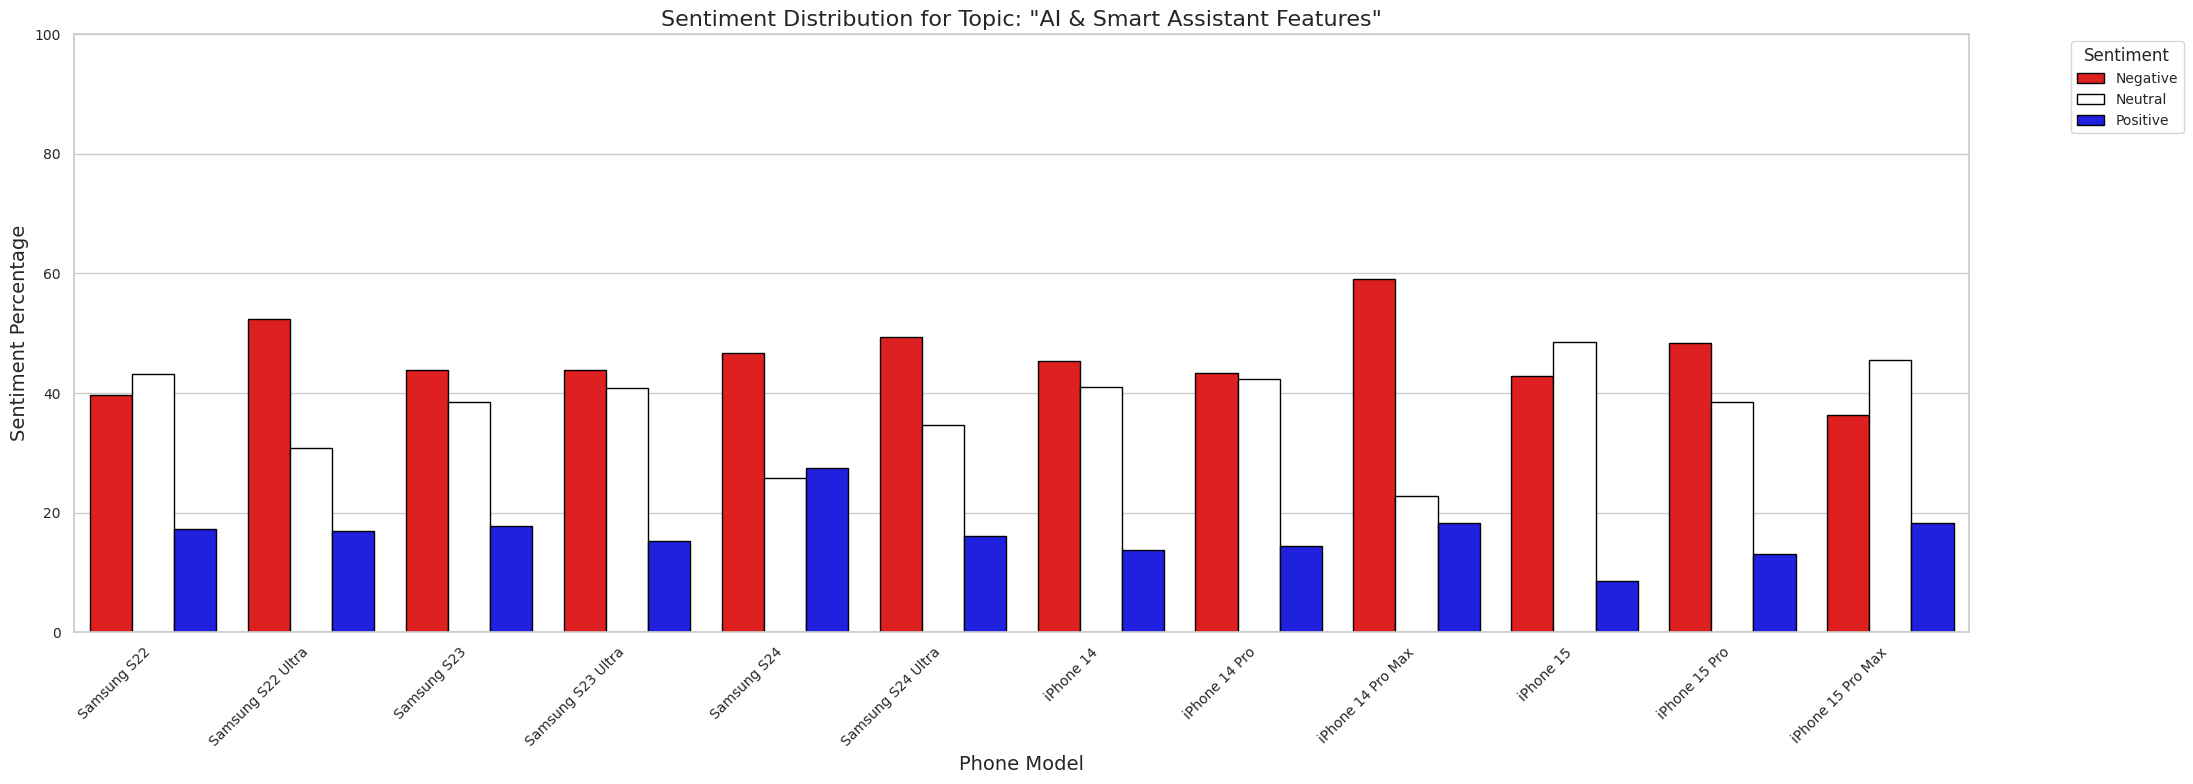

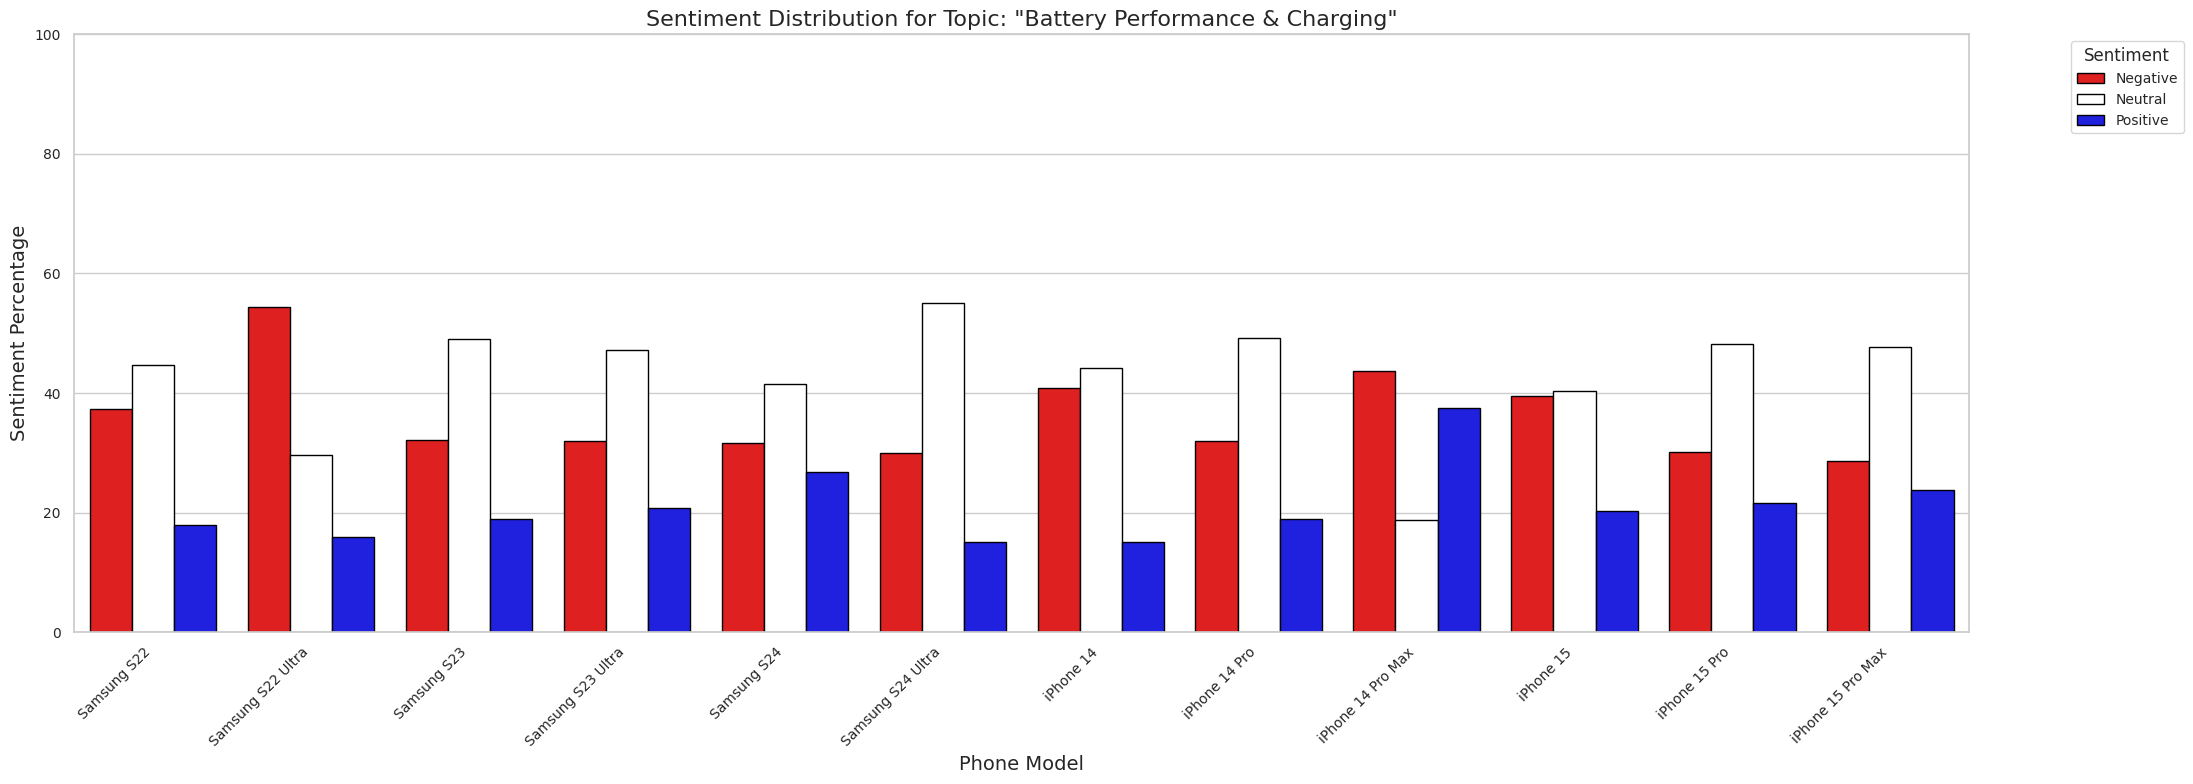

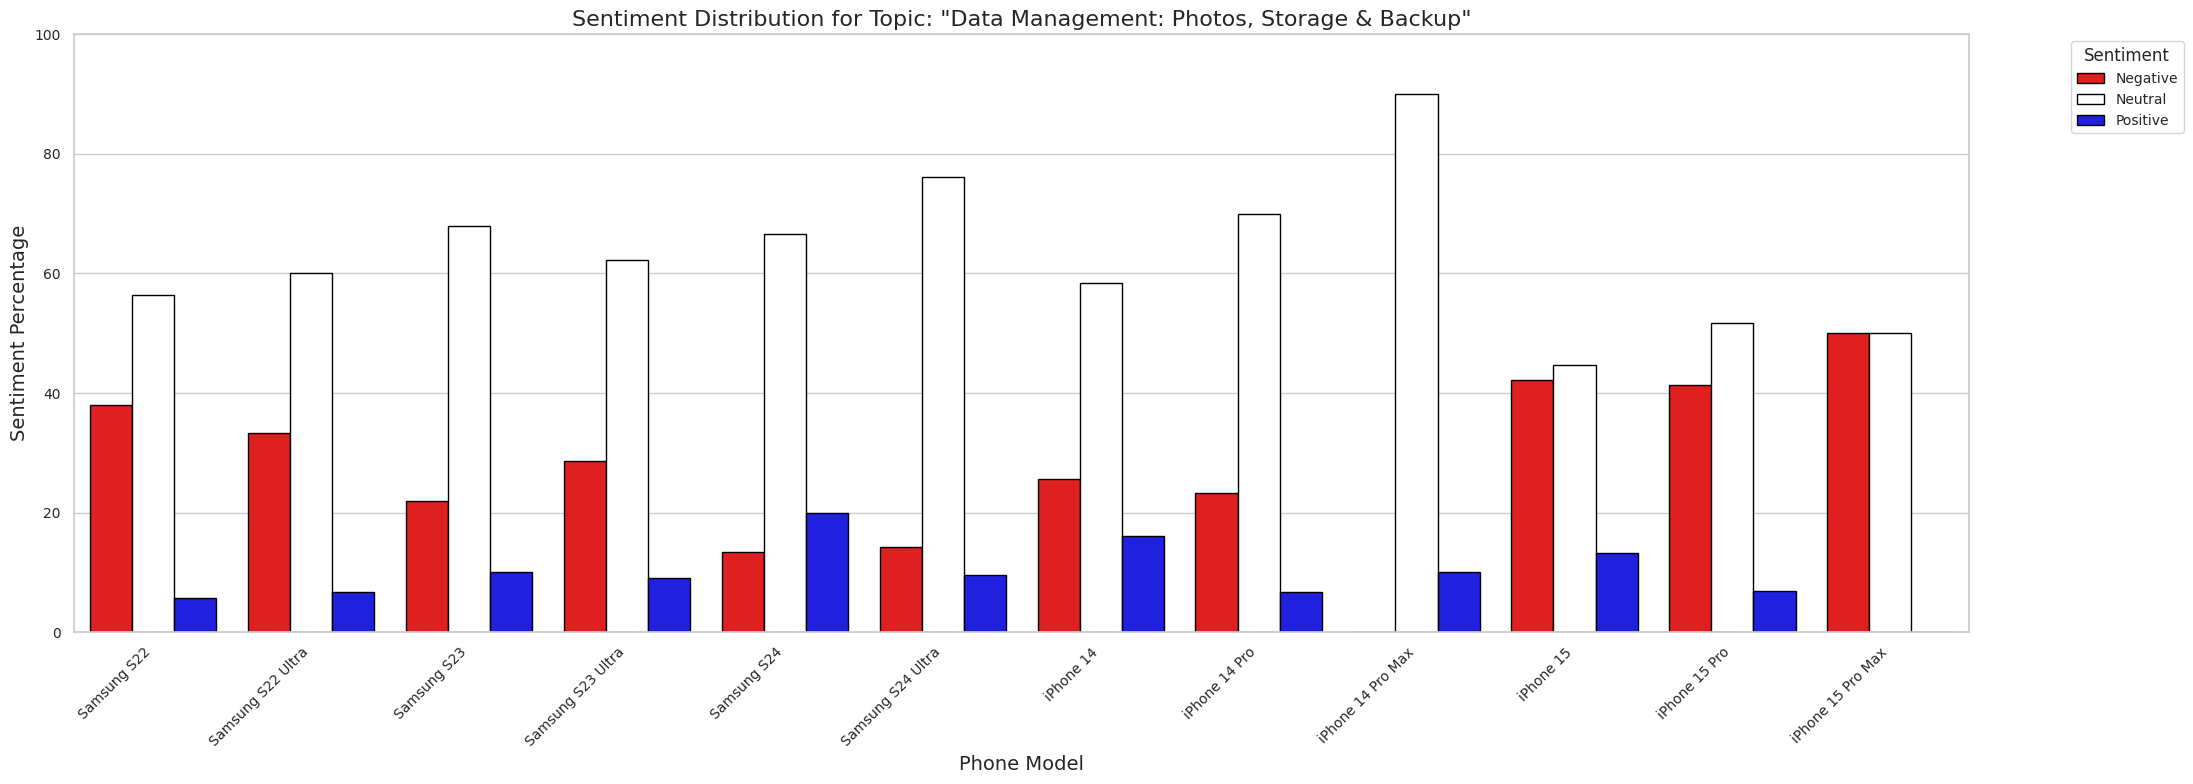

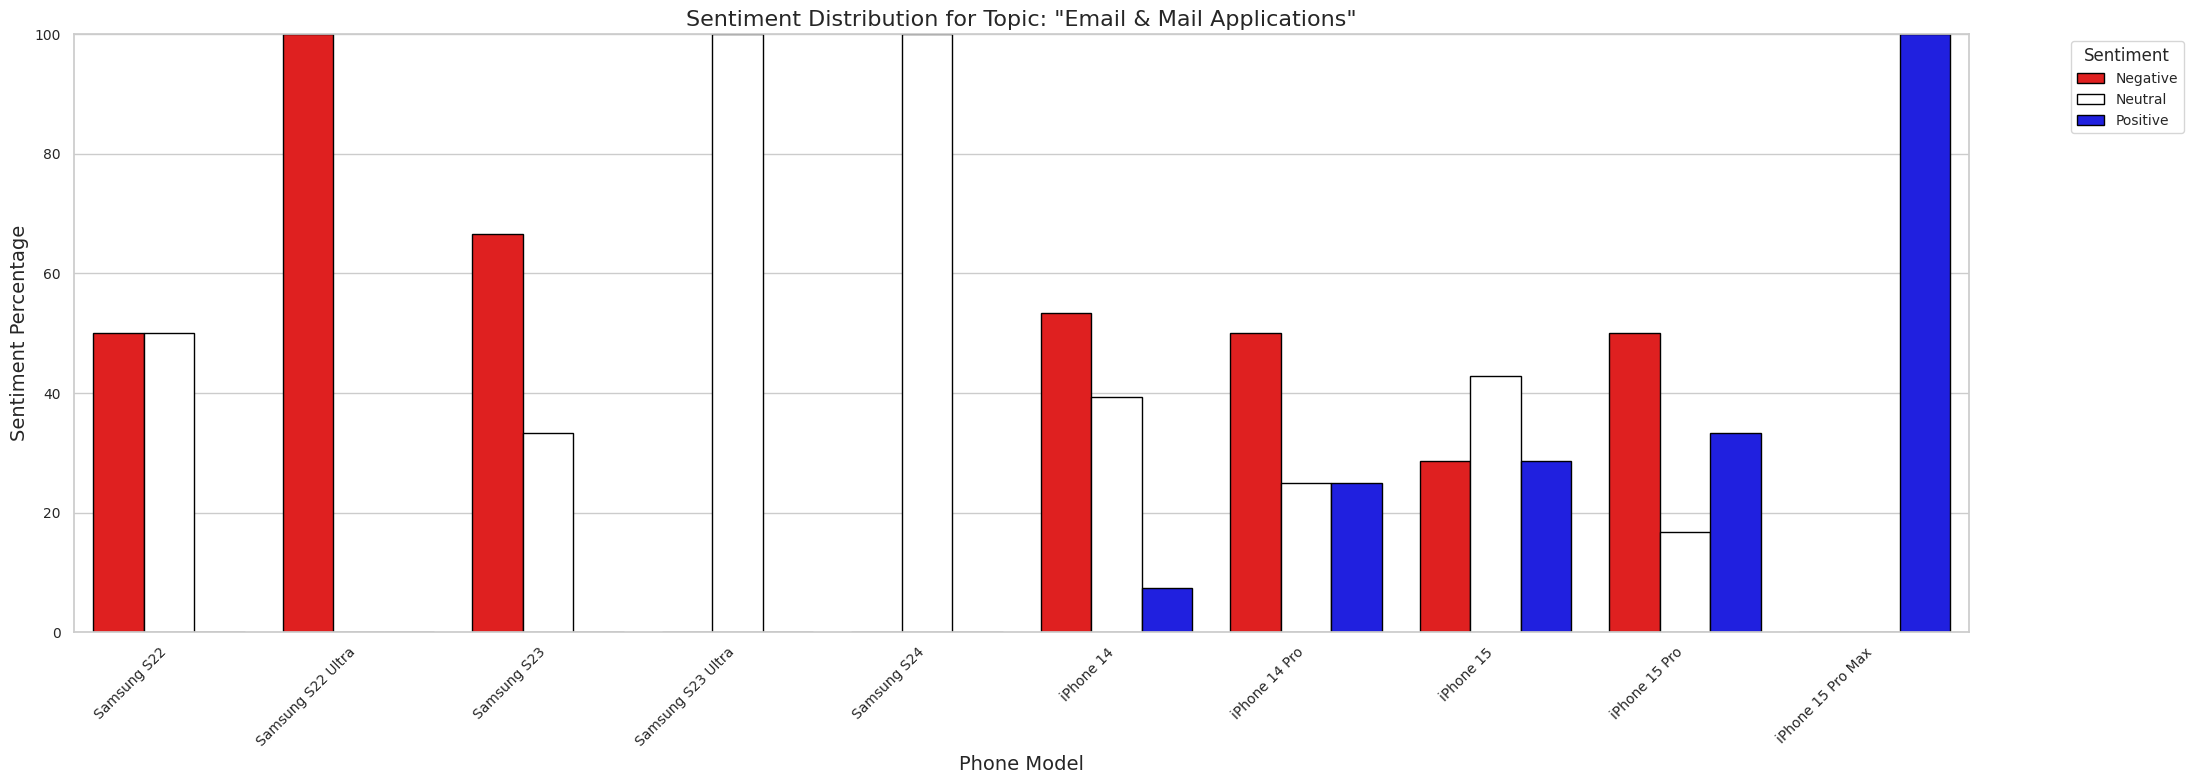

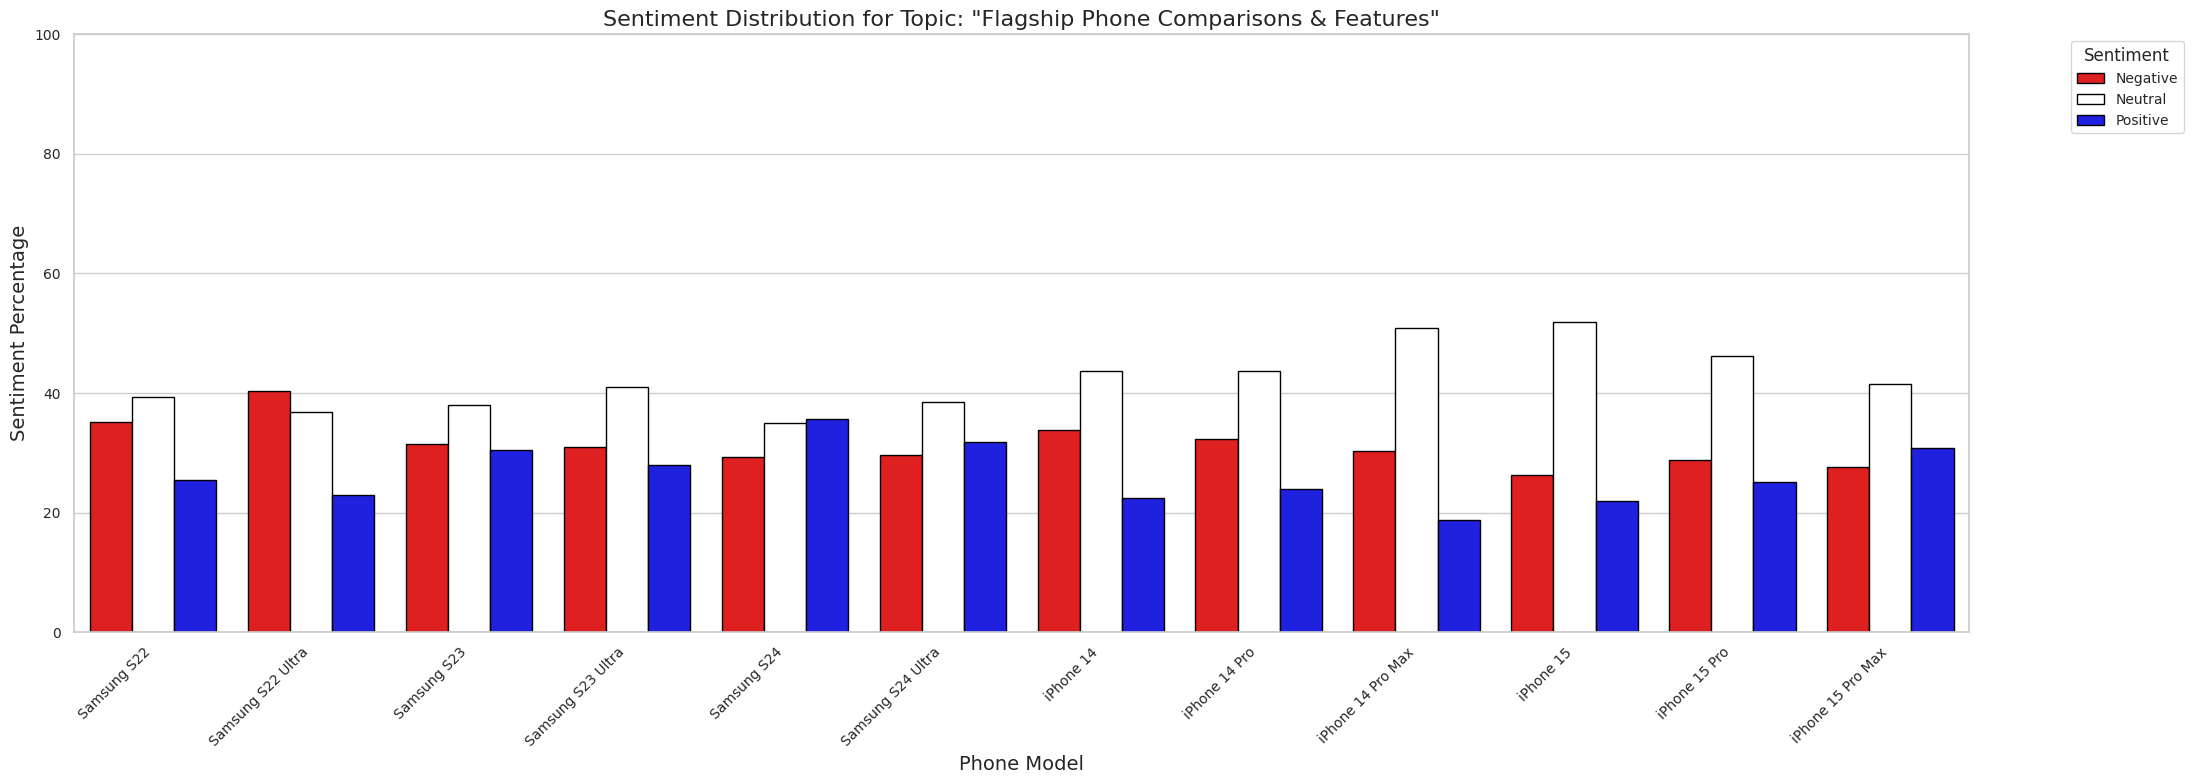

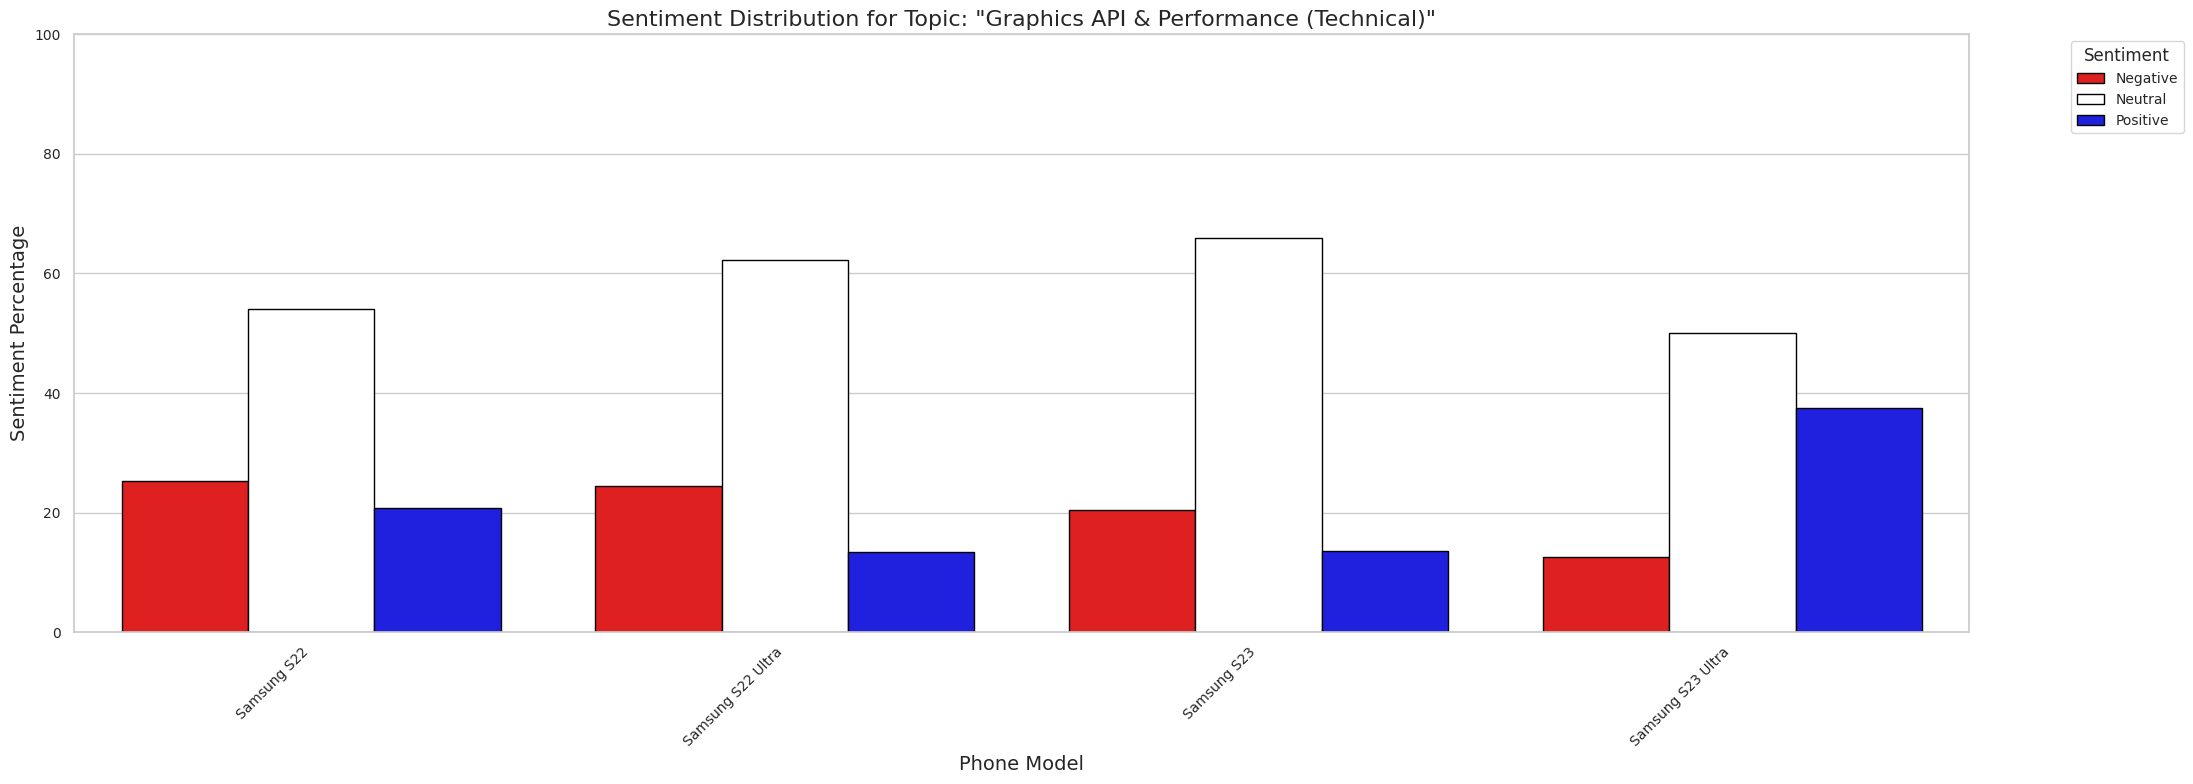

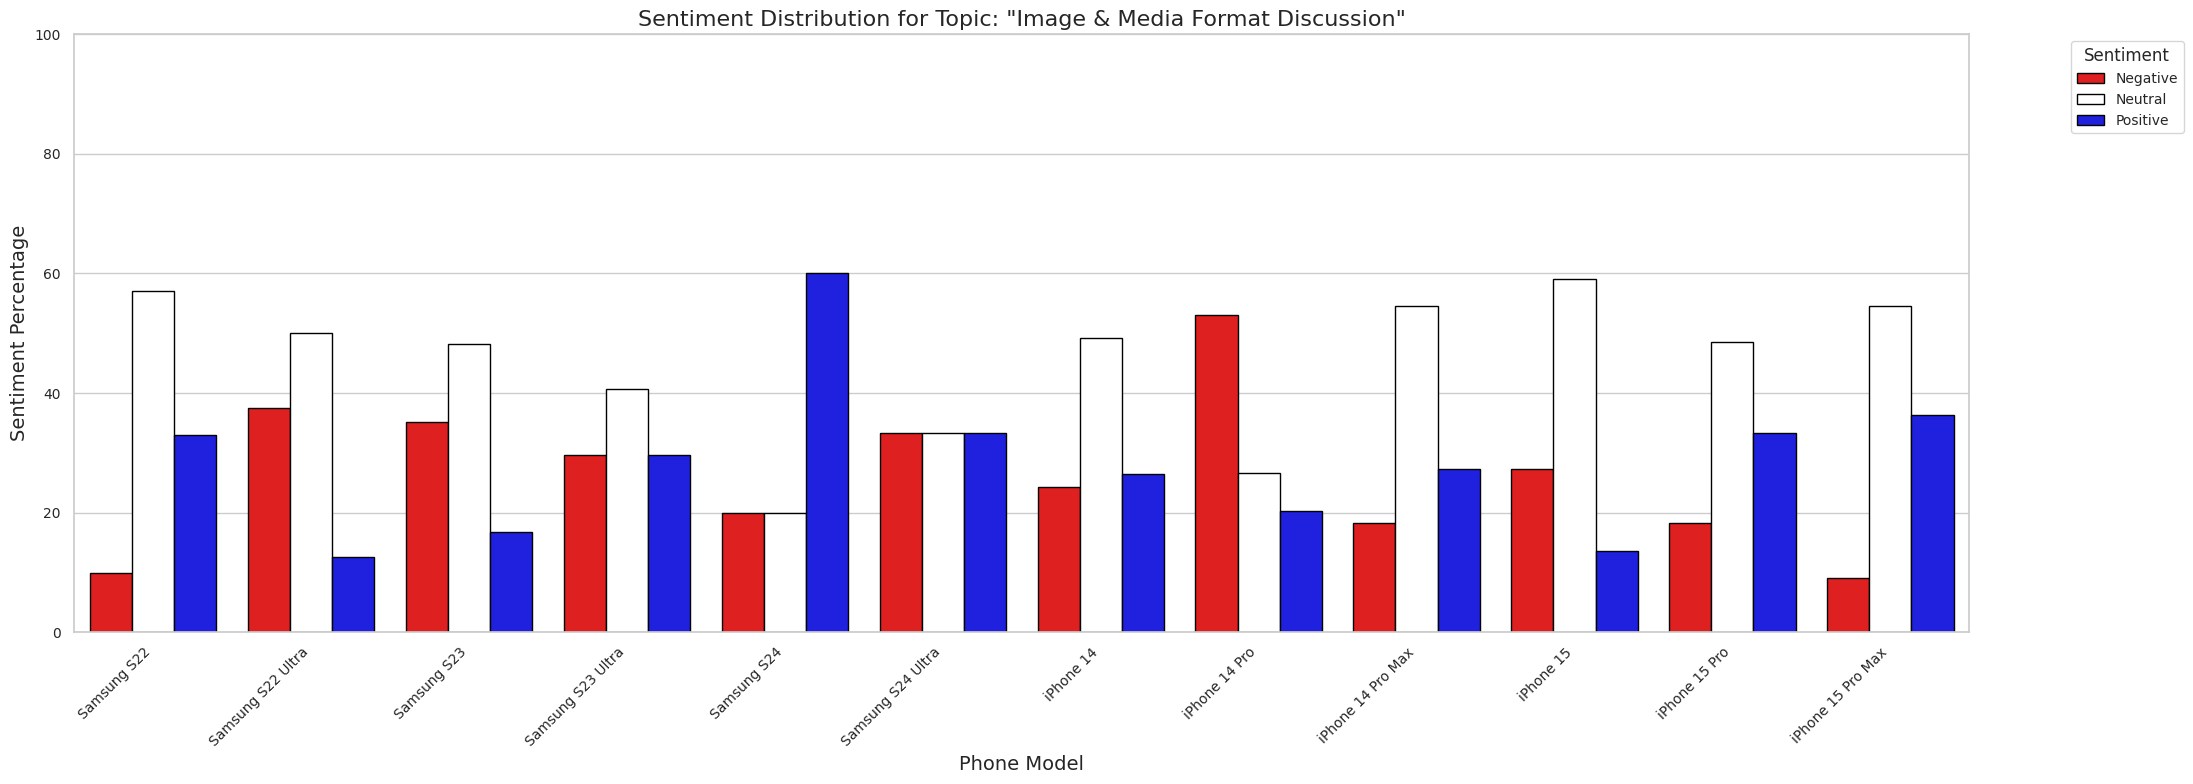

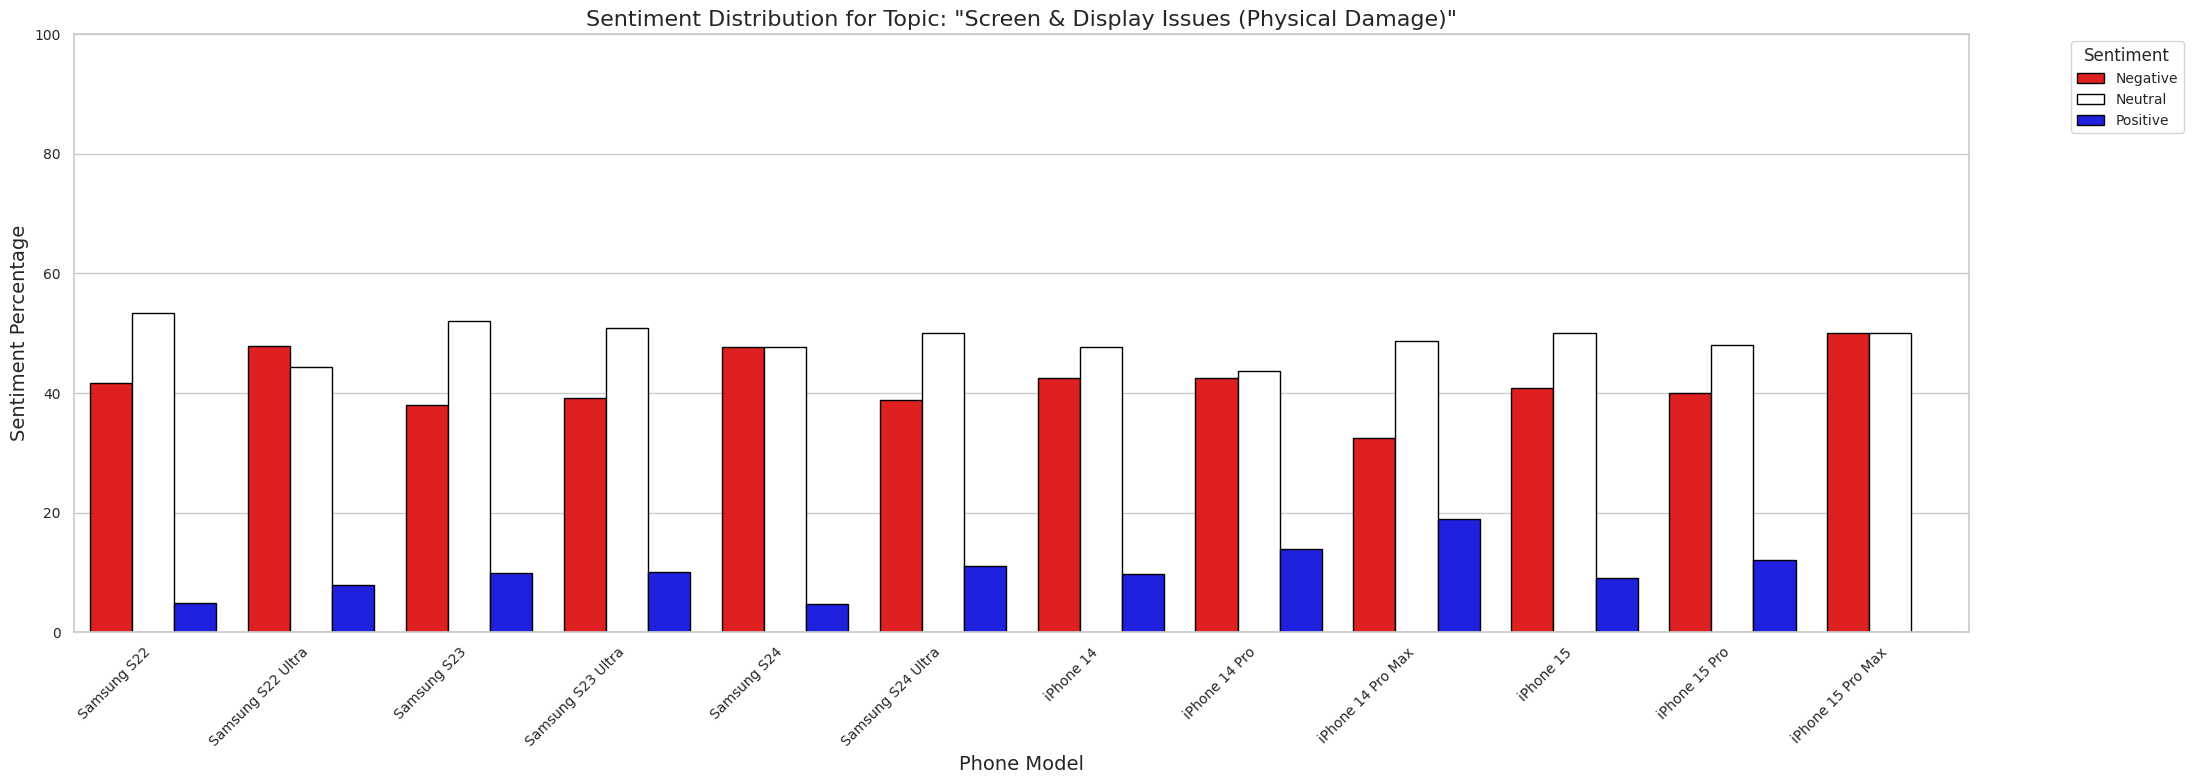

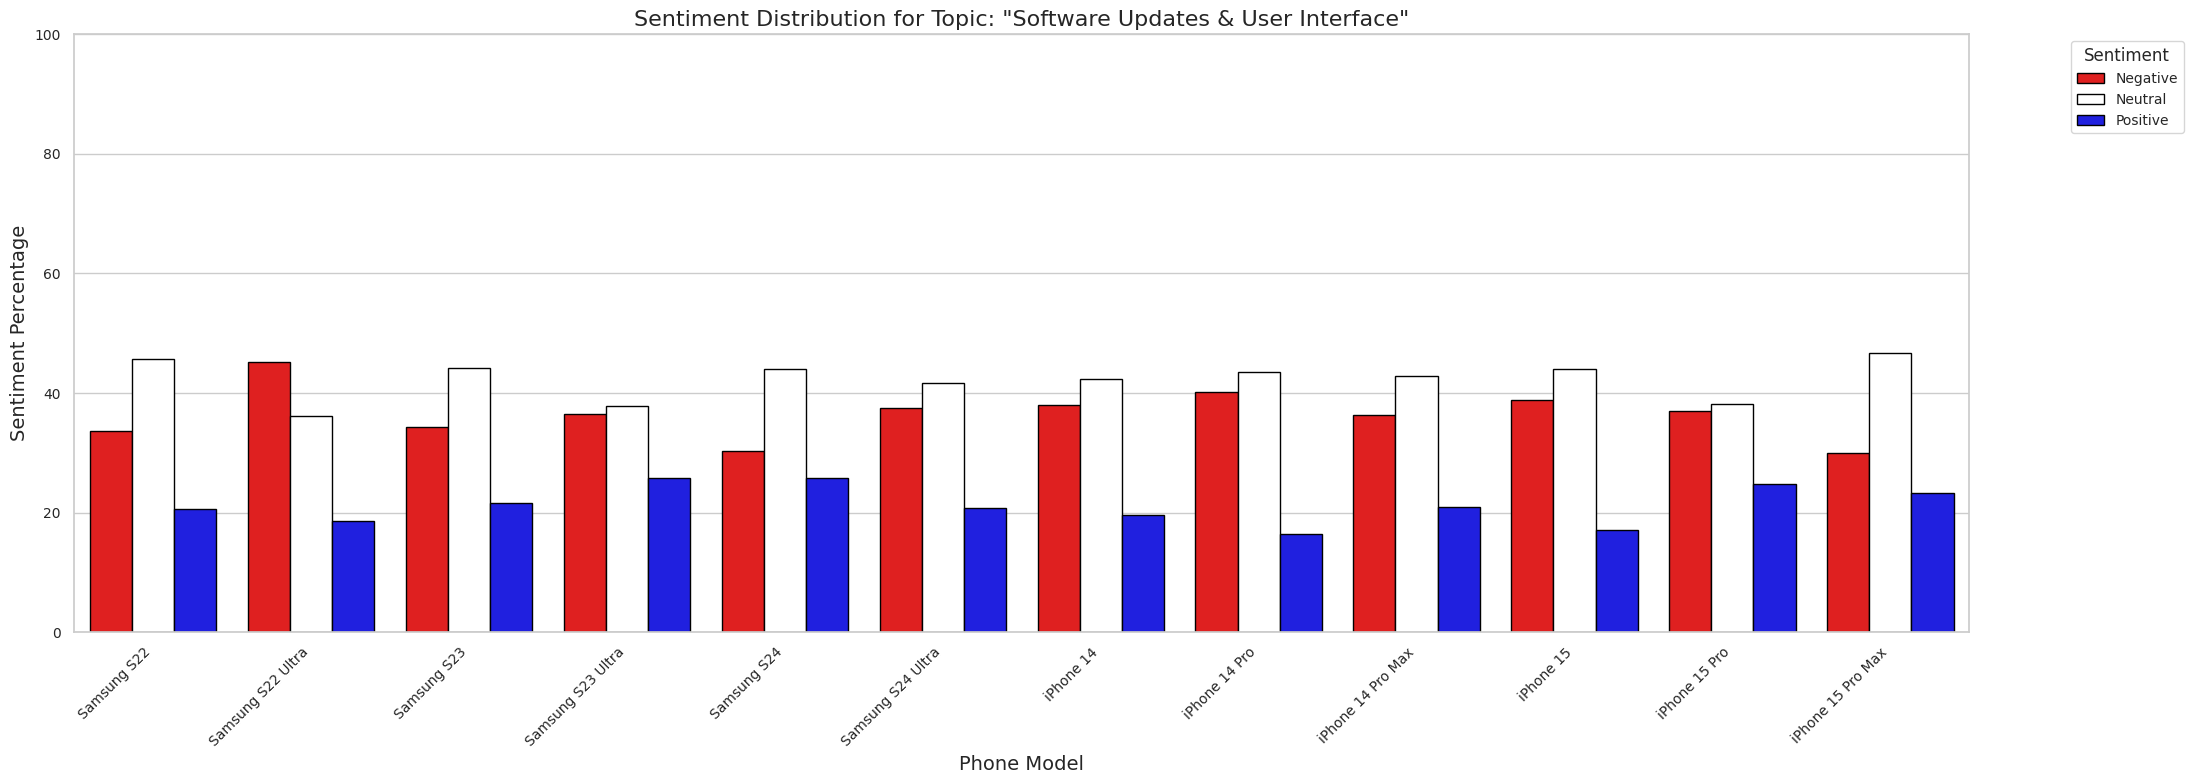

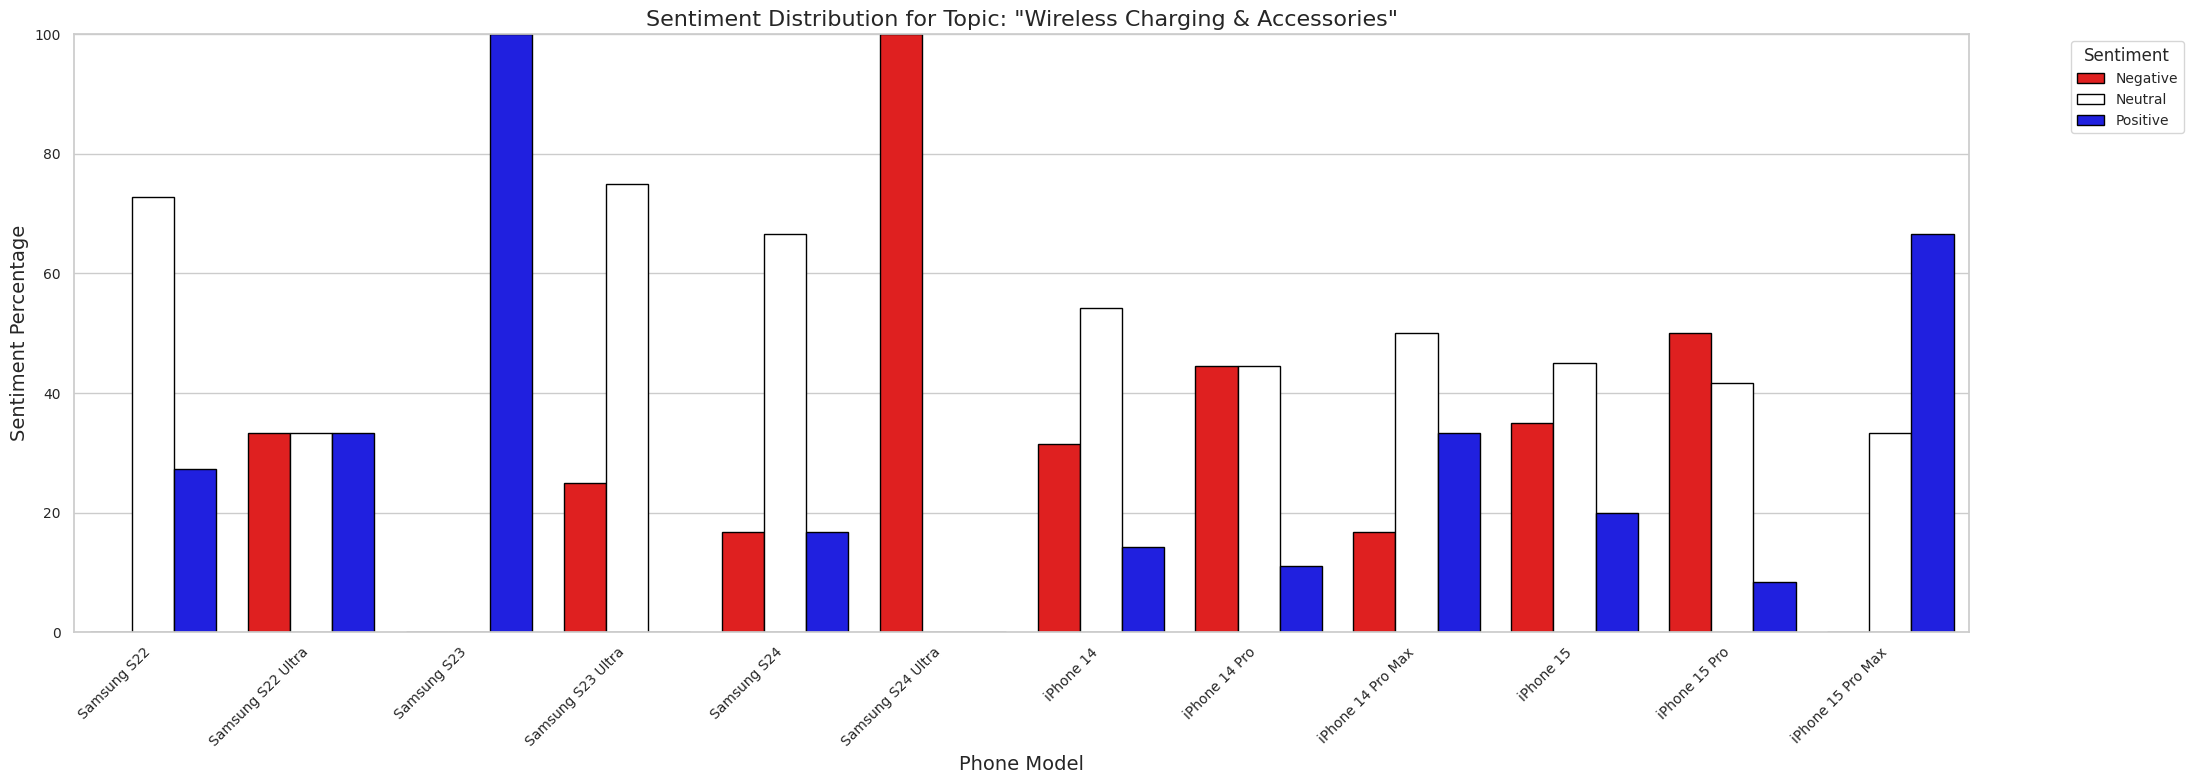


Visualization 2 Completed: Sentiment per Model per Topic (Display Only).
Proceed to the next visualization: Overall Sentiment by Brand (Samsung vs. iPhone).


In [ ]:
# Twenty-sixth code block: Visualization 2 - Sentiment per Model per Topic (FIXED PLOTTING DATA FORMAT)

# 1. Import necessary libraries
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define paths (only for loading input data, no output plot paths)
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
prepared_viz_data_path = os.path.join(project_path, 'sentiment_topic_viz_data.jsonl')

print(f"Loading prepared visualization data from: {prepared_viz_data_path}")

# --- 1. Load Prepared Data ---
try:
    combined_df_filtered_topics = pd.read_json(prepared_viz_data_path, lines=True)
    if combined_df_filtered_topics.empty:
        print("ERROR: Prepared visualization DataFrame is empty after loading. Cannot create plots.")
        exit()
    print(f"Loaded {len(combined_df_filtered_topics)} rows for visualization.")
    print(f"Initial combined_df_filtered_topics shape: {combined_df_filtered_topics.shape}")
except FileNotFoundError:
    print(f"ERROR: Prepared visualization data not found at {prepared_viz_data_path}.")
    print("Please ensure the 'Data Preparation for Visualization' block ran successfully.")
    exit()
except Exception as e:
    print(f"An error occurred loading visualization data: {e}")
    exit()

# --- 2. Filter Data for Topic-Specific Analysis ---
df_topic_analysis = combined_df_filtered_topics[
    (combined_df_filtered_topics['main_predicted_model'] != 'None') &
    (combined_df_filtered_topics['topic_id'] != -1)
].copy()

print(f"df_topic_analysis shape after filtering 'None' models and '-1' topic: {df_topic_analysis.shape}")
if df_topic_analysis.empty:
    print("WARNING: No data available for topic-specific model analysis after filtering. Skipping plots.")
    exit()

# --- 3. Group and Calculate Percentages for Topic-Specific Sentiment ---
sentiment_per_topic_model = df_topic_analysis.groupby(['topic_name', 'main_predicted_model', 'sentiment']).size().unstack(fill_value=0)

group_sums = sentiment_per_topic_model.sum(axis=1)
sentiment_per_topic_model_percentages = sentiment_per_topic_model.divide(group_sums, axis=0) * 100

sentiment_order = ['Negative', 'Neutral', 'Positive']
sentiment_per_topic_model_percentages = sentiment_per_topic_model_percentages.reindex(columns=sentiment_order, fill_value=0)

# Reset index to make topic_name and main_predicted_model regular columns for plotting
df_plot_topic_model = sentiment_per_topic_model_percentages.reset_index()


# --- FIX: Melt the DataFrame for Grouped Bar Plotting ---
print("\nFIX: Melting DataFrame for grouped bar plotting...")
df_plot_topic_model_melted = df_plot_topic_model.melt(
    id_vars=['topic_name', 'main_predicted_model'],
    var_name='Sentiment Category', # New column for 'Negative', 'Neutral', 'Positive'
    value_name='Percentage'        # New column for the percentage values
)
print(f"Melted DataFrame shape: {df_plot_topic_model_melted.shape}")
print("Sample of Melted DataFrame:")
print(df_plot_topic_model_melted.head().to_string())
# --- END FIX ---


# --- 4. Create Grouped Bar Charts for Each Topic ---
print("\nGenerating plots for Sentiment per Model per Topic...")
sns.set_theme(style="whitegrid")
sentiment_palette = {'Negative': 'red', 'Neutral': 'white', 'Positive': 'blue'}
num_models = len(df_plot_topic_model_melted['main_predicted_model'].unique()) # Use melted DF for unique models

for topic_name in sorted(df_plot_topic_model_melted['topic_name'].unique()): # Iterate over unique topic names in melted DF
    df_topic_data = df_plot_topic_model_melted[df_plot_topic_model_melted['topic_name'] == topic_name].copy()

    if df_topic_data.empty:
        print(f"  Skipping empty topic: {topic_name}")
        continue

    plt.figure(figsize=(num_models * 1.5 + 4, 8))

    sns.barplot(
        x='main_predicted_model',
        y='Percentage', # Use the new 'Percentage' column
        hue='Sentiment Category', # Use the new 'Sentiment Category' column
        data=df_topic_data,
        palette=sentiment_palette,
        edgecolor='black',
        hue_order=sentiment_order # Ensure consistent order of sentiment bars
    )

    plt.title(f'Sentiment Distribution for Topic: "{topic_name}"', fontsize=16)
    plt.xlabel('Phone Model', fontsize=14)
    plt.ylabel('Sentiment Percentage', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.ylim(0, 100)
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

print("\nVisualization 2 Completed: Sentiment per Model per Topic (Display Only).")
print("Proceed to the next visualization: Overall Sentiment by Brand (Samsung vs. iPhone).")

Loading prepared visualization data from: /content/drive/MyDrive/RedditBrandAnalysis/sentiment_topic_viz_data.jsonl
Loaded 20796 rows for visualization.
DataFrame shape for brand comparison: (20004, 11)

Sentiment percentages per brand (before melting):
sentiment   Negative    Neutral   Positive
brand                                     
Samsung    35.737579  44.964512  19.297909
iPhone     41.731050  43.401545  14.867404

Melted DataFrame for Brand Sentiment Plot:
     brand Sentiment  Percentage
0  Samsung  Negative   35.737579
1   iPhone  Negative   41.731050
2  Samsung   Neutral   44.964512
3   iPhone   Neutral   43.401545
4  Samsung  Positive   19.297909

Generating plot for Overall Sentiment by Brand (Samsung vs. iPhone)...


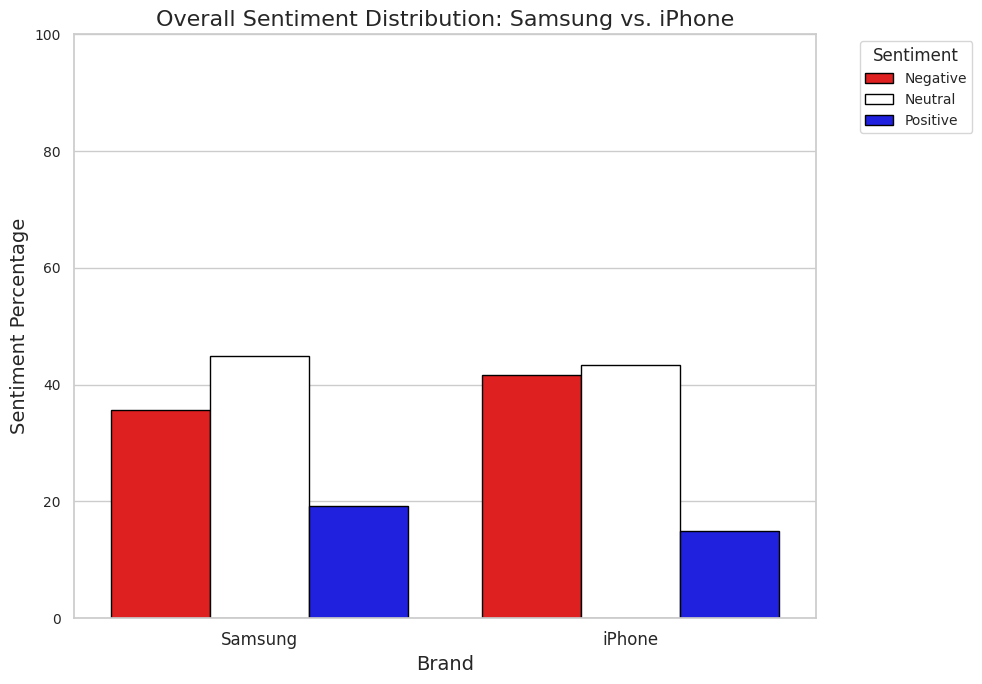


Visualization 3 Completed: Overall Sentiment by Brand (Samsung vs. iPhone - Grouped Bars).

All requested visualizations are complete!


In [ ]:
# Twenty-seventh code block: Visualization 3 - Overall Sentiment by Brand (Samsung vs. iPhone - REVISED GROUPED BARS)

# 1. Import necessary libraries
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define paths (only for loading input data, no output plot paths)
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
prepared_viz_data_path = os.path.join(project_path, 'sentiment_topic_viz_data.jsonl')

print(f"Loading prepared visualization data from: {prepared_viz_data_path}")

# --- 1. Load Prepared Data ---
try:
    combined_df_filtered_topics = pd.read_json(prepared_viz_data_path, lines=True)
    if combined_df_filtered_topics.empty:
        print("ERROR: Prepared visualization DataFrame is empty after loading. Cannot create plot.")
        exit()
    print(f"Loaded {len(combined_df_filtered_topics)} rows for visualization.")
except FileNotFoundError:
    print(f"ERROR: Prepared visualization data not found at {prepared_viz_data_path}.")
    print("Please ensure the 'Data Preparation for Visualization' block ran successfully.")
    exit()
except Exception as e:
    print(f"An error occurred loading visualization data: {e}")
    exit()

# --- 2. Filter for Specific Phone Models and Create 'brand' Column ---
# Filter out rows where no specific model was predicted ('None')
df_specific_models = combined_df_filtered_topics[
    combined_df_filtered_topics['main_predicted_model'] != 'None'
].copy()

if df_specific_models.empty:
    print("WARNING: No data available for specific phone models after filtering 'None'. Skipping plot.")
    print("This indicates that after topic filtering, all remaining predicted models were 'None'.")
    print("Please review your topic exclusion list in the 'Data Preparation for Visualization' block.")
    exit()

# Create a new 'brand' column based on the predicted model name
def get_brand(model_name):
    if model_name.startswith('Samsung'):
        return 'Samsung'
    elif model_name.startswith('iPhone'):
        return 'iPhone'
    return 'Other'

df_specific_models['brand'] = df_specific_models['main_predicted_model'].apply(get_brand)

# Filter out 'Other' brands if any (should only be Samsung/iPhone)
df_specific_brands = df_specific_models[df_specific_models['brand'].isin(['Samsung', 'iPhone'])].copy()

if df_specific_brands.empty:
    print("WARNING: No data available for Samsung or iPhone brands after filtering. Skipping plot.")
    exit()

print(f"DataFrame shape for brand comparison: {df_specific_brands.shape}")

# --- 3. Group by Brand and Sentiment, Calculate Percentages ---
brand_sentiment_counts = df_specific_brands.groupby(['brand', 'sentiment']).size().unstack(fill_value=0)

# Calculate percentages per brand
brand_sentiment_percentages = brand_sentiment_counts.apply(lambda x: x / x.sum() * 100, axis=1)

# Ensure all three sentiment categories are present and ordered
sentiment_order = ['Negative', 'Neutral', 'Positive']
brand_sentiment_percentages = brand_sentiment_percentages.reindex(columns=sentiment_order, fill_value=0)

# Sort brands alphabetically for plot consistency
brand_sentiment_percentages = brand_sentiment_percentages.sort_index()

print("\nSentiment percentages per brand (before melting):")
print(brand_sentiment_percentages)

# --- 4. Melt the DataFrame for Grouped Bar Plotting ---
df_plot_brand = brand_sentiment_percentages.reset_index().melt(
    id_vars='brand',
    var_name='Sentiment', # New column for 'Negative', 'Neutral', 'Positive'
    value_name='Percentage' # New column for the percentage values
)

print("\nMelted DataFrame for Brand Sentiment Plot:")
print(df_plot_brand.head().to_string())

# --- 5. Create the Grouped Bar Chart ---
print("\nGenerating plot for Overall Sentiment by Brand (Samsung vs. iPhone)...")
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Use a custom palette to map sentiments to colors consistently
sentiment_palette = {'Negative': 'red', 'Neutral': 'white', 'Positive': 'blue'}

sns.barplot(
    x='brand',
    y='Percentage',
    hue='Sentiment', # Group by Sentiment
    data=df_plot_brand,
    palette=sentiment_palette,
    edgecolor='black',
    hue_order=sentiment_order # Ensure consistent order of sentiment bars
)

plt.title('Overall Sentiment Distribution: Samsung vs. iPhone', fontsize=16)
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Sentiment Percentage', fontsize=14)
plt.xticks(rotation=0, fontsize=12) # No rotation needed for just two brands
plt.yticks(fontsize=10)
plt.ylim(0, 100) # Ensure y-axis goes to 100%
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print("\nVisualization 3 Completed: Overall Sentiment by Brand (Samsung vs. iPhone - Grouped Bars).")
print("\nAll requested visualizations are complete!")

Loading prepared visualization data from: /content/drive/MyDrive/RedditBrandAnalysis/sentiment_topic_viz_data.jsonl
Data loaded successfully from JSONL format.
DataFrame shape for model comparison: (39160, 10)

Sentiment percentages per model (for plotting):
  main_predicted_model sentiment_label  count  total_count  percentage
0          Samsung S22        negative   2375         6823   34.808735
1          Samsung S22         neutral   3014         6823   44.174117
2          Samsung S22        positive   1434         6823   21.017148
3    Samsung S22 Ultra        negative   1151         2655   43.352166
4    Samsung S22 Ultra         neutral    987         2655   37.175141

Generating plot for Overall Sentiment by Phone Model (Grouped Bars)...


<Figure size 1200x700 with 0 Axes>

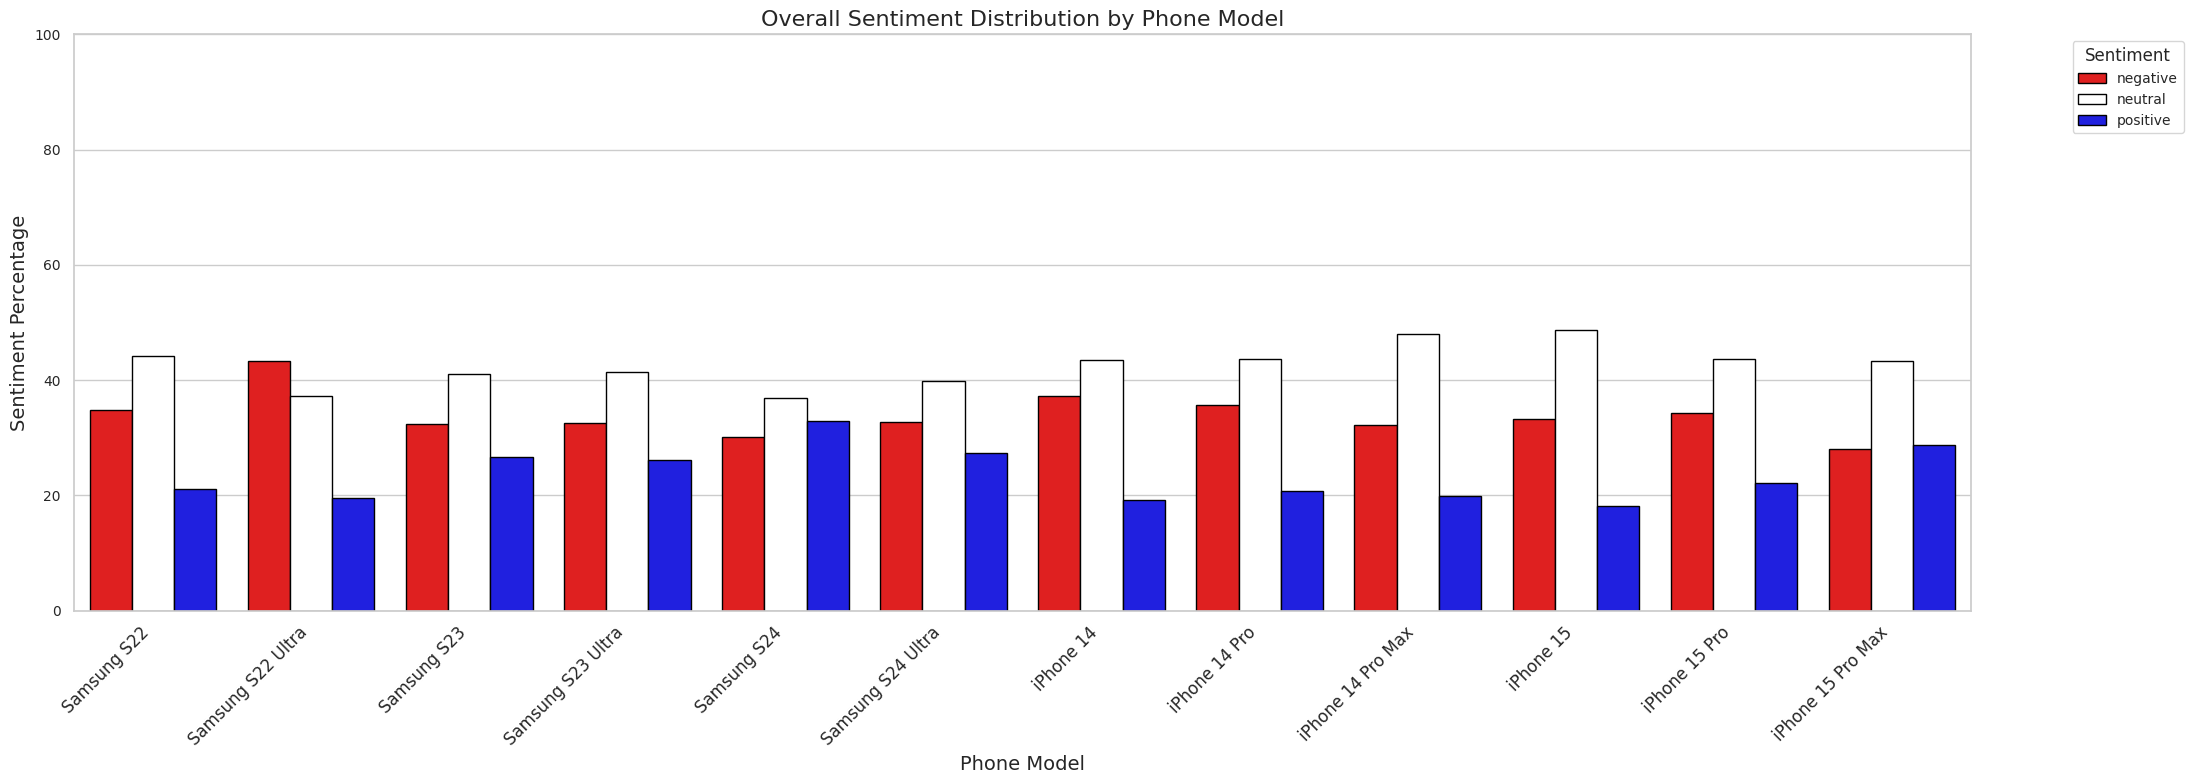


Visualization Completed: Overall Sentiment by Phone Model (Grouped Bars).


In [ ]:
# Install necessary libraries if you haven't already
# !pip install pandas matplotlib seaborn

import pandas as pd
import json
import io
import os # Import the os module for path manipulation
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns # Import seaborn

# --- Data Loading ---
# Define paths for input data
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
# Use os.path.join to correctly construct the file path
file_path = os.path.join(project_path, 'sentiment_topic_viz_data.jsonl')

print(f"Loading prepared visualization data from: {file_path}")

# Load the dataset. The previous error indicated it might be newline-delimited JSON (JSONL).
# We read it line by line and parse each JSON object.
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f]
    df = pd.DataFrame(data)
    print("Data loaded successfully from JSONL format.")
except json.JSONDecodeError:
    # If it's a single JSON array, try loading it directly
    # Note: If your file is consistently .jsonl, this block might not be needed.
    # However, it's kept for robustness in case of mixed formats.
    df = pd.read_json(file_path)
    print("Data loaded successfully from standard JSON format.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded or the path is correct.")
    exit() # Exit if the file isn't found

# --- Data Processing for Model Comparison ---
# Filter out rows where no specific model was predicted ('None')
# We will now use df_specific_models directly for visualization,
# as we want to see sentiment for each individual model.
df_specific_models = df[df['main_predicted_model'] != 'None'].copy()

if df_specific_models.empty:
    print("WARNING: No data available for specific phone models after filtering 'None'. Skipping plot.")
    print("This indicates that after topic filtering, all remaining predicted models were 'None'.")
    print("Please review your topic exclusion list in the 'Data Preparation for Visualization' block if applicable.")
    exit()

print(f"DataFrame shape for model comparison: {df_specific_models.shape}")

# Group by 'main_predicted_model' and 'sentiment_label' and count occurrences
model_sentiment_counts = df_specific_models.groupby(['main_predicted_model', 'sentiment_label']).size().reset_index(name='count')

# Calculate the total count for each model to determine percentages
total_model_counts = model_sentiment_counts.groupby('main_predicted_model')['count'].sum().reset_index(name='total_count')

# Merge to get total counts per model
model_sentiment_percentages = pd.merge(model_sentiment_counts, total_model_counts, on='main_predicted_model')

# Calculate the percentage
model_sentiment_percentages['percentage'] = (model_sentiment_percentages['count'] / model_sentiment_percentages['total_count']) * 100

# Define the order for sentiments for consistent plotting (e.g., Negative, Neutral, Positive)
sentiment_order = ['negative', 'neutral', 'positive']

# Convert 'sentiment_label' to a categorical type with the specified order
model_sentiment_percentages['sentiment_label'] = pd.Categorical(
    model_sentiment_percentages['sentiment_label'],
    categories=sentiment_order,
    ordered=True
)

# Sort the DataFrame by model and then by sentiment_label to ensure correct plotting order
# For X-axis order, we can get the unique models and sort them alphabetically
unique_models = sorted(model_sentiment_percentages['main_predicted_model'].unique())
model_sentiment_percentages['main_predicted_model'] = pd.Categorical(
    model_sentiment_percentages['main_predicted_model'],
    categories=unique_models,
    ordered=True
)

model_sentiment_percentages = model_sentiment_percentages.sort_values(by=['main_predicted_model', 'sentiment_label'])

print("\nSentiment percentages per model (for plotting):")
print(model_sentiment_percentages.head().to_string())


# --- Visualization Creation (Matplotlib & Seaborn - Grouped Vertical Bar Chart per Model) ---
print("\nGenerating plot for Overall Sentiment by Phone Model (Grouped Bars)...")
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability with more models
sns.set_theme(style="whitegrid") # Use a clean theme

# Use a custom palette to map sentiments to colors consistently
# Matching the colors previously used: Red for negative,white for neutral, Blue for positive
sentiment_palette = {'negative': 'red', 'neutral': 'white', 'positive': 'blue'}
plt.figure(figsize=(12* 1.5 + 4, 8))

sns.barplot(
    x='main_predicted_model',
    y='percentage',
    hue='sentiment_label', # Group by Sentiment
    data=model_sentiment_percentages,
    palette=sentiment_palette,
    edgecolor='black', # Add black edges to bars for better definition
    hue_order=sentiment_order # Ensure consistent order of sentiment bars
)

plt.title('Overall Sentiment Distribution by Phone Model', fontsize=16)
plt.xlabel('Phone Model', fontsize=14)
plt.ylabel('Sentiment Percentage', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12) # Rotate labels for better readability if many models
plt.yticks(fontsize=10)
plt.ylim(0, 100) # Ensure y-axis goes to 100%
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10) # Place legend outside
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

print("\nVisualization Completed: Overall Sentiment by Phone Model (Grouped Bars).")


Loading prepared visualization data from: /content/drive/MyDrive/RedditBrandAnalysis/sentiment_topic_viz_data.jsonl
Data loaded successfully from JSONL format.
DataFrame shape for model comparison: (39160, 10)

Sentiment percentages per model (for plotting):
  main_predicted_model sentiment_label  count  total_count  percentage
0          Samsung S22        negative   2375         6823   34.808735
1          Samsung S22         neutral   3014         6823   44.174117
2          Samsung S22        positive   1434         6823   21.017148
3    Samsung S22 Ultra        negative   1151         2655   43.352166
4    Samsung S22 Ultra         neutral    987         2655   37.175141

Generating plots for Positive Sentiment Trend Over Time by Brand...


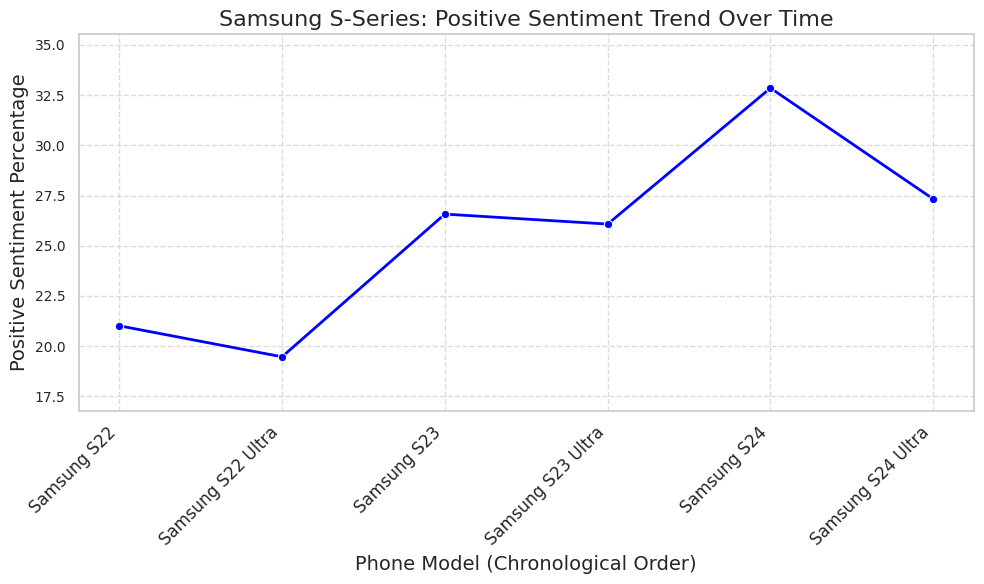


Samsung Positive Sentiment Trend Plot Completed.


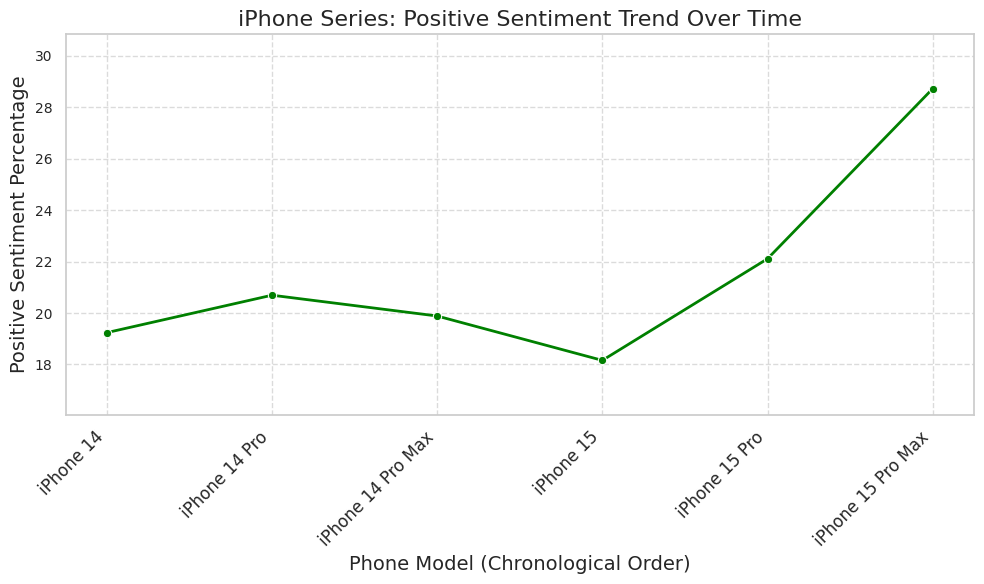


iPhone Positive Sentiment Trend Plot Completed.

All requested visualizations are complete!


In [ ]:
# Install necessary libraries if you haven't already
# !pip install pandas matplotlib seaborn

import pandas as pd
import json
import io
import os # Import the os module for path manipulation
import matplotlib.pyplot as plt # Import matplotlib
import seaborn as sns # Import seaborn

# --- Data Loading ---
# Define paths for input data
project_path = '/content/drive/MyDrive/RedditBrandAnalysis'
# Use os.path.join to correctly construct the file path
file_path = os.path.join(project_path, 'sentiment_topic_viz_data.jsonl')

print(f"Loading prepared visualization data from: {file_path}")

# Load the dataset. The previous error indicated it might be newline-delimited JSON (JSONL).
# We read it line by line and parse each JSON object.
try:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = [json.loads(line) for line in f]
    df = pd.DataFrame(data)
    print("Data loaded successfully from JSONL format.")
except json.JSONDecodeError:
    # If it's a single JSON array, try loading it directly
    # Note: If your file is consistently .jsonl, this block might not be needed.
    # However, it's kept for robustness in case of mixed formats.
    df = pd.read_json(file_path)
    print("Data loaded successfully from standard JSON format.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded or the path is correct.")
    exit() # Exit if the file isn't found

# --- Data Processing for Model Comparison ---
# Filter out rows where no specific model was predicted ('None')
df_specific_models = df[df['main_predicted_model'] != 'None'].copy()

if df_specific_models.empty:
    print("WARNING: No data available for specific phone models after filtering 'None'. Skipping plot.")
    print("This indicates that after topic filtering, all remaining predicted models were 'None'.")
    print("Please review your topic exclusion list in the 'Data Preparation for Visualization' block if applicable.")
    exit()

print(f"DataFrame shape for model comparison: {df_specific_models.shape}")

# Group by 'main_predicted_model' and 'sentiment_label' and count occurrences
model_sentiment_counts = df_specific_models.groupby(['main_predicted_model', 'sentiment_label']).size().reset_index(name='count')

# Calculate the total count for each model to determine percentages
total_model_counts = model_sentiment_counts.groupby('main_predicted_model')['count'].sum().reset_index(name='total_count')

# Merge to get total counts per model
model_sentiment_percentages = pd.merge(model_sentiment_counts, total_model_counts, on='main_predicted_model')

# Calculate the percentage
model_sentiment_percentages['percentage'] = (model_sentiment_percentages['count'] / model_sentiment_percentages['total_count']) * 100

# Define the order for sentiments for consistent plotting (e.g., Negative, Neutral, Positive)
sentiment_order = ['negative', 'neutral', 'positive']

# Convert 'sentiment_label' to a categorical type with the specified order
model_sentiment_percentages['sentiment_label'] = pd.Categorical(
    model_sentiment_percentages['sentiment_label'],
    categories=sentiment_order,
    ordered=True
)

# Sort the DataFrame by model and then by sentiment_label to ensure correct plotting order
# For X-axis order, we can get the unique models and sort them alphabetically
unique_models = sorted(model_sentiment_percentages['main_predicted_model'].unique())
model_sentiment_percentages['main_predicted_model'] = pd.Categorical(
    model_sentiment_percentages['main_predicted_model'],
    categories=unique_models,
    ordered=True
)

model_sentiment_percentages = model_sentiment_percentages.sort_values(by=['main_predicted_model', 'sentiment_label'])

print("\nSentiment percentages per model (for plotting):")
print(model_sentiment_percentages.head().to_string())


# --- Visualization of Positive Sentiment Trend Over Time by Brand ---
print("\nGenerating plots for Positive Sentiment Trend Over Time by Brand...")

# Filter for positive sentiment only
positive_sentiment_df = model_sentiment_percentages[
    model_sentiment_percentages['sentiment_label'] == 'positive'
].copy()

# Define chronological order for models within each brand
# This is crucial for the 'time' aspect of the trend
samsung_model_order = [
    'Samsung S22', 'Samsung S22 Ultra', 'Samsung S23', 'Samsung S23 Ultra', 'Samsung S24', 'Samsung S24 Ultra'
]
iphone_model_order = [
    'iPhone 14', 'iPhone 14 Pro', 'iPhone 14 Pro Max', 'iPhone 15', 'iPhone 15 Pro', 'iPhone 15 Pro Max'
]

# Function to assign a brand and order value for sorting
def get_brand_and_order(model_name, brand_order_list):
    for i, ordered_model in enumerate(brand_order_list):
        if model_name == ordered_model:
            return i # Return the index as the order
    return -1 # For models not in the specific order list (shouldn't happen if filtered correctly)

# Filter and prepare data for Samsung
samsung_positive_sentiment = positive_sentiment_df[
    positive_sentiment_df['main_predicted_model'].str.startswith('Samsung')
].copy()
samsung_positive_sentiment['model_order'] = samsung_positive_sentiment['main_predicted_model'].apply(
    lambda x: get_brand_and_order(x, samsung_model_order)
)
samsung_positive_sentiment = samsung_positive_sentiment[samsung_positive_sentiment['model_order'] != -1] # Filter out any unlisted models
samsung_positive_sentiment = samsung_positive_sentiment.sort_values(by='model_order')

# Filter and prepare data for iPhone
iphone_positive_sentiment = positive_sentiment_df[
    positive_sentiment_df['main_predicted_model'].str.startswith('iPhone')
].copy()
iphone_positive_sentiment['model_order'] = iphone_positive_sentiment['main_predicted_model'].apply(
    lambda x: get_brand_and_order(x, iphone_model_order)
)
iphone_positive_sentiment = iphone_positive_sentiment[iphone_positive_sentiment['model_order'] != -1] # Filter out any unlisted models
iphone_positive_sentiment = iphone_positive_sentiment.sort_values(by='model_order')

# --- Plot 1: Samsung Positive Sentiment Trend ---
if not samsung_positive_sentiment.empty:
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.lineplot(
        x='main_predicted_model',
        y='percentage',
        data=samsung_positive_sentiment,
        marker='o', # Add markers for each data point
        color='blue', # Consistent color for positive sentiment
        linewidth=2
    )
    plt.title('Samsung S-Series: Positive Sentiment Trend Over Time', fontsize=16)
    plt.xlabel('Phone Model (Chronological Order)', fontsize=14)
    plt.ylabel('Positive Sentiment Percentage', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=10)
    # Dynamically set y-axis limits with padding for better visibility of changes
    min_pct_samsung = samsung_positive_sentiment['percentage'].min()
    max_pct_samsung = samsung_positive_sentiment['percentage'].max()
    padding = (max_pct_samsung - min_pct_samsung) * 0.2 if (max_pct_samsung - min_pct_samsung) > 0 else 5 # Add 20% padding, or 5 if no range
    plt.ylim(max(0, min_pct_samsung - padding), min(100, max_pct_samsung + padding))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("\nSamsung Positive Sentiment Trend Plot Completed.")
else:
    print("\nWARNING: No Samsung data available for positive sentiment trend plot.")

# --- Plot 2: iPhone Positive Sentiment Trend ---
if not iphone_positive_sentiment.empty:
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    sns.lineplot(
        x='main_predicted_model',
        y='percentage',
        data=iphone_positive_sentiment,
        marker='o', # Add markers for each data point
        color='green', # Another distinct color for iPhone
        linewidth=2
    )
    plt.title('iPhone Series: Positive Sentiment Trend Over Time', fontsize=16)
    plt.xlabel('Phone Model (Chronological Order)', fontsize=14)
    plt.ylabel('Positive Sentiment Percentage', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=10)
    # Dynamically set y-axis limits with padding for better visibility of changes
    min_pct_iphone = iphone_positive_sentiment['percentage'].min()
    max_pct_iphone = iphone_positive_sentiment['percentage'].max()
    padding = (max_pct_iphone - min_pct_iphone) * 0.2 if (max_pct_iphone - min_pct_iphone) > 0 else 5 # Add 20% padding, or 5 if no range
    plt.ylim(max(0, min_pct_iphone - padding), min(100, max_pct_iphone + padding))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("\niPhone Positive Sentiment Trend Plot Completed.")
else:
    print("\nWARNING: No iPhone data available for positive sentiment trend plot.")

print("\nAll requested visualizations are complete!")
